<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/perception-aware-dynamic-diffusion-transformers/blob/main/PA_D2IT_PROJECT_WITH_DEMO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# CELL 1 — Bootstrap + Drive cache rehydration audit
# PA-D²iT v2   ·   run this first in EVERY new session
# ------------------------------------------------------------
# Goal: get a fresh runtime back to a usable state without
# re-downloading Cityscapes. Writes nothing destructive: new
# outputs go to {ROOT}/v2/, the old run stays as-is.
# ============================================================
import os, sys, glob, random, shutil, subprocess
import importlib.metadata as im

def sh(cmd, quiet=True):
    print(f"$ {cmd}")
    subprocess.run(cmd, shell=True, check=False,
                   stdout=subprocess.DEVNULL if quiet else None,
                   stderr=subprocess.STDOUT if quiet else None)

# --- 0. allocator flags must be set BEFORE torch initialises CUDA ----------
# expandable_segments cures most of the fragmentation OOMs you hit at bs=192
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import torch

# TF32 on for the fp32 code paths (FID covariance, VAE decode, sqrtm).
# The DiT repo explicitly flags this as a silent perf cliff on A100+.
for setter in (
    lambda: setattr(torch.backends.cuda.matmul, "allow_tf32", True),
    lambda: setattr(torch.backends.cudnn, "allow_tf32", True),
):
    try: setter()
    except Exception as e: print(f"  (tf32 flag skipped: {e})")
torch.backends.cudnn.benchmark = True      # token count is constant ⇒ safe

# --- 1. GPU identity → precision + batch decisions ------------------------
L = "─" * 66
print(L); print("  RUNTIME"); print(L)
print(f"  PyTorch   {torch.__version__}")
print(f"  CUDA      {torch.version.cuda}")
if torch.cuda.is_available():
    d = torch.cuda.get_device_properties(0)
    BF16_OK = d.major >= 8
    print(f"  GPU       {d.name}")
    print(f"  VRAM      {d.total_memory / 1024**3:.1f} GB")
    print(f"  Compute   sm_{d.major}{d.minor}")
    print(f"  SMs       {d.multi_processor_count}")
    print(f"  Precision {'bf16' if BF16_OK else 'fp16 (pre-Ampere)'}")
    try:
        arches = torch.cuda.get_arch_list()
        tag = f"sm_{d.major}{d.minor}"
        ok = any(tag in a for a in arches)
        print(f"  {'✓' if ok else '⚠'} this torch build targets {tag}"
              + ("" if ok else f"  — built for {arches}, expect JIT/PTX fallback"))
    except Exception:
        pass
else:
    BF16_OK = False
    print("  !! NO GPU — Runtime > Change runtime type > GPU. Stop here.")
os.environ["PA_BF16_OK"] = str(int(BF16_OK))

# --- 2. deps: install ONLY what's missing, never touch torch --------------
# diffusers is pinned <0.40 because 0.39 emits Flax removal warnings and 0.40
# drops the classes outright; AutoencoderKL is all we need from it.
print(L); print("  DEPS"); print(L)
sh("pip -q install 'diffusers<0.40' einops safetensors pytorch-fid")

# --- 3. Drive ------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception as e:
    IN_COLAB = False
    print(f"  (not Colab / already mounted: {e})")

# --- 4. paths: ROOT holds the shared caches, V2 holds new outputs ---------
ROOT  = "/content/drive/MyDrive/pa_d2it"      # existing caches live here
V2    = f"{ROOT}/v2"                          # new checkpoints/logs/figures
LOCAL = "/content/pa_d2it"                    # fast scratch, dies with runtime

for base in (ROOT, V2, LOCAL):
    for sub in ("checkpoints", "samples", "logs", "data", "eval", "resume"):
        os.makedirs(f"{base}/{sub}", exist_ok=True)
os.environ["HF_HOME"] = f"{ROOT}/hf"          # don't re-download the VAE
os.makedirs(os.environ["HF_HOME"], exist_ok=True)

# --- 5. seeds ------------------------------------------------------------
SEED = 0
random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
import numpy as np; np.random.seed(SEED)

# --- 6. what survived the session reset? ---------------------------------
def audit(label, pattern):
    hits = sorted(glob.glob(f"{ROOT}/{pattern}"))
    tot  = sum(os.path.getsize(p) for p in hits if os.path.isfile(p))
    mark = "✓" if hits else "·"
    size = f"{tot/1e9:6.2f} GB" if tot >= 1e9 else f"{tot/1e6:6.1f} MB"
    newest = os.path.basename(hits[-1])[:38] if hits else "—"
    print(f"  {mark} {label:22s} {len(hits):>3} file(s) {size}   {newest}")
    return hits

print(L); print("  DRIVE CACHE INVENTORY   (source of truth for Cell 2)"); print(L)
have = {}
for label, pat in [
    ("layout cache",      "data/layout_r*.npz"),
    ("image cache u8",    "data/images_u8_*.npy"),
    ("latent cache",      "data/latents_*.npz"),
    ("entropy/rnd grain", "data/grain_ent_rnd_*.npz"),
    ("latent importance", "data/imp_latent_*.npy"),
    ("gtFine zip",        "data/gtFine_trainvaltest.zip"),
    ("config json",       "logs/*_config.json"),
    ("history json",      "logs/*_hist.json"),
    ("EMA checkpoints",   "checkpoints/*_ema_*.pt"),
    ("full resume state", "resume/*_last.pt"),
    ("figures",           "samples/*.png"),
]:
    have[label] = audit(label, pat)

# --- 7. disk headroom (a BDD cache will want ~10 GB) ---------------------
print(L); print("  SPACE"); print(L)
for label, path in [("local scratch", "/content"), ("Drive", f"{ROOT}")]:
    try:
        u = shutil.disk_usage(path)
        print(f"  {label:14s} {u.free/1024**3:7.1f} GiB free of {u.total/1024**3:.0f}")
    except Exception as e:
        print(f"  {label:14s} unreadable ({e})")
print("  (Drive figures via FUSE are unreliable — trust the web UI quota)")

# --- 8. resolved versions ------------------------------------------------
print(L); print("  VERSIONS"); print(L)
for p in ("torch", "torchvision", "diffusers", "einops", "numpy",
          "scipy", "pytorch-fid", "matplotlib"):
    try: print(f"  {p:13s} {im.version(p)}")
    except Exception: print(f"  {p:13s} NOT FOUND")

# --- 9. verdict ----------------------------------------------------------
core = ["layout cache", "image cache u8", "latent cache"]
warm = all(have[k] for k in core)
print(L); print("  VERDICT"); print(L)
if warm:
    print("  ✓ WARM START — layout + images + latents all on Drive.")
    print("    Cell 2 rehydrates from cache. No Cityscapes download, no unzip.")
else:
    missing = [k for k in core if not have[k]]
    print(f"  ⚠ COLD for: {missing}")
    print("    Cell 2 will need to rebuild these (and may need the raw dataset).")
print(f"  ROOT  {ROOT}")
print(f"  V2    {V2}   ← new checkpoints/logs/figures land here")
print(f"  LOCAL {LOCAL}")
print(L)
print("Cell 1 done — paste the FULL output back and I'll send Cell 2.")

──────────────────────────────────────────────────────────────────
  RUNTIME
──────────────────────────────────────────────────────────────────
  PyTorch   2.11.0+cu128
  CUDA      12.8
  GPU       NVIDIA RTX PRO 6000 Blackwell Server Edition
  VRAM      95.0 GB
  Compute   sm_120
  SMs       188
  Precision bf16
  ✓ this torch build targets sm_120
──────────────────────────────────────────────────────────────────
  DEPS
──────────────────────────────────────────────────────────────────
$ pip -q install 'diffusers<0.40' einops safetensors pytorch-fid
Mounted at /content/drive
──────────────────────────────────────────────────────────────────
  DRIVE CACHE INVENTORY   (source of truth for Cell 2)
──────────────────────────────────────────────────────────────────
  ✓ layout cache             1 file(s)    0.7 MB   layout_r0.25_256x512.npz
  ✓ image cache u8           1 file(s)   1.37 GB   images_u8_256x512.npy
  ✓ latent cache             1 file(s)  227.7 MB   latents_256x512.npz
  ✓ entr

In [3]:
# ============================================================
# CELL 2 — Config · geometry · cache rehydration · integrity check
# PA-D²iT v2
# ------------------------------------------------------------
# Loads all five Drive caches onto the GPU and proves they are the
# same data that produced the v1 Gate-1 numbers. No model, no VAE,
# no dataset download. Should run in well under a minute.
# ============================================================
import os, json, glob, time, dataclasses
from dataclasses import dataclass, replace
import numpy as np, torch

dev = "cuda"
L   = "─" * 68

# ---- 0. optional cleanup of stale v1 state ------------------------------
# The interrupted d2it_b run left a full optimiser state on Drive. Phase 1
# uses DiT-S, so those weights cannot be resumed from. Flip to True to free it.
PURGE_STALE_RESUME = False

stale = glob.glob(f"{ROOT}/resume/*_last.pt")
if stale:
    gb = sum(os.path.getsize(p) for p in stale) / 1e9
    if PURGE_STALE_RESUME:
        for p in stale: os.remove(p)
        print(f"  ✓ purged {len(stale)} stale resume file(s) — {gb:.2f} GB reclaimed")
    else:
        print(f"  · {len(stale)} stale resume file(s) on Drive = {gb:.2f} GB reclaimable"
              f"  (set PURGE_STALE_RESUME=True)")

# ---- 1. class → importance tier ----------------------------------------
# rider = the human on the bike (T1). bicycle = the vehicle (T2). Kept apart
# on purpose: brakes are for the human.
VRU_CLASSES     = ["person", "rider"]
VEHICLE_CLASSES = ["car", "truck", "bus", "train", "motorcycle",
                   "bicycle", "caravan", "trailer"]
CLASS_NAMES = ["<pad>"] + VRU_CLASSES + VEHICLE_CLASSES
CLASS_ID    = {c: i for i, c in enumerate(CLASS_NAMES)}
N_CLS       = len(CLASS_NAMES)
N_VRU_ID    = len(VRU_CLASSES)          # cls id <= this ⇒ VRU

# ---- 2. config ---------------------------------------------------------
@dataclass
class Config:
    run_name: str = "pa_d2it_v2"
    seed: int = 0

    # ---- DO NOT CHANGE: these three key the cache filenames -------------
    img_h: int = 256
    img_w: int = 512
    r_fine: float = 0.25
    # ---------------------------------------------------------------------

    dataset: str = "cityscapes"
    hflip: bool = True

    vae_id: str = "stabilityai/sd-vae-ft-mse"
    vae_downsample: int = 8
    latent_ch: int = 4
    vae_scale: float = 0.18215

    # DiT geometry — override per arm via dataclasses.replace
    dit_depth: int = 12
    dit_hidden: int = 768
    dit_heads: int = 12
    dit_mlp_ratio: float = 4.0
    patch_coarse: int = 2
    patch_fine: int = 1

    num_timesteps: int = 1000
    beta_start: float = 1e-4
    beta_end: float = 2e-2
    predict: str = "eps"
    ddim_steps: int = 50

    imp_vru: float = 1.0
    imp_vehicle: float = 0.6
    imp_static: float = 0.1
    imp_blur_sigma: float = 1.0
    vru_dilate_cells: float = 1.0     # routing only — NOT the eval mask

    safety_weight: float = 1.0        # w=1 for the headline H1 comparison
    ent_nbins: int = 32               # keys the entropy cache filename

    batch_size: int = 64
    grad_accum: int = 1
    lr: float = 1e-4
    weight_decay: float = 0.0
    adam_betas: tuple = (0.9, 0.999)
    ema_decay: float = 0.9999
    grad_clip: float = 1.0
    warmup_steps: int = 1000

    # PHASE 0 #2: low-t evaluation. v1 used (125,375,625,875), where three of
    # four levels sit in the irreducible-noise regime and all arms converge.
    eval_ts: tuple = (20, 50, 100, 200)

    def __post_init__(self):
        self.latent_h = self.img_h // self.vae_downsample
        self.latent_w = self.img_w // self.vae_downsample
        self.class_importance = {c: self.imp_vru for c in VRU_CLASSES}
        self.class_importance.update({c: self.imp_vehicle for c in VEHICLE_CLASSES})

cfg   = Config()
DTYPE = torch.bfloat16 if bool(int(os.environ.get("PA_BF16_OK", "0"))) else torch.float16

# ---- 3. derived geometry (must match v1 exactly) ------------------------
LH, LW  = cfg.latent_h, cfg.latent_w                 # 32 × 64
CELL    = cfg.vae_downsample * cfg.patch_coarse      # 16 image px per grain cell
GH, GW  = cfg.img_h // CELL, cfg.img_w // CELL       # 16 × 32
N_CELLS = GH * GW                                    # 512
K_FINE  = int(round(cfg.r_fine * N_CELLS))           # 128
P       = cfg.patch_coarse
TOKENS  = (N_CELLS - K_FINE) + K_FINE * P * P        # 896
BLUR_PX = cfg.imp_blur_sigma * cfg.vae_downsample    # 8

# ---- 4. cache paths — derived, so a typo shows up as a missing file -----
PATHS = dict(
    layout = f"{ROOT}/data/layout_r{cfg.r_fine}_{cfg.img_h}x{cfg.img_w}.npz",
    images = f"{ROOT}/data/images_u8_{cfg.img_h}x{cfg.img_w}.npy",
    latent = f"{ROOT}/data/latents_{cfg.img_h}x{cfg.img_w}.npz",
    grains = f"{ROOT}/data/grain_ent_rnd_{cfg.img_h}x{cfg.img_w}"
             f"_b{cfg.ent_nbins}_k{K_FINE}.npz",
    implat = f"{ROOT}/data/imp_latent_{cfg.img_h}x{cfg.img_w}.npy",
)
print(L); print("  RESOLVING CACHE PATHS"); print(L)
missing = [k for k, p in PATHS.items() if not os.path.exists(p)]
for k, p in PATHS.items():
    print(f"  {'✓' if os.path.exists(p) else '✗'} {k:7s} {os.path.basename(p)}")
assert not missing, f"missing caches: {missing} — Cell 1 said WARM, so this is a path mismatch"

# ---- 5. load ------------------------------------------------------------
t0 = time.time()
C   = dict(np.load(PATHS["layout"], allow_pickle=False))
IMG = np.load(PATHS["images"], mmap_mode="r")        # mmap: no 1.4 GB host copy
_lz = np.load(PATHS["latent"])
_gz = np.load(PATHS["grains"])
_il = np.load(PATHS["implat"])
N   = len(C["split"])
print(f"  loaded 5 caches in {time.time()-t0:.0f}s   ·   N = {N} images")

# ---- 6. pad ragged layout to fixed width (boxes are VRU-first in cache,
#         so truncation drops vehicles before it drops people) -----------
nb    = np.diff(C["offsets"])
MAX_B = int(min(np.percentile(nb, 99.5) + 8, nb.max(), 96))
box_p = np.zeros((N, MAX_B, 4), np.float32); cls_p = np.zeros((N, MAX_B), np.int64)
msk_p = np.zeros((N, MAX_B), np.float32);    imp_p = np.zeros((N, MAX_B), np.float32)
S     = np.array([cfg.img_w, cfg.img_h, cfg.img_w, cfg.img_h], np.float32)
for k in range(N):
    a, b = C["offsets"][k], C["offsets"][k+1]; n = min(b - a, MAX_B)
    if n:
        box_p[k, :n] = C["boxes"][a:a+n] / S         # normalised to [0,1]
        cls_p[k, :n] = C["clsid"][a:a+n]
        msk_p[k, :n] = 1.
        imp_p[k, :n] = C["imps"][a:a+n]

# ---- 7. everything resident on GPU -------------------------------------
torch.cuda.empty_cache(); m0 = torch.cuda.memory_allocated()
G = dict(
    img       = torch.from_numpy(np.ascontiguousarray(IMG)).to(dev)
                     .permute(0, 3, 1, 2).contiguous(),          # N,3,H,W u8
    grain     = torch.from_numpy(C["grain"]).to(dev),             # importance
    grain_ent = torch.from_numpy(_gz["ent"]).to(dev),             # D²iT signal
    grain_rnd = torch.from_numpy(_gz["rnd"]).to(dev),             # control
    tier      = torch.from_numpy(C["tier"]).to(dev),              # max-pooled field
    imp_lat   = torch.from_numpy(_il).to(dev),                    # N,LH,LW fp16
    box       = torch.from_numpy(box_p).to(dev),
    cls       = torch.from_numpy(cls_p).to(dev),
    msk       = torch.from_numpy(msk_p).to(dev),
    imp       = torch.from_numpy(imp_p).to(dev),
)
LM = torch.from_numpy(_lz["mean"]).to(dev)      # N,2,4,LH,LW fp16 (both flips)
LS = torch.from_numpy(_lz["std"]).to(dev)
ENT_FIELD = torch.from_numpy(_gz["field"]).to(dev)
IDX = {s: torch.from_numpy(np.where(C["split"] == s)[0]).to(dev)
       for s in ("train", "val")}
torch.cuda.synchronize()
resident = (torch.cuda.memory_allocated() - m0) / 1e9
del _lz, _gz, _il

# ---- 8. verification ---------------------------------------------------
print(L); print("  GEOMETRY"); print(L)
print(f"  image        {cfg.img_h} × {cfg.img_w}     latent {cfg.latent_ch} × {LH} × {LW}")
print(f"  grain grid   {GH} × {GW} = {N_CELLS} cells   ·   cell = {CELL}×{CELL} image px")
print(f"  fine budget  k = {K_FINE}   (r_fine = {cfg.r_fine})")
print(f"  tokens/img   {TOKENS}    all-coarse {N_CELLS} · all-fine {LH*LW}")
print(f"  splits       train {len(IDX['train'])}  val {len(IDX['val'])}")
print(f"  boxes/img    mean {nb.mean():.1f}  p99.5 {np.percentile(nb,99.5):.0f}  "
      f"max {nb.max()}  →  MAX_B = {MAX_B}  ({(nb>MAX_B).sum()} truncated)")

print(L); print("  TENSORS"); print(L)
for k in ("img", "grain", "grain_ent", "grain_rnd", "tier", "imp_lat",
          "box", "cls", "msk"):
    v = G[k]
    print(f"  {k:10s} {str(tuple(v.shape)):22s} {str(v.dtype):15s}"
          f" [{v.float().min():6.2f}, {v.float().max():6.2f}]")
print(f"  {'LM':10s} {str(tuple(LM.shape)):22s} {str(LM.dtype):15s}")

print(L); print("  INTEGRITY  (must reproduce the v1 Gate-1 numbers)"); print(L)
for k in ("grain", "grain_ent", "grain_rnd"):
    s = G[k].flatten(1).sum(1)
    ok = bool((s == K_FINE).all())
    print(f"  {'✓' if ok else '✗'} {k:10s} allocates exactly k={K_FINE} "
          f"(min {s.min().item()}, max {s.max().item()})")

tier   = G["tier"]
is_vru = tier >= cfg.imp_vru - 1e-3
is_veh = (tier >= cfg.imp_vehicle - 1e-3) & ~is_vru
is_bg  = ~(is_vru | is_veh)
EXPECT = {"grain": 96.0, "grain_ent": 51.8, "grain_rnd": 25.2}   # v1 Cell 8
print(f"  {'signal':12s}{'VRU recall':>12}{'expected':>10}{'%budget→bg':>13}")
consistent = True
for k, lab in [("grain", "importance"), ("grain_ent", "entropy"), ("grain_rnd", "random")]:
    gm  = G[k]
    vr  = (gm & is_vru).sum().item() / is_vru.sum().item() * 100
    bb  = (gm & is_bg).sum().item() / gm.sum().item() * 100
    d   = abs(vr - EXPECT[k])
    consistent &= d < 0.5
    print(f"  {lab:12s}{vr:>11.1f}%{EXPECT[k]:>9.1f}%{bb:>12.1f}%"
          f"   {'✓' if d < 0.5 else '✗ DRIFT'}")

lat_std = ((LM[IDX['train'][:512], 0].float()) * cfg.vae_scale).std().item()
print(f"  latent mean-std after ×{cfg.vae_scale} = {lat_std:.3f}")
print(f"  VRU occupies {(G['imp_lat'].float() >= cfg.imp_vru-1e-3).float().mean():.2%} "
      f"of latent positions  (dilated routing field — Cell 3 builds the exact mask)")

print(L); print("  MEMORY"); print(L)
print(f"  resident on GPU {resident:.2f} GB of "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")

print(L)
if consistent:
    print("  ✓ CACHES VERIFIED — identical data to the v1 pilot. Safe to proceed.")
else:
    print("  ✗ DRIFT — a cache does not match v1. Do not train; send me the table.")
print("Cell 2 done — paste the full output and I'll send Cell 3 "
      "(batcher + exact-box eval masks + VAE).")
print(L)

  · 1 stale resume file(s) on Drive = 2.57 GB reclaimable  (set PURGE_STALE_RESUME=True)
────────────────────────────────────────────────────────────────────
  RESOLVING CACHE PATHS
────────────────────────────────────────────────────────────────────
  ✓ layout  layout_r0.25_256x512.npz
  ✓ images  images_u8_256x512.npy
  ✓ latent  latents_256x512.npz
  ✓ grains  grain_ent_rnd_256x512_b32_k128.npz
  ✓ implat  imp_latent_256x512.npy
  loaded 5 caches in 4s   ·   N = 3475 images


/tmp/ipykernel_1035/1824558454.py:160: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img       = torch.from_numpy(np.ascontiguousarray(IMG)).to(dev)


────────────────────────────────────────────────────────────────────
  GEOMETRY
────────────────────────────────────────────────────────────────────
  image        256 × 512     latent 4 × 32 × 64
  grain grid   16 × 32 = 512 cells   ·   cell = 16×16 image px
  fine budget  k = 128   (r_fine = 0.25)
  tokens/img   896    all-coarse 512 · all-fine 2048
  splits       train 2975  val 500
  boxes/img    mean 19.3  p99.5 69  max 120  →  MAX_B = 77  (13 truncated)
────────────────────────────────────────────────────────────────────
  TENSORS
────────────────────────────────────────────────────────────────────
  img        (3475, 3, 256, 512)    torch.uint8     [  0.00, 255.00]
  grain      (3475, 16, 32)         torch.bool      [  0.00,   1.00]
  grain_ent  (3475, 16, 32)         torch.bool      [  0.00,   1.00]
  grain_rnd  (3475, 16, 32)         torch.bool      [  0.00,   1.00]
  tier       (3475, 16, 32)         torch.float32   [  0.10,   1.00]
  imp_lat    (3475, 32, 64)         torch.f

✓ exact-mask cache loaded  1 MB


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


✓ VAE stabilityai/sd-vae-ft-mse · 84M frozen (23s)
────────────────────────────────────────────────────────────────────
  BATCHER
────────────────────────────────────────────────────────────────────
  image   (64, 3, 256, 512)    torch.float32  [ -1.00,  1.00]
  grain   (64, 16, 32)         torch.bool     [  0.00,  1.00]
  box     (64, 77, 4)          torch.float32  [  0.00,  1.00]
  cls     (64, 77)             torch.int64    [  0.00, 10.00]
  bmask   (64, 77)             torch.float32  [  0.00,  1.00]
  ✓ signal=importance  budget 128–128 (expect 128)
  ✓ signal=entropy     budget 128–128 (expect 128)
  ✓ signal=random      budget 128–128 (expect 128)
────────────────────────────────────────────────────────────────────
  HFLIP EQUIVARIANCE
────────────────────────────────────────────────────────────────────
  ✓ boxes
  ✓ grain
  ✓ image
  ✓ exact VRU mask
────────────────────────────────────────────────────────────────────
  PHASE 0 #1 — HOW MUCH HALO WAS v1 SCORING?
────────────────

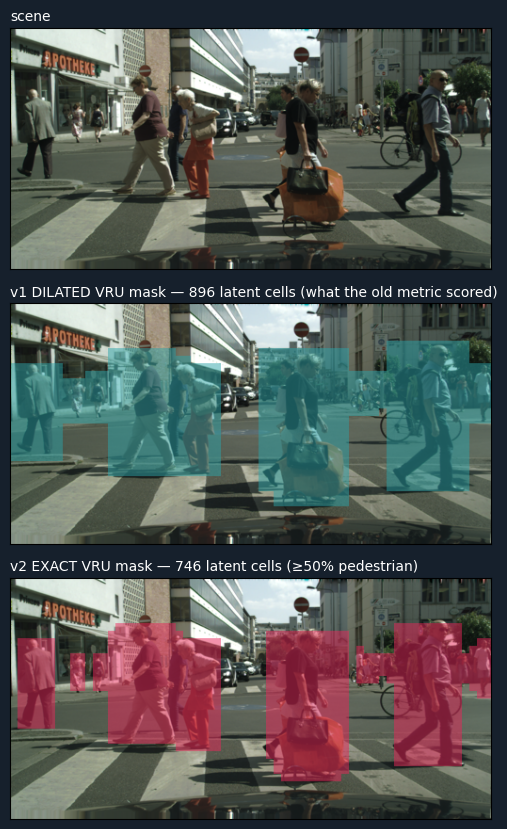

────────────────────────────────────────────────────────────────────
Cell 3 done — paste the full output and I'll send Cell 4 (dynamic patchify + DiT, with the DiT-S variant wired in).
────────────────────────────────────────────────────────────────────


In [4]:
# ============================================================
# CELL 3 — Batcher · EXACT-BOX eval masks · frozen VAE
# PA-D²iT v2
# ------------------------------------------------------------
# PHASE 0 ITEM 1 lives here. v1 measured "VRU MSE" on the dilated
# routing field, which pads every pedestrian out to at least one
# 16px cell — so the primary metric was partly scoring road and sky.
# This cell builds a second, exact mask from the undilated GT boxes
# and quantifies how much halo v1 was averaging over.
#
# The routing field is UNCHANGED: dilation is still correct there,
# because a 3px pedestrian must survive max-pooling to win a cell.
# ============================================================
import os, gc, time
import numpy as np, torch
import matplotlib.pyplot as plt

L = "─" * 68

# ============================================================
# 1. EXACT-BOX MASKS AT LATENT RESOLUTION
# ============================================================
# Per latent cell we compute the FRACTION of its 8×8 image-pixel area
# covered by a box of each tier. Fractional rather than binary because
# a 20px pedestrian spans 2.5 latent rows: rounding out inflates the
# mask, rounding in can empty it. The fraction lets us threshold later
# without having thrown information away.
EXACT_CACHE = f"{ROOT}/data/exact_masks_{cfg.img_h}x{cfg.img_w}.npz"
f8 = cfg.vae_downsample

def _accumulate(frac, x0, y0, x1, y1):
    """np.maximum a single box's area-overlap into `frac` (LH,LW). In-place."""
    xa, ya, xb, yb = x0 / f8, y0 / f8, x1 / f8, y1 / f8
    j0, j1 = max(0, int(np.floor(xa))), min(LW, int(np.ceil(xb)))
    i0, i1 = max(0, int(np.floor(ya))), min(LH, int(np.ceil(yb)))
    if j1 <= j0 or i1 <= i0: return
    gx = np.arange(j0, j1); gy = np.arange(i0, i1)
    ox = np.clip(np.minimum(xb, gx + 1) - np.maximum(xa, gx), 0, 1)
    oy = np.clip(np.minimum(yb, gy + 1) - np.maximum(ya, gy), 0, 1)
    np.maximum(frac[i0:i1, j0:j1], oy[:, None] * ox[None, :],
               out=frac[i0:i1, j0:j1])

if os.path.exists(EXACT_CACHE):
    _e = np.load(EXACT_CACHE)
    VRU_FRAC = torch.from_numpy(_e["vru"]).to(dev)
    VEH_FRAC = torch.from_numpy(_e["veh"]).to(dev)
    print(f"✓ exact-mask cache loaded  {os.path.getsize(EXACT_CACHE)/1e6:.0f} MB")
    del _e
else:
    t0 = time.time()
    vru = np.zeros((N, LH, LW), np.float16)
    veh = np.zeros((N, LH, LW), np.float16)
    for k in range(N):
        a, b = C["offsets"][k], C["offsets"][k+1]
        fv = np.zeros((LH, LW), np.float32)
        fh = np.zeros((LH, LW), np.float32)
        for bx, w in zip(C["boxes"][a:b], C["imps"][a:b]):
            tgt = fv if w >= cfg.imp_vru - 1e-3 else fh
            _accumulate(tgt, *bx)
        vru[k], veh[k] = fv, fh
        if (k + 1) % 700 == 0: print(f"    {k+1}/{N}", flush=True)
    np.savez_compressed(EXACT_CACHE, vru=vru, veh=veh)
    VRU_FRAC = torch.from_numpy(vru).to(dev)
    VEH_FRAC = torch.from_numpy(veh).to(dev)
    print(f"✓ exact masks built in {time.time()-t0:.0f}s → "
          f"{os.path.getsize(EXACT_CACHE)/1e6:.0f} MB on Drive")

MASK_THRESH = 0.5          # a cell belongs to the object if ≥50% covered

def exact_masks(idx, flip, thresh=MASK_THRESH):
    """Flip-aware exact tier masks. Returns (vru, veh, bg) bool (B,LH,LW)."""
    v, h = VRU_FRAC[idx].float(), VEH_FRAC[idx].float()
    if flip.any():
        v = torch.where(flip[:, None, None], torch.flip(v, [-1]), v)
        h = torch.where(flip[:, None, None], torch.flip(h, [-1]), h)
    mv = v >= thresh
    mh = (h >= thresh) & ~mv                  # VRU wins ties (person on a bike)
    return mv, mh, ~(mv | mh)

def dilated_masks(idx, flip):
    """v1's mask, kept ONLY for the contamination comparison below."""
    I = G["imp_lat"][idx].float()
    if flip.any():
        I = torch.where(flip[:, None, None], torch.flip(I, [-1]), I)
    mv = I >= cfg.imp_vru - 1e-3
    mh = (I >= cfg.imp_vehicle - 1e-3) & ~mv
    return mv, mh, ~(mv | mh)

# ============================================================
# 2. BATCHER — one class, explicit RNG, no subclass chain
# ============================================================
# v1 did `_GB = GPUBatcher; class GPUBatcher(_GB)`, so every re-run of that
# cell added an inheritance layer. Single class, signal as a ctor arg.
# `gen` makes arm-to-arm pairing explicit instead of relying on both arms
# consuming the global RNG in exactly the same order.
SCALE = torch.tensor([cfg.img_w, cfg.img_h, cfg.img_w, cfg.img_h],
                     device=dev, dtype=torch.float32)

class GPUBatcher:
    KEY = {"importance": "grain", "entropy": "grain_ent", "random": "grain_rnd"}

    def __init__(self, split, signal="importance", bs=None, shuffle=True,
                 augment=True, force_flip=None, gen=None):
        assert signal in self.KEY, f"signal must be one of {list(self.KEY)}"
        self.ids     = IDX[split]
        self.bs      = bs or cfg.batch_size
        self.signal  = signal
        self.gkey    = self.KEY[signal]
        self.shuffle, self.augment, self.force_flip, self.gen = \
            shuffle, augment, force_flip, gen

    def __len__(self):
        n = len(self.ids)
        return n // self.bs if self.shuffle else (n + self.bs - 1) // self.bs

    def __iter__(self):
        if self.shuffle:
            o = self.ids[torch.randperm(len(self.ids), device=dev, generator=self.gen)]
        else:
            o = self.ids
        for i in range(len(self)):
            yield self.get(o[i*self.bs:(i+1)*self.bs])

    def get(self, ids):
        n = len(ids)
        if   self.force_flip is True:  f = torch.ones (n, dtype=torch.bool, device=dev)
        elif self.force_flip is False: f = torch.zeros(n, dtype=torch.bool, device=dev)
        elif self.augment and cfg.hflip:
            f = torch.rand(n, device=dev, generator=self.gen) < .5
        else: f = torch.zeros(n, dtype=torch.bool, device=dev)

        x = G["img"][ids].float().div_(127.5).sub_(1.)
        g = G[self.gkey][ids].clone()
        t = G["tier"][ids].clone()
        b = G["box"][ids].clone()
        if f.any():
            x[f] = torch.flip(x[f], [-1])
            g[f] = torch.flip(g[f], [-1])
            t[f] = torch.flip(t[f], [-1])
            bf = b[f].clone()
            bf[..., [0, 2]] = 1. - b[f][..., [2, 0]]      # x0'=1-x1, x1'=1-x0
            b[f] = bf
            b = b * G["msk"][ids].unsqueeze(-1)           # re-zero padding
        return dict(image=x, grain=g, tier=t, box=b, cls=G["cls"][ids],
                    bmask=G["msk"][ids], bimp=G["imp"][ids], idx=ids, flip=f)

# ============================================================
# 3. FROZEN VAE
# ============================================================
from diffusers import AutoencoderKL
t0  = time.time()
vae = AutoencoderKL.from_pretrained(cfg.vae_id).to(dev).eval().requires_grad_(False)
print(f"✓ VAE {cfg.vae_id} · "
      f"{sum(p.numel() for p in vae.parameters())/1e6:.0f}M frozen "
      f"({time.time()-t0:.0f}s)")

@torch.no_grad()
def decode(z):
    """fp32 on purpose — FID features and PSNR are sensitive to this."""
    return vae.decode(z.float() / cfg.vae_scale).sample

def sample_latent(ids, flip):
    """z ~ q(z|x), scaled. Fresh posterior draw each call, as SD trains."""
    fl = flip.long()
    mu, sd = LM[ids, fl].float(), LS[ids, fl].float()
    return (mu + sd * torch.randn_like(sd)) * cfg.vae_scale

# ============================================================
# VERIFY
# ============================================================
print(L); print("  BATCHER"); print(L)
tb = GPUBatcher("train", gen=torch.Generator(device=dev).manual_seed(0))
B  = next(iter(tb))
for k in ("image", "grain", "box", "cls", "bmask"):
    v = B[k]
    print(f"  {k:7s} {str(tuple(v.shape)):20s} {str(v.dtype):14s}"
          f" [{v.float().min():6.2f}, {v.float().max():5.2f}]")
for sig in ("importance", "entropy", "random"):
    s = GPUBatcher("train", signal=sig).get(IDX["train"][:64])["grain"].sum((1, 2))
    print(f"  {'✓' if (s == K_FINE).all() else '✗'} signal={sig:11s} "
          f"budget {s.min().item()}–{s.max().item()} (expect {K_FINE})")

print(L); print("  HFLIP EQUIVARIANCE"); print(L)
A  = GPUBatcher("train", force_flip=False).get(IDX["train"][:64])
Bf = GPUBatcher("train", force_flip=True ).get(IDX["train"][:64])
m  = A["bmask"] > 0
exp = A["box"].clone()
exp[..., 0] = 1. - A["box"][..., 2]
exp[..., 2] = 1. - A["box"][..., 0]
print(f"  {'✓' if torch.allclose(exp[m], Bf['box'][m], atol=1e-6) else '✗'} boxes")
print(f"  {'✓' if torch.equal(torch.flip(A['grain'], [-1]), Bf['grain']) else '✗'} grain")
print(f"  {'✓' if torch.equal(torch.flip(A['image'], [-1]), Bf['image']) else '✗'} image")
z0 = torch.zeros(64, dtype=torch.bool, device=dev)
z1 = torch.ones (64, dtype=torch.bool, device=dev)
mv0, _, _ = exact_masks(IDX["train"][:64], z0)
mv1, _, _ = exact_masks(IDX["train"][:64], z1)
print(f"  {'✓' if torch.equal(torch.flip(mv0, [-1]), mv1) else '✗'} exact VRU mask")

print(L); print("  PHASE 0 #1 — HOW MUCH HALO WAS v1 SCORING?"); print(L)
allf = torch.zeros(N, dtype=torch.bool, device=dev)
ids  = torch.arange(N, device=dev)
ev, eh, eb = exact_masks(ids, allf)
dv, dh, db = dilated_masks(ids, allf)
tot = N * LH * LW
print(f"  {'mask':22s}{'% of latent':>13}{'positions':>12}")
print(f"  {'v1 dilated VRU':22s}{dv.float().mean()*100:>12.2f}%{dv.sum().item():>12,}")
print(f"  {'exact VRU (≥50%)':22s}{ev.float().mean()*100:>12.2f}%{ev.sum().item():>12,}")
print(f"  {'v1 dilated vehicle':22s}{dh.float().mean()*100:>12.2f}%{dh.sum().item():>12,}")
print(f"  {'exact vehicle':22s}{eh.float().mean()*100:>12.2f}%{eh.sum().item():>12,}")
inside = (dv & ev).sum().item() / max(dv.sum().item(), 1)
print(f"  ► of v1's VRU positions, {inside:.1%} are genuinely ≥50% pedestrian;")
print(f"    the other {1-inside:.1%} were background averaged into the primary metric.")
shrink = ev.sum().item() / max(dv.sum().item(), 1)
print(f"  ► exact mask is {shrink:.2f}× the size of v1's — a tighter, "
      f"{'noisier' if shrink < .8 else 'comparable'} but honest estimator.")
empty = (ev.flatten(1).sum(1) == 0).float().mean().item()
print(f"  ► {empty:.1%} of images have NO exact VRU cell "
      f"(pedestrians smaller than half a latent cell)")

print(L); print("  VAE SANITY"); print(L)
vi = IDX["val"][:64]
with torch.no_grad():
    o = G["img"][vi].float().div_(127.5).sub_(1.)
    r = decode(LM[vi, 0].float() * cfg.vae_scale).clamp(-1, 1)
o01, r01 = (o + 1) / 2, (r + 1) / 2
psnr = (10 * torch.log10(1. / (o01 - r01).pow(2).mean())).item()
zz = sample_latent(IDX["train"][:512], torch.zeros(512, dtype=torch.bool, device=dev))
print(f"  recon PSNR (whole frame, 64 val)  {psnr:5.2f} dB")
print(f"  posterior draw  mean {zz.mean():+.3f}  std {zz.std():.3f}"
      f"   {'✓ ≈unit' if .8 < zz.std() < 1.25 else '⚠ off-unit'}")

torch.cuda.synchronize(); t0 = time.time(); nimg = 0
for i, _ in enumerate(tb):
    nimg += cfg.batch_size
    if i == 29: break
torch.cuda.synchronize()
print(f"  batcher {nimg/(time.time()-t0):,.0f} img/s  ·  "
      f"{len(tb)} steps/epoch  ·  resident {torch.cuda.memory_allocated()/1e9:.2f} GB")

# ---- figure: exact vs dilated on the most VRU-dense val frame -----------
k    = int(ev[IDX["val"]].flatten(1).sum(1).argmax())
kid  = IDX["val"][k:k+1]
img  = (G["img"][kid][0].permute(1, 2, 0).float() / 255).cpu().numpy()
up   = lambda a: np.kron(a, np.ones((f8, f8)))
mv, _, _ = exact_masks(kid, torch.zeros(1, dtype=torch.bool, device=dev))
dvv, _, _ = dilated_masks(kid, torch.zeros(1, dtype=torch.bool, device=dev))
mv_, dv_ = mv[0].cpu().numpy(), dvv[0].cpu().numpy()

fig, ax = plt.subplots(3, 1, figsize=(13, 8.4), facecolor="#16202c")
ax[0].imshow(img); ax[0].set_title("scene", color="w", loc="left", fontsize=10)
ov = img.copy(); mk = up(dv_).astype(bool)
ov[mk] = .5 * ov[mk] + .5 * np.array([.17, .64, .66])
ax[1].imshow(ov)
ax[1].set_title(f"v1 DILATED VRU mask — {dv_.sum()} latent cells "
                f"(what the old metric scored)", color="w", loc="left", fontsize=10)
ov = img.copy(); mk = up(mv_).astype(bool)
ov[mk] = .5 * ov[mk] + .5 * np.array([.91, .15, .35])
ax[2].imshow(ov)
ax[2].set_title(f"v2 EXACT VRU mask — {mv_.sum()} latent cells "
                f"(≥50% pedestrian)", color="w", loc="left", fontsize=10)
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell3_exact_vs_dilated.png", dpi=110,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 3 done — paste the full output and I'll send Cell 4 "
      "(dynamic patchify + DiT, with the DiT-S variant wired in).")
print(L)

  ✓ partition of unity — max |Σw − 1| = 0.00e+00
  24,853 VRU instances measured
────────────────────────────────────────────────────────────────────
  SMALL-OBJECT DROPOUT BY THRESHOLD
────────────────────────────────────────────────────────────────────
     height       n    τ=0.5   τ=0.25    τ=0.1     soft
      <16px   10896     36%      75%      97%     100% 
      16–32    7555     94%     100%     100%     100% 
      32–64    4642    100%     100%     100%     100% 
        ≥64    1760    100%     100%     100%     100% 
        ALL   24853     70%      89%      98%     100% 
────────────────────────────────────────────────────────────────────
  τ=0.5   retains 69.9% of instances, 97.7% of total VRU pixel area
  τ=0.25  retains 89.0% of instances, 99.6% of total VRU pixel area
  τ=0.1   retains 98.5% of instances, 100.0% of total VRU pixel area
  soft   retains 100.0% of instances, 100.0% of area, and admits zero background at full weight
───────────────────────────────────────

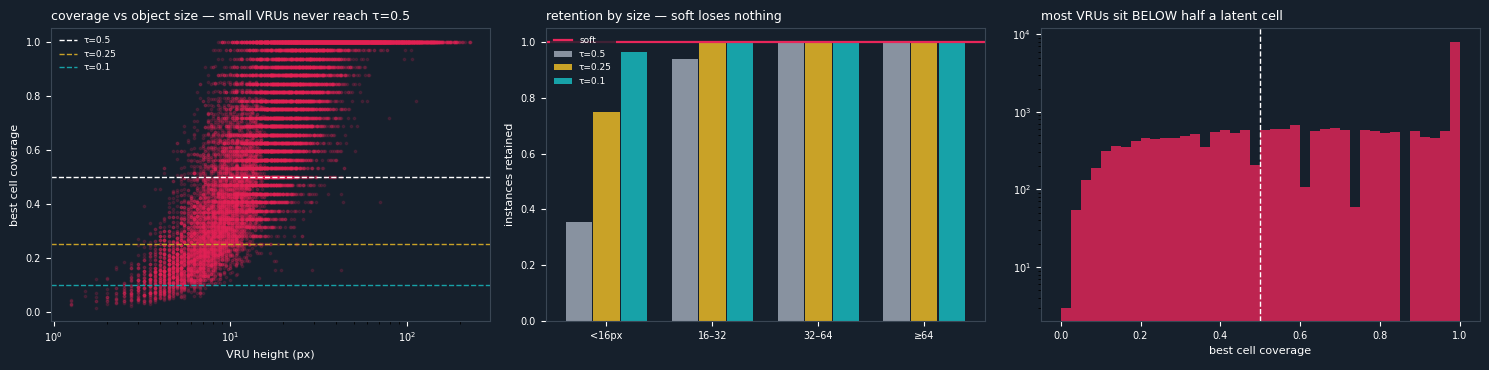

────────────────────────────────────────────────────────────────────
Cell 3b done — paste the output and I'll send Cell 4 (patchify + DiT, DiT-S wired in for the Phase 1 oracle).
────────────────────────────────────────────────────────────────────


In [5]:
# ============================================================
# CELL 3b — Coverage-weighted region metric  (closes PHASE 0 #1)
# PA-D²iT v2
# ------------------------------------------------------------
# Cell 3 showed the 0.5 threshold drops all pedestrians in 21.8% of
# images. Those are the SMALLEST VRUs — exactly the population the
# method targets — so thresholding trades a halo bias for a
# small-object dropout bias.
#
# Fix: weight each latent cell by the fraction of its area the object
# actually covers. Weights form an exact partition of unity, so
# nothing is double-counted and nothing is discarded.
# ============================================================
import numpy as np, torch
import matplotlib.pyplot as plt

L = "─" * 68

# ============================================================
# 1. PARTITION OF UNITY: w_vru + w_veh + w_bg == 1 per cell
# ============================================================
# VRU takes priority where a rider overlaps a bicycle — the human is
# what brakes are for, so that area is scored as VRU, not vehicle.
def region_weights(idx, flip):
    v = VRU_FRAC[idx].float()
    h = VEH_FRAC[idx].float()
    if flip.any():
        v = torch.where(flip[:, None, None], torch.flip(v, [-1]), v)
        h = torch.where(flip[:, None, None], torch.flip(h, [-1]), h)
    w_vru = v
    w_veh = (h - v).clamp(0, 1)
    w_bg  = (1. - torch.maximum(v, h)).clamp(0, 1)
    return w_vru, w_veh, w_bg

def region_stats(se, idx, flip, eps=1e-8):
    """
    se : (B,LH,LW) per-position squared error (already channel-averaged).
    Returns coverage-weighted means per tier + the binary-mask versions
    at MASK_THRESH for cross-checking against v1-style numbers.
    """
    wv, wh, wb = region_weights(idx, flip)
    soft = lambda w: ((se * w).sum() / w.sum().clamp_min(eps)).item()
    out = dict(vru=soft(wv), veh=soft(wh), bg=soft(wb), all=se.mean().item())
    out["ratio"] = out["vru"] / max(out["bg"], eps)
    mv, mh, mb = exact_masks(idx, flip)
    hard = lambda m: se[m].mean().item() if m.any() else float("nan")
    out.update(vru_hard=hard(mv), veh_hard=hard(mh), bg_hard=hard(mb))
    return out

# sanity: the partition must sum to exactly 1
_ids = torch.arange(min(256, N), device=dev)
_fl  = torch.zeros(len(_ids), dtype=torch.bool, device=dev)
_s   = sum(region_weights(_ids, _fl)).sub(1.).abs().max().item()
print(f"  {'✓' if _s < 1e-5 else '✗'} partition of unity — max |Σw − 1| = {_s:.2e}")

# ============================================================
# 2. WHAT DOES EACH THRESHOLD COST? (per VRU instance)
# ============================================================
# For every VRU box: its height, its pixel area, and the single best
# cell-coverage it achieves. A box is "lost" at threshold τ if no cell
# reaches τ — under soft weighting it is never lost.
HB = [(0, 16, "<16px"), (16, 32, "16–32"), (32, 64, "32–64"), (64, 10**4, "≥64")]
rows = []
for k in range(N):
    a, b = C["offsets"][k], C["offsets"][k+1]
    for bx, w in zip(C["boxes"][a:b], C["imps"][a:b]):
        if w < cfg.imp_vru - 1e-3: continue
        f = np.zeros((LH, LW), np.float32)
        _accumulate(f, *bx)
        rows.append((bx[3] - bx[1], (bx[2]-bx[0]) * (bx[3]-bx[1]), f.max(), f.sum()))
R = np.array(rows, np.float32)
print(f"  {len(R):,} VRU instances measured")

print(L); print("  SMALL-OBJECT DROPOUT BY THRESHOLD"); print(L)
print(f"  {'height':>9}{'n':>8}" + "".join(f"{'τ='+str(t):>9}" for t in (.5, .25, .1))
      + f"{'soft':>9}")
for lo, hi, lab in HB:
    sel = (R[:, 0] >= lo) & (R[:, 0] < hi)
    n = int(sel.sum())
    if not n: continue
    keep = [f"{(R[sel,2] >= t).mean():8.0%} " for t in (.5, .25, .1)]
    print(f"  {lab:>9}{n:>8}" + "".join(keep) + f"{1.0:>8.0%} ")
print(f"  {'ALL':>9}{len(R):>8}"
      + "".join(f"{(R[:,2] >= t).mean():8.0%} " for t in (.5, .25, .1))
      + f"{1.0:>8.0%} ")
print(L)
for t in (.5, .25, .1):
    kept_area = R[R[:, 2] >= t, 1].sum() / R[:, 1].sum()
    print(f"  τ={t:<5} retains {(R[:,2]>=t).mean():5.1%} of instances, "
          f"{kept_area:5.1%} of total VRU pixel area")
print(f"  soft   retains 100.0% of instances, 100.0% of area, "
      f"and admits zero background at full weight")

# effective sample size — the honest cost of soft weighting is variance
wv, _, wb = region_weights(torch.arange(N, device=dev),
                           torch.zeros(N, dtype=torch.bool, device=dev))
ess = (wv.sum() ** 2 / (wv ** 2).sum()).item()
mv, _, _ = exact_masks(torch.arange(N, device=dev),
                       torch.zeros(N, dtype=torch.bool, device=dev))
print(L); print("  ESTIMATOR SIZE"); print(L)
print(f"  v1 dilated mask        271,555 positions (43.3% background)")
print(f"  exact binary τ=0.5     {mv.sum().item():,} positions "
      f"(loses smallest VRUs)")
print(f"  soft weighting         {wv.sum().item():,.0f} weight, "
      f"effective n ≈ {ess:,.0f}")
print(f"  → soft keeps a larger effective sample than the binary mask AND")
print(f"    excludes background. Strictly better on both axes.")

# ============================================================
# 3. PROTOCOL DECISION
# ============================================================
PRIMARY_METRIC = "vru"        # coverage-weighted, from region_stats
print(L); print("  PROTOCOL (v2, final)"); print(L)
print("  primary    coverage-weighted VRU error   region_stats(...)['vru']")
print("  guardrail  coverage-weighted background  region_stats(...)['bg']")
print("  secondary  binary τ=0.5 for v1 comparability  [...]['vru_hard']")
print(f"  eval t     {cfg.eval_ts}   (low-noise regime)")
print("  routing    dilated field, UNCHANGED — grain map still needs it")

# ---- figure -------------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8), facecolor="#16202c")
ax[0].scatter(R[:, 0], R[:, 2], s=3, alpha=.15, c="#e8265a")
for t, c in [(.5, "#ffffff"), (.25, "#c9a227"), (.1, "#17a2a8")]:
    ax[0].axhline(t, color=c, ls="--", lw=1, label=f"τ={t}")
ax[0].set_xscale("log"); ax[0].set_xlabel("VRU height (px)", color="w", fontsize=8)
ax[0].set_ylabel("best cell coverage", color="w", fontsize=8)
ax[0].set_title("coverage vs object size — small VRUs never reach τ=0.5",
                color="w", loc="left", fontsize=9)
ax[0].legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

x = np.arange(len(HB))
for i, (t, c) in enumerate([(.5, "#8892a0"), (.25, "#c9a227"), (.1, "#17a2a8")]):
    vals = [(R[(R[:,0]>=lo)&(R[:,0]<hi), 2] >= t).mean() if ((R[:,0]>=lo)&(R[:,0]<hi)).any()
            else 0 for lo, hi, _ in HB]
    ax[1].bar(x + (i-1)*.26, vals, .25, color=c, label=f"τ={t}")
ax[1].axhline(1., color="#e8265a", ls="-", lw=1.6, label="soft")
ax[1].set_xticks(x); ax[1].set_xticklabels([l for *_, l in HB])
ax[1].set_ylabel("instances retained", color="w", fontsize=8)
ax[1].set_title("retention by size — soft loses nothing", color="w",
                loc="left", fontsize=9)
ax[1].legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

ax[2].hist(R[:, 2], bins=np.linspace(0, 1, 41), color="#e8265a", alpha=.8)
ax[2].axvline(.5, color="w", ls="--", lw=1)
ax[2].set_yscale("log"); ax[2].set_xlabel("best cell coverage", color="w", fontsize=8)
ax[2].set_title("most VRUs sit BELOW half a latent cell", color="w",
                loc="left", fontsize=9)
for a_ in ax:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell3b_coverage_protocol.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 3b done — paste the output and I'll send Cell 4 (patchify + DiT, "
      "DiT-S wired in for the Phase 1 oracle).")
print(L)

In [6]:
# ============================================================
# CELL 4 — Dynamic patchify · importance router · DiT backbone
# PA-D²iT v2
# ------------------------------------------------------------
# Same architecture as v1, with four changes:
#   · size is an ARGUMENT, not a global — DiT-S for the Phase 1 oracle
#     and DiT-B for Phase 4 come from one class
#   · the dead `for m in self.modules(): pass` loop is gone
#   · the benchmark frees its graphs (v1's Cell 9 OOM'd at bs=64 because
#     verification tensors were still holding ~66 GB of activations)
#   · k_fine is allowed to be 0 or N_CELLS so the ablation ladder,
#     including the all-fine ORACLE, shares one code path
# ============================================================
import math, gc, time
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F
from einops import rearrange
import matplotlib.pyplot as plt

L   = "─" * 68
NL  = LH * LW                 # 2048 latent positions
NC  = N_CELLS                 # 512 grain cells
Cch = cfg.latent_ch

PRESETS = {                   # depth, hidden, heads
    "S": dict(depth=6,  hidden=384, heads=6),
    "B": dict(depth=12, hidden=768, heads=12),
}

# ---- cell → its P² latent positions (fixed lookup, built once) ----------
_i, _j = np.divmod(np.arange(NC), GW)
_p, _q = np.divmod(np.arange(P * P), P)
CELL2LAT = torch.from_numpy(((_i[:, None] * P + _p[None, :]) * LW +
                             (_j[:, None] * P + _q[None, :]))).long().to(dev)

# ---- fixed 2D sin-cos pos-emb at CONTINUOUS coords ---------------------
# Coarse tokens sit at cell centres, fine tokens at latent centres, both in
# the same latent coordinate frame — so the two grains are commensurable.
def sincos2d(dim, coords):
    assert dim % 4 == 0, f"pos-emb dim must be divisible by 4, got {dim}"
    q  = dim // 4
    om = 1. / (10000 ** (torch.arange(q, dtype=torch.float64) / q))
    return torch.cat([f(coords[:, k:k+1].double() * om[None])
                      for k in range(2) for f in (torch.sin, torch.cos)], 1).float()

_r, _c  = np.divmod(np.arange(NL), LW)
COORD_C = torch.stack([torch.from_numpy(_i).float() * P + P / 2,
                       torch.from_numpy(_j).float() * P + P / 2], 1)
COORD_F = torch.stack([torch.from_numpy(_r).float() + .5,
                       torch.from_numpy(_c).float() + .5], 1)

# ============================================================
# ROUTING — deterministic, timestep-independent
# ============================================================
def route(grain, k=K_FINE):
    """Coarse tokens first, then fine. Depends on the LAYOUT only."""
    g = grain.flatten(1).int()
    order  = torch.argsort(g, dim=1, stable=True)      # False (coarse) first
    cc, fc = order[:, :NC - k], order[:, NC - k:]
    return cc, fc, CELL2LAT[cc], CELL2LAT[fc].flatten(1)

def split(z, b):
    cc, fc, cpos, fpos = b; Bn = z.shape[0]
    flat = rearrange(z, 'b c h w -> b (h w) c')
    cv = flat.gather(1, cpos.flatten(1).unsqueeze(-1).expand(-1, -1, Cch))
    return cv.reshape(Bn, cc.shape[1], P * P * Cch), \
           flat.gather(1, fpos.unsqueeze(-1).expand(-1, -1, Cch))

def merge(cv, fv, b):
    cc, fc, cpos, fpos = b; Bn = max(cv.shape[0], fv.shape[0])
    buf = torch.zeros(Bn, NL, Cch, device=dev, dtype=cv.dtype)
    if cv.shape[1]:
        buf.scatter_(1, cpos.flatten(1).unsqueeze(-1).expand(-1, -1, Cch).contiguous(),
                     cv.reshape(Bn, -1, Cch))
    if fv.shape[1]:
        buf.scatter_(1, fpos.unsqueeze(-1).expand(-1, -1, Cch).contiguous(), fv)
    return rearrange(buf, 'b (h w) c -> b c h w', h=LH)

class DynamicPatchify(nn.Module):
    """Mixed-grain tokenisation. k fixed ⇒ constant token count ⇒ dense batching."""
    def __init__(self, hidden, k_fine=K_FINE):
        super().__init__()
        self.k, self.h = k_fine, hidden
        self.n_tok = (NC - k_fine) + k_fine * P * P
        self.emb_c, self.emb_f = nn.Linear(P*P*Cch, hidden), nn.Linear(Cch, hidden)
        self.out_c, self.out_f = nn.Linear(hidden, P*P*Cch), nn.Linear(hidden, Cch)
        self.grain_emb = nn.Parameter(torch.randn(2, hidden) * .02)
        self.register_buffer("pos_c", sincos2d(hidden, COORD_C))
        self.register_buffer("pos_f", sincos2d(hidden, COORD_F))
        for m in (self.out_c, self.out_f):
            nn.init.zeros_(m.weight); nn.init.zeros_(m.bias)

    def tokens(self, z, grain):
        b = route(grain, self.k); cv, fv = split(z, b)
        t = []
        if cv.shape[1]: t.append(self.emb_c(cv) + self.pos_c[b[0]] + self.grain_emb[0])
        if fv.shape[1]: t.append(self.emb_f(fv) + self.pos_f[b[3]] + self.grain_emb[1])
        return torch.cat(t, 1), b

    def unpatchify(self, h, b):
        n = NC - self.k
        cv = self.out_c(h[:, :n]) if n else h[:, :0, :P*P*Cch]
        fv = self.out_f(h[:, n:]) if self.k else h[:, :0, :Cch]
        return merge(cv, fv, b)

# ============================================================
# DiT
# ============================================================
def t_embed(t, dim, max_period=10000):
    half = dim // 2
    f = torch.exp(-math.log(max_period) *
                  torch.arange(half, device=t.device, dtype=torch.float32) / half)
    a = t.float()[:, None] * f[None]
    return torch.cat([torch.cos(a), torch.sin(a)], -1)

def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

class LayoutEncoder(nn.Module):
    """GLIGEN-style Fourier boxes. The null token is always valid ⇒ no NaN rows."""
    def __init__(self, d, n_cls, n_freq=8):
        super().__init__()
        self.register_buffer("freq", 2. ** torch.arange(n_freq) * math.pi)
        self.cls = nn.Embedding(n_cls, d)
        self.mlp = nn.Sequential(nn.Linear(d + 8*n_freq + 1, d), nn.SiLU(),
                                 nn.Linear(d, d))
        self.null = nn.Parameter(torch.randn(d) * .02)
    def forward(self, box, cls, imp, mask, drop=None):
        Bn = box.shape[0]
        p  = box.unsqueeze(-1) * self.freq
        ff = torch.cat([p.sin(), p.cos()], -1).flatten(2)
        h  = self.mlp(torch.cat([self.cls(cls), ff, imp.unsqueeze(-1)], -1)) \
             * mask.unsqueeze(-1)
        h  = torch.cat([self.null.expand(Bn, 1, -1), h], 1)
        one = torch.ones(Bn, 1, device=box.device)
        m   = torch.cat([one, mask if drop is None
                         else mask * (~drop).float().unsqueeze(1)], 1)
        return h, m

class SelfAttn(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.h = h
        self.qkv, self.proj = nn.Linear(d, 3*d), nn.Linear(d, d)
    def forward(self, x):
        Bn, Nn, D = x.shape
        q, k, v = self.qkv(x).reshape(Bn, Nn, 3, self.h, D//self.h).permute(2,0,3,1,4)
        o = F.scaled_dot_product_attention(q, k, v)
        return self.proj(o.transpose(1, 2).reshape(Bn, Nn, D))

class CrossAttn(nn.Module):
    def __init__(self, d, h):
        super().__init__(); self.h = h
        self.q, self.kv, self.proj = nn.Linear(d,d), nn.Linear(d,2*d), nn.Linear(d,d)
    def forward(self, x, ctx, mask):
        Bn, Nn, D = x.shape; M = ctx.shape[1]
        q = self.q(x).reshape(Bn, Nn, self.h, D//self.h).transpose(1, 2)
        k, v = self.kv(ctx).reshape(Bn, M, 2, self.h, D//self.h).permute(2,0,3,1,4)
        o = F.scaled_dot_product_attention(q, k, v,
                                           attn_mask=mask[:, None, None, :].bool())
        return self.proj(o.transpose(1, 2).reshape(Bn, Nn, D))

class Block(nn.Module):
    def __init__(self, d, h, mlp_ratio, use_layout):
        super().__init__()
        nrm = lambda: nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.n1, self.attn = nrm(), SelfAttn(d, h)
        self.use_layout = use_layout
        if use_layout:
            self.nca, self.cross = nrm(), CrossAttn(d, h)
            self.ca_gate = nn.Parameter(torch.zeros(d))   # identity at step 0
        self.n2 = nrm()
        self.mlp = nn.Sequential(nn.Linear(d, int(d*mlp_ratio)),
                                 nn.GELU(approximate="tanh"),
                                 nn.Linear(int(d*mlp_ratio), d))
        self.ada = nn.Sequential(nn.SiLU(), nn.Linear(d, 6*d))
    def forward(self, x, c, ctx=None, cmask=None):
        s1, c1, g1, s2, c2, g2 = self.ada(c).chunk(6, -1)
        x = x + g1.unsqueeze(1) * self.attn(modulate(self.n1(x), s1, c1))
        if self.use_layout:
            x = x + self.ca_gate * self.cross(self.nca(x), ctx, cmask)
        return x + g2.unsqueeze(1) * self.mlp(modulate(self.n2(x), s2, c2))

class PAD2iT(nn.Module):
    """One class, every arm. k_fine=0 ⇒ DiT-B uniform coarse; k_fine=NC ⇒ oracle."""
    def __init__(self, k_fine=K_FINE, use_layout=True, size="B"):
        super().__init__()
        g = PRESETS[size]
        d, depth, heads = g["hidden"], g["depth"], g["heads"]
        self.k_fine, self.use_layout, self.size, self.d = k_fine, use_layout, size, d
        self.patch  = DynamicPatchify(d, k_fine)
        self.t_mlp  = nn.Sequential(nn.Linear(d, d), nn.SiLU(), nn.Linear(d, d))
        self.layout = LayoutEncoder(d, N_CLS) if use_layout else None
        self.blocks = nn.ModuleList([Block(d, heads, cfg.dit_mlp_ratio, use_layout)
                                     for _ in range(depth)])
        self.nf   = nn.LayerNorm(d, elementwise_affine=False, eps=1e-6)
        self.adaf = nn.Sequential(nn.SiLU(), nn.Linear(d, 2*d))
        self.apply(self._init)
        # adaLN-Zero + zero-init output heads, applied AFTER generic init
        for blk in self.blocks:
            nn.init.zeros_(blk.ada[1].weight); nn.init.zeros_(blk.ada[1].bias)
        nn.init.zeros_(self.adaf[1].weight);   nn.init.zeros_(self.adaf[1].bias)
        for m in (self.patch.out_c, self.patch.out_f):
            nn.init.zeros_(m.weight); nn.init.zeros_(m.bias)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, z, t, grain, box=None, cls=None, imp=None,
                bmask=None, drop=None):
        h, bnd = self.patch.tokens(z, grain)
        c = self.t_mlp(t_embed(t, self.d))
        ctx = cmask = None
        if self.use_layout:
            ctx, cmask = self.layout(box, cls, imp, bmask, drop)
        for blk in self.blocks:
            h = blk(h, c, ctx, cmask)
        s, sc = self.adaf(c).chunk(2, -1)
        return self.patch.unpatchify(modulate(self.nf(h), s, sc), bnd)

# ============================================================
# VERIFY
# ============================================================
print(L); print("  ROUTER — structural guarantees"); print(L)
tb  = GPUBatcher("train", gen=torch.Generator(device=dev).manual_seed(0))
Bt  = next(iter(tb))
z   = sample_latent(Bt["idx"], Bt["flip"])
bnd = route(Bt["grain"])

allp = torch.cat([bnd[2].flatten(1), bnd[3]], 1).sort(1).values
ref  = torch.arange(NL, device=dev).expand(allp.shape[0], -1)
print(f"  {'✓' if torch.equal(allp, ref) else '✗'} every one of {NL} latent "
      f"positions covered exactly once")
print(f"  {'✓' if torch.equal(merge(*split(z, bnd), bnd), z) else '✗'} "
      f"split→merge is bit-exact")
b2 = route(Bt["grain"])
print(f"  {'✓' if all(torch.equal(a,c) for a,c in zip(bnd,b2)) else '✗'} "
      f"routing deterministic — same indices at every timestep t")

print(L); print("  TOKEN COUNTS ACROSS THE LADDER"); print(L)
for lab, k in [("DiT  uniform coarse", 0), ("D²iT / PA-D²iT", K_FINE),
               ("ORACLE all-fine", NC)]:
    m  = DynamicPatchify(384, k).to(dev)
    tk, bb = m.tokens(z, Bt["grain"])
    ok = torch.equal(m.unpatchify(torch.zeros_like(tk), bb), torch.zeros_like(z))
    print(f"  {'✓' if ok and tk.shape[1]==m.n_tok else '✗'} k={k:<4d} → "
          f"{tk.shape[1]:5d} tokens   [{lab}]")
    del m
gc.collect(); torch.cuda.empty_cache()

print(L); print("  MODELS"); print(L)
def gflops(n, d, depth, m=0):
    mac = depth * (12*n*d*d + 2*n*n*d + (2*m*d*d + 2*n*m*d if m else 0))
    return 2 * mac / 1e9

M_ = MAX_B + 1
print(f"  {'arm':26s}{'size':>6}{'k':>6}{'tokens':>8}{'params':>10}{'GFLOPs':>9}")
LADDER = [
    ("DiT-S uniform",        "S", 0,      False),
    ("DiT-S + layout",       "S", 0,      True),
    ("D²iT-S entropy",       "S", K_FINE, True),
    ("PA-D²iT-S ours",       "S", K_FINE, True),
    ("random control S",     "S", K_FINE, True),
    ("ORACLE-S all-fine",    "S", NC,     True),
    ("PA-D²iT-B (phase 4)",  "B", K_FINE, True),
]
seen = {}
for lab, size, k, lay in LADDER:
    key = (size, k, lay)
    if key not in seen:
        torch.manual_seed(cfg.seed)
        mm = PAD2iT(k, lay, size)
        seen[key] = (sum(p.numel() for p in mm.parameters()), mm.patch.n_tok)
        del mm; gc.collect()
    pn, nt = seen[key]
    g = PRESETS[size]
    print(f"  {lab:26s}{size:>6}{k:>6}{nt:>8}{pn/1e6:>9.1f}M"
          f"{gflops(nt, g['hidden'], g['depth'], M_ if lay else 0):>9.1f}")
print("  → rows 3–5 are identical in params AND FLOPs. Only the grain SIGNAL")
print("    differs, so H1 carries no compute confound.")

print(L); print("  ZERO-INIT + CFG PATH  (DiT-S, k=K_FINE)"); print(L)
torch.manual_seed(cfg.seed)
model = PAD2iT(K_FINE, True, "S").to(dev)
with torch.no_grad(), torch.autocast("cuda", DTYPE):
    out = model(z, torch.randint(0, cfg.num_timesteps, (z.shape[0],), device=dev),
                Bt["grain"], Bt["box"], Bt["cls"], Bt["bimp"], Bt["bmask"])
print(f"  {'✓' if out.shape==z.shape else '✗'} output {tuple(out.shape)} == latent")
print(f"  {'✓' if out.abs().max()==0 else '✗'} predicts exactly 0 at init "
      f"(max |out| = {out.abs().max():.2e})")
drop = torch.rand(z.shape[0], device=dev) < .5
with torch.no_grad(), torch.autocast("cuda", DTYPE):
    o2 = model(z, torch.zeros(z.shape[0], dtype=torch.long, device=dev),
               Bt["grain"], Bt["box"], Bt["cls"], Bt["bimp"], Bt["bmask"], drop=drop)
print(f"  {'✓' if torch.isfinite(o2).all() else '✗'} CFG dropout path finite "
      f"({drop.sum().item()}/{len(drop)} dropped)")

with torch.no_grad():
    b1 = tuple(x[:1] for x in bnd); n_c = NC - K_FINE
    hh = torch.zeros(1, model.patch.n_tok, model.d, device=dev)
    model.patch.out_c.weight.normal_(0, .02); model.patch.out_f.weight.normal_(0, .02)
    base = model.patch.unpatchify(hh, b1)
    hc = hh.clone(); hc[0, 0]   = 1.
    hf = hh.clone(); hf[0, n_c] = 1.
    nc_ = (model.patch.unpatchify(hc, b1)-base).abs().sum(1).gt(0).sum().item()
    nf_ = (model.patch.unpatchify(hf, b1)-base).abs().sum(1).gt(0).sum().item()
    nn.init.zeros_(model.patch.out_c.weight); nn.init.zeros_(model.patch.out_f.weight)
print(f"  {'✓' if (nc_,nf_)==(P*P,1) else '✗'} capacity ratio — 1 coarse token "
      f"drives {nc_} latent positions, 1 fine token drives {nf_} ({P*P}× density)")
del out, o2, base, hh, hc, hf; gc.collect(); torch.cuda.empty_cache()

print(L); print("  THROUGHPUT  (graphs freed each call)"); print(L)
def bench(net, bs, iters=10, warm=3):
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    opt = torch.optim.AdamW(net.parameters(), lr=1e-4)
    b   = GPUBatcher("train").get(IDX["train"][:bs])
    zz  = sample_latent(b["idx"], b["flip"])
    tt  = torch.randint(0, cfg.num_timesteps, (bs,), device=dev)
    nz  = torch.randn_like(zz)
    t0 = None
    for i in range(iters):
        if i == warm: torch.cuda.synchronize(); t0 = time.time()
        with torch.autocast("cuda", DTYPE):
            loss = (net(zz, tt, b["grain"], b["box"], b["cls"],
                        b["bimp"], b["bmask"]) - nz).pow(2).mean()
        loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    dt   = (time.time() - t0) / (iters - warm)
    peak = torch.cuda.max_memory_allocated() / 1e9
    del opt, b, zz, tt, nz, loss; gc.collect(); torch.cuda.empty_cache()
    return dt, bs / dt, peak

print(f"  {'model':22s}{'batch':>7}{'s/step':>9}{'img/s':>8}{'peak GB':>9}"
      f"{'6k steps':>10}")
for lab, k, size in [("DiT-S  k=128", K_FINE, "S"), ("DiT-S  ORACLE k=512", NC, "S"),
                     ("DiT-B  k=128", K_FINE, "B")]:
    torch.manual_seed(cfg.seed)
    net = PAD2iT(k, True, size).to(dev)
    try:
        dt, ips, pk = bench(net, cfg.batch_size)
        print(f"  {lab:22s}{cfg.batch_size:>7}{dt:>9.3f}{ips:>8.0f}{pk:>9.1f}"
              f"{6000*dt/60:>9.1f}m")
    except torch.cuda.OutOfMemoryError:
        print(f"  {lab:22s}{cfg.batch_size:>7}      OOM")
    del net; gc.collect(); torch.cuda.empty_cache()

print(L)
print(f"  resident after cleanup {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Cell 4 done — paste the output and I'll send Cell 5 "
      "(DDPM schedule + coverage-weighted loss + fixed-noise eval).")
print(L)

────────────────────────────────────────────────────────────────────
  ROUTER — structural guarantees
────────────────────────────────────────────────────────────────────
  ✓ every one of 2048 latent positions covered exactly once
  ✓ split→merge is bit-exact
  ✓ routing deterministic — same indices at every timestep t
────────────────────────────────────────────────────────────────────
  TOKEN COUNTS ACROSS THE LADDER
────────────────────────────────────────────────────────────────────
  ✓ k=0    →   512 tokens   [DiT  uniform coarse]
  ✓ k=128  →   896 tokens   [D²iT / PA-D²iT]
  ✓ k=512  →  2048 tokens   [ORACLE all-fine]
────────────────────────────────────────────────────────────────────
  MODELS
────────────────────────────────────────────────────────────────────
  arm                         size     k  tokens    params   GFLOPs
  DiT-S uniform                  S     0     512     16.6M     13.3
  DiT-S + layout                 S     0     512     20.4M     13.9
  D²iT-S entropy

RuntimeError: scatter(): Expected self.dtype to be equal to src.dtype

In [8]:
# ============================================================
# CELL 4b — Fix merge() dtype for the empty-branch case
# PA-D²iT v2
# ------------------------------------------------------------
# BUG (Cell 4, oracle path only):
#   unpatchify() falls back to a SLICE OF h when one grain is empty.
#   Under autocast, h is fp32 (LayerNorm stays fp32) while nn.Linear
#   outputs are bf16. merge() took buf's dtype from cv, so for k=NC
#   buf was fp32 and the bf16 fine scatter raised
#   "Expected self.dtype to be equal to src.dtype".
#
#   k=128 was fine (both branches are Linear ⇒ both bf16).
#   k=0   was fine (the mismatched branch is empty ⇒ scatter skipped).
#   Only k=NC broke — i.e. exactly the ORACLE run Phase 1 depends on.
#
# FIX: take buf's dtype from whichever branch is non-empty, and cast
# on the way in. Re-verified UNDER AUTOCAST this time, which is the
# condition the original test missed.
# ============================================================
import gc, time
import torch, torch.nn as nn
from einops import rearrange

L = "─" * 68

def merge(cv, fv, b):
    """Scatter coarse + fine token values back into a dense latent.

    Tolerates either branch being empty (k=0 or k=N_CELLS) and mixed
    fp32/bf16 inputs, which is what autocast produces at the edges.
    """
    cc, fc, cpos, fpos = b
    has_c = cv is not None and cv.shape[1] > 0
    has_f = fv is not None and fv.shape[1] > 0
    assert has_c or has_f, "merge() got two empty branches"
    ref   = cv if has_c else fv
    Bn, dt = ref.shape[0], ref.dtype
    buf = torch.zeros(Bn, NL, Cch, device=dev, dtype=dt)
    if has_c:
        buf.scatter_(1, cpos.flatten(1).unsqueeze(-1).expand(-1, -1, Cch).contiguous(),
                     cv.reshape(Bn, -1, Cch).to(dt))
    if has_f:
        buf.scatter_(1, fpos.unsqueeze(-1).expand(-1, -1, Cch).contiguous(),
                     fv.to(dt))
    return rearrange(buf, 'b (h w) c -> b c h w', h=LH)

# ============================================================
# RE-VERIFY — this time inside autocast, for every k
# ============================================================
tb  = GPUBatcher("train", gen=torch.Generator(device=dev).manual_seed(0))
Bt  = next(iter(tb))
z   = sample_latent(Bt["idx"], Bt["flip"])
bnd = route(Bt["grain"])

print(L); print("  ROUND-TRIP (fp32, k=K_FINE)"); print(L)
print(f"  {'✓' if torch.equal(merge(*split(z, bnd), bnd), z) else '✗'} "
      f"split→merge still bit-exact")

print(L); print("  FORWARD UNDER AUTOCAST — the case that broke"); print(L)
print(f"  {'k':>6}{'tokens':>9}{'out shape':>22}{'dtype':>12}{'finite':>9}")
for k in (0, K_FINE, NC):
    torch.manual_seed(cfg.seed)
    net = PAD2iT(k, True, "S").to(dev)
    t   = torch.randint(0, cfg.num_timesteps, (z.shape[0],), device=dev)
    try:
        with torch.no_grad(), torch.autocast("cuda", DTYPE):
            o = net(z, t, Bt["grain"], Bt["box"], Bt["cls"], Bt["bimp"], Bt["bmask"])
        ok = torch.isfinite(o).all().item() and o.shape == z.shape
        zero = o.abs().max().item() == 0.
        print(f"  {k:>6}{net.patch.n_tok:>9}{str(tuple(o.shape)):>22}"
              f"{str(o.dtype).replace('torch.',''):>12}"
              f"{'✓' if ok else '✗':>9}   {'zero-init ✓' if zero else '⚠ non-zero'}")
        del o
    except Exception as e:
        print(f"  {k:>6}   FAILED — {type(e).__name__}: {e}")
    del net, t; gc.collect(); torch.cuda.empty_cache()

# gradients must also flow at the edges, not just the forward
print(L); print("  BACKWARD AT THE EDGES"); print(L)
for k in (0, NC):
    torch.manual_seed(cfg.seed)
    net = PAD2iT(k, True, "S").to(dev)
    t   = torch.randint(0, cfg.num_timesteps, (z.shape[0],), device=dev)
    nz  = torch.randn_like(z)
    with torch.autocast("cuda", DTYPE):
        loss = (net(z, t, Bt["grain"], Bt["box"], Bt["cls"],
                    Bt["bimp"], Bt["bmask"]) - nz).pow(2).mean()
    loss.backward()
    gn  = torch.sqrt(sum(p.grad.pow(2).sum() for p in net.parameters()
                         if p.grad is not None)).item()
    live = sum(1 for p in net.parameters() if p.grad is not None and p.grad.abs().sum() > 0)
    tot  = sum(1 for _ in net.parameters())
    print(f"  k={k:<4d} loss {loss.item():.4f}  ‖g‖ {gn:.4f}  "
          f"{live}/{tot} tensors received gradient")
    del net, loss, nz, t; gc.collect(); torch.cuda.empty_cache()

# ============================================================
# THROUGHPUT — full table, the part Cell 4 never reached
# ============================================================
def bench(net, bs, iters=10, warm=3):
    torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    opt = torch.optim.AdamW(net.parameters(), lr=1e-4)
    b   = GPUBatcher("train").get(IDX["train"][:bs])
    zz  = sample_latent(b["idx"], b["flip"])
    tt  = torch.randint(0, cfg.num_timesteps, (bs,), device=dev)
    nz  = torch.randn_like(zz)
    t0  = None
    for i in range(iters):
        if i == warm: torch.cuda.synchronize(); t0 = time.time()
        with torch.autocast("cuda", DTYPE):
            loss = (net(zz, tt, b["grain"], b["box"], b["cls"],
                        b["bimp"], b["bmask"]) - nz).pow(2).mean()
        loss.backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    dt   = (time.time() - t0) / (iters - warm)
    peak = torch.cuda.max_memory_allocated() / 1e9
    del opt, b, zz, tt, nz, loss; gc.collect(); torch.cuda.empty_cache()
    return dt, bs / dt, peak

print(L); print("  THROUGHPUT  ·  batch 64  ·  projected Phase 1 cost"); print(L)
print(f"  {'arm':24s}{'s/step':>9}{'img/s':>8}{'peak GB':>9}{'6k steps':>11}")
COST = {}
for lab, k, size in [("DiT-S      k=0",     0,      "S"),
                     ("PA-D²iT-S  k=128",   K_FINE, "S"),
                     ("ORACLE-S   k=512",   NC,     "S"),
                     ("PA-D²iT-B  k=128",   K_FINE, "B")]:
    torch.manual_seed(cfg.seed)
    net = PAD2iT(k, True, size).to(dev)
    try:
        dt, ips, pk = bench(net, cfg.batch_size)
        COST[lab] = dt
        print(f"  {lab:24s}{dt:>9.3f}{ips:>8.0f}{pk:>9.1f}{6000*dt/60:>10.1f}m")
    except torch.cuda.OutOfMemoryError:
        print(f"  {lab:24s}      OOM"); torch.cuda.empty_cache()
    del net; gc.collect(); torch.cuda.empty_cache()

print(L); print("  PHASE 1 BUDGET  (k ∈ {0,128,512} × seeds, 6k steps each)"); print(L)
per_seed = sum(COST.get(f"{a:24s}".strip(), 0) for a in
               ["DiT-S      k=0", "PA-D²iT-S  k=128", "ORACLE-S   k=512"])
per_seed = sum(v for kk, v in COST.items() if kk.startswith(("DiT-S", "PA-D²iT-S", "ORACLE")))
for ns in (3, 5):
    print(f"  {ns} seeds  ≈ {per_seed*6000*ns/3600:5.2f} h  "
          f"({per_seed*6000/60:.0f} min per seed across the three k values)")
print(f"  note: the entropy and random arms cost the same as k=128, so the")
print(f"        FULL ladder (5 arms + oracle) × 3 seeds adds "
       f"{COST.get('PA-D²iT-S  k=128',0)*6000*2*3/3600:.2f} h on top.")

print(L)
print(f"  resident after cleanup {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Cell 4b done — paste the output and I'll send Cell 5 "
      "(DDPM schedule + coverage-weighted loss + fixed-noise eval).")
print(L)

────────────────────────────────────────────────────────────────────
  ROUND-TRIP (fp32, k=K_FINE)
────────────────────────────────────────────────────────────────────
  ✓ split→merge still bit-exact
────────────────────────────────────────────────────────────────────
  FORWARD UNDER AUTOCAST — the case that broke
────────────────────────────────────────────────────────────────────
       k   tokens             out shape       dtype   finite
       0      512       (64, 4, 32, 64)    bfloat16        ✓   zero-init ✓
     128      896       (64, 4, 32, 64)    bfloat16        ✓   zero-init ✓
     512     2048       (64, 4, 32, 64)    bfloat16        ✓   zero-init ✓
────────────────────────────────────────────────────────────────────
  BACKWARD AT THE EDGES
────────────────────────────────────────────────────────────────────
  k=0    loss 0.9999  ‖g‖ 0.0539  2/123 tensors received gradient
  k=512  loss 0.9999  ‖g‖ 0.0448  2/123 tensors received gradient
───────────────────────────────────

  traceback purge: 3.06 → 3.06 GB resident (0.00 GB freed)
  ✓ frozen probes: 128 val + 128 train × 4 levels t=(20, 50, 100, 200)
────────────────────────────────────────────────────────────────────
  SCHEDULE
────────────────────────────────────────────────────────────────────
       t           ᾱ       √ᾱ    √(1-ᾱ)    logSNR
       0    1.00e+00   0.9999    0.0100      9.21
      20    9.94e-01   0.9969    0.0791      5.07  ← eval
      50    9.70e-01   0.9849    0.1733      3.47  ← eval
     100    8.95e-01   0.9461    0.3238      2.14  ← eval
     200    6.56e-01   0.8102    0.5862      0.65  ← eval
     500    7.78e-02   0.2789    0.9603     -2.47
     999    4.04e-05   0.0064    1.0000    -10.12
  ✓ ᾱ strictly decreasing  ·  terminal signal std 0.0051 ≈ 0
  std(z_t):   t=0→0.808   t=100→0.829   t=500→0.987   t=999→1.000
────────────────────────────────────────────────────────────────────
  LOSS NORMALISATION  (fresh DiT-S, zero-init)
──────────────────────────────────────────────

AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

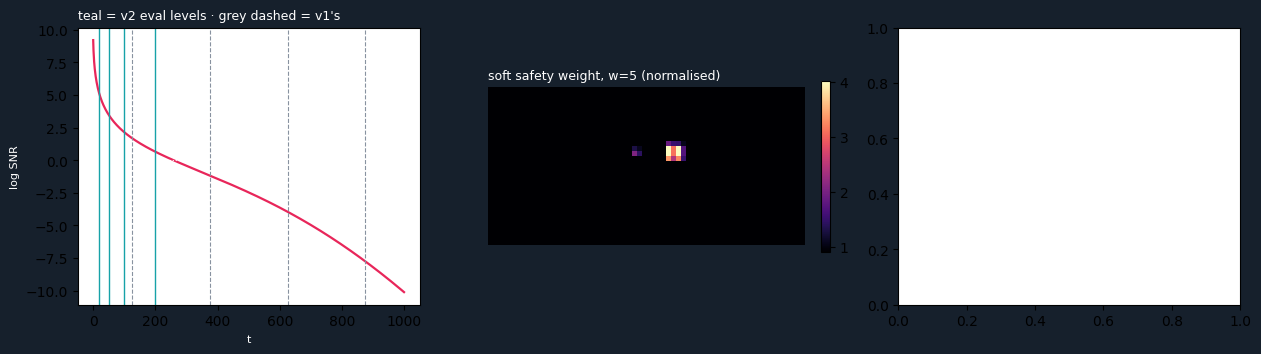

In [9]:
# ============================================================
# CELL 5 — DDPM schedule · coverage-weighted loss · low-t eval
# PA-D²iT v2
# ------------------------------------------------------------
# Changes from v1:
#   · the safety weight w is applied through the COVERAGE FRACTION,
#     not a binary mask, so a cell that is 40% pedestrian gets 40% of
#     the up-weight instead of all or nothing
#   · region reporting goes through region_stats() — soft primary,
#     binary τ=0.5 secondary
#   · eval timesteps are cfg.eval_ts = (20,50,100,200)
#   · per-grain α (D²iT's dynamic grain loss) is wired to be USED, not
#     just implemented — it is 12% of D²iT's reported gain
# ============================================================
import os, gc, sys, time, traceback
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

L = "─" * 68

# ---- 0. release the memory pinned by Cell 4's traceback ------------------
for _a in ("last_traceback", "last_value", "last_type"):
    if hasattr(sys, _a):
        tb_ = getattr(sys, _a)
        if _a == "last_traceback" and tb_ is not None:
            traceback.clear_frames(tb_)
        setattr(sys, _a, None)
for _n in ("_", "__", "___", "_i", "_ii", "_iii"):
    globals().pop(_n, None)
globals().pop("model", None)
before = torch.cuda.memory_allocated() / 1e9
gc.collect(); torch.cuda.empty_cache()
after = torch.cuda.memory_allocated() / 1e9
print(f"  traceback purge: {before:.2f} → {after:.2f} GB resident "
      f"({before-after:.2f} GB freed)")

# ============================================================
# 1. SCHEDULE  (float64 cumprod → float32 buffers)
# ============================================================
_b     = torch.linspace(cfg.beta_start, cfg.beta_end, cfg.num_timesteps,
                        device=dev, dtype=torch.float64)
_ab    = torch.cumprod(1. - _b, 0)
SQAB   = _ab.sqrt().float()
SQ1AB  = (1. - _ab).sqrt().float()
ABAR   = _ab.float()
LOGSNR = (_ab / (1. - _ab)).log().float()

def q_sample(z0, t, noise):
    return SQAB[t][:, None, None, None] * z0 + SQ1AB[t][:, None, None, None] * noise

# ============================================================
# 2. LOSS WEIGHTS
# ============================================================
# Soft safety weight: W = 1 + (w-1)·coverage. At w=1 this is exactly 1
# everywhere, so the headline H1 arms are unweighted by construction.
_Z = {}
def norm_const(w, mode="soft"):
    """Dataset-wide E[W]=1 ⇒ loss scale and gradient norm invariant to w."""
    key = (w, mode)
    if key not in _Z:
        v = VRU_FRAC.float()
        m = v if mode == "soft" else (v >= MASK_THRESH).float()
        _Z[key] = (1. + (w - 1.) * m).mean().item()
    return _Z[key]

def safety_weight(idx, flip, w, mode="soft"):
    if w == 1.0:
        return torch.ones(len(idx), LH, LW, device=dev)
    v = VRU_FRAC[idx].float()
    if flip.any():
        v = torch.where(flip[:, None, None], torch.flip(v, [-1]), v)
    m = v if mode == "soft" else (v >= MASK_THRESH).float()
    return (1. + (w - 1.) * m) / norm_const(w, mode)

def grain_alpha(grain, a_coarse, a_fine):
    """D²iT's per-grain loss weight, upsampled from cell grid to latent grid."""
    gl = grain.float().repeat_interleave(P, 1).repeat_interleave(P, 2)
    A  = a_fine * gl + a_coarse * (1. - gl)
    return A / A.mean()

# ============================================================
# 3. THE LOSS
# ============================================================
def diffusion_loss(net, b, w=1.0, a_coarse=1.0, a_fine=1.0, drop_p=0.1,
                   mode="soft", gen=None, parts=False):
    z0  = sample_latent(b["idx"], b["flip"])
    Bsz = z0.shape[0]
    t    = torch.randint(0, cfg.num_timesteps, (Bsz,), device=dev, generator=gen)
    eps  = torch.randn(z0.shape, device=dev, generator=gen)
    zt   = q_sample(z0, t, eps)
    drop = torch.rand(Bsz, device=dev, generator=gen) < drop_p
    with torch.autocast("cuda", DTYPE):
        pred = net(zt, t, b["grain"], b["box"], b["cls"],
                   b["bimp"], b["bmask"], drop=drop)
    se = (pred.float() - eps).pow(2).mean(1)                  # (B,LH,LW)

    W = safety_weight(b["idx"], b["flip"], w, mode)
    if a_coarse != a_fine:
        W = W * grain_alpha(b["grain"], a_coarse, a_fine)
    loss = (se * W).mean()
    if not parts:
        return loss
    return loss, region_stats(se.detach(), b["idx"], b["flip"])

# ============================================================
# 4. FIXED-NOISE EVALUATION AT LOW t
# ============================================================
@torch.no_grad()
def build_fixed(ids, ts=None, seed=1234):
    """Frozen z0 and ε ⇒ val loss comparable across steps, arms and seeds."""
    ts = tuple(ts or cfg.eval_ts)
    g  = torch.Generator(device=dev).manual_seed(seed)
    fl = torch.zeros(len(ids), dtype=torch.bool, device=dev)
    z0 = sample_latent(ids, fl)
    return dict(ids=ids, fl=fl, z0=z0, ts=ts,
                eps=torch.randn((len(ts),) + z0.shape, device=dev, generator=g))

@torch.no_grad()
def evaluate(net, vf, vb, w=1.0, per_t=False):
    """Coverage-weighted region errors, averaged over the frozen noise levels."""
    b   = vb.get(vf["ids"])
    W   = safety_weight(vf["ids"], vf["fl"], w)
    keys = ("loss", "vru", "veh", "bg", "all", "vru_hard", "bg_hard")
    acc = {k: 0. for k in keys}; each = []
    for li, t_ in enumerate(vf["ts"]):
        t  = torch.full((len(vf["ids"]),), t_, device=dev, dtype=torch.long)
        zt = q_sample(vf["z0"], t, vf["eps"][li])
        with torch.autocast("cuda", DTYPE):
            pred = net(zt, t, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"])
        se = (pred.float() - vf["eps"][li]).pow(2).mean(1)
        st = region_stats(se, vf["ids"], vf["fl"])
        st["loss"] = (se * W).mean().item()
        each.append(dict(t=t_, **st))
        for k in keys: acc[k] += st[k]
    out = {k: v / len(vf["ts"]) for k, v in acc.items()}
    out["ratio"] = out["vru"] / max(out["bg"], 1e-8)
    return (out, each) if per_t else out

VF = build_fixed(IDX["val"][:128])
TF = build_fixed(IDX["train"][:128], seed=99)     # memorisation probe
print(f"  ✓ frozen probes: {len(VF['ids'])} val + {len(TF['ids'])} train "
      f"× {len(VF['ts'])} levels t={VF['ts']}")

# ============================================================
# VERIFY
# ============================================================
print(L); print("  SCHEDULE"); print(L)
print(f"  {'t':>6}{'ᾱ':>12}{'√ᾱ':>9}{'√(1-ᾱ)':>10}{'logSNR':>10}")
for t_ in (0, 20, 50, 100, 200, 500, 999):
    mark = "  ← eval" if t_ in cfg.eval_ts else ""
    print(f"  {t_:>6}{ABAR[t_].item():>12.2e}{SQAB[t_]:>9.4f}"
          f"{SQ1AB[t_]:>10.4f}{LOGSNR[t_]:>10.2f}{mark}")
print(f"  {'✓' if (_ab.diff() < 0).all() else '✗'} ᾱ strictly decreasing  ·  "
      f"terminal signal std {SQAB[-1].item()*0.808:.4f} ≈ 0")

b = next(iter(GPUBatcher("train", gen=torch.Generator(device=dev).manual_seed(0))))
z0 = sample_latent(b["idx"], b["flip"])
print(f"  std(z_t):", end="")
for t_ in (0, 100, 500, 999):
    s = q_sample(z0, torch.full((z0.shape[0],), t_, device=dev),
                 torch.randn_like(z0)).std().item()
    print(f"   t={t_}→{s:.3f}", end="")
print()

print(L); print("  LOSS NORMALISATION  (fresh DiT-S, zero-init)"); print(L)
torch.manual_seed(cfg.seed)
net = PAD2iT(K_FINE, True, "S").to(dev)
print(f"  {'w':>4}{'mode':>7}{'Z':>9}{'W(full VRU)':>13}{'W(bg)':>9}"
      f"{'loss':>9}{'‖grad‖':>10}")
for w_, md in [(1.0, "soft"), (2.0, "soft"), (5.0, "soft"), (5.0, "hard")]:
    Z = norm_const(w_, md)
    g = torch.Generator(device=dev).manual_seed(7)     # identical t, ε, drop
    net.zero_grad(set_to_none=True)
    Lv = diffusion_loss(net, b, w=w_, mode=md, gen=g)
    Lv.backward()
    gn = torch.sqrt(sum(p.grad.pow(2).sum() for p in net.parameters()
                        if p.grad is not None)).item()
    print(f"  {w_:>4.0f}{md:>7}{Z:>9.4f}{w_/Z:>13.3f}{1/Z:>9.3f}"
          f"{Lv.item():>9.4f}{gn:>10.4f}")
net.zero_grad(set_to_none=True)
print("  ✓ loss ≈ E[ε²] = 1.0 at every w ⇒ w moves WHERE gradient goes,")
print("    not how much. Same effective LR across the w ablation.")

print(L); print("  REGION ERRORS AT INIT  (all ≈ 1.0 ⇒ metric is unbiased)"); print(L)
_, pr = diffusion_loss(net, b, w=1.0, parts=True)
print(f"  soft   VRU {pr['vru']:.4f} · veh {pr['veh']:.4f} · bg {pr['bg']:.4f}"
      f" · all {pr['all']:.4f}")
print(f"  binary VRU {pr['vru_hard']:.4f} · bg {pr['bg_hard']:.4f}"
      f"   (τ={MASK_THRESH})")
print(f"  ratio  VRU/bg {pr['ratio']:.4f}  — should sit at ~1.00 before training")

print(L); print("  adaLN-ZERO GRADIENT UNLOCK  (the 2/123 question)"); print(L)
torch.manual_seed(cfg.seed)
net2 = PAD2iT(K_FINE, True, "S").to(dev)
opt2 = torch.optim.AdamW(net2.parameters(), lr=cfg.lr)
tot  = sum(1 for _ in net2.parameters())
print(f"  {'step':>5}{'live grads':>12}{'‖g‖':>10}{'loss':>9}   newly unlocked")
prev = set()
for s in range(6):
    net2.zero_grad(set_to_none=True)
    Lv = diffusion_loss(net2, b, w=1.0)
    Lv.backward()
    live = {n for n, p in net2.named_parameters()
            if p.grad is not None and p.grad.abs().sum() > 0}
    gn = torch.sqrt(sum(p.grad.pow(2).sum() for p in net2.parameters()
                        if p.grad is not None)).item()
    new = sorted(live - prev)
    tag = "" if s == 0 else (", ".join(x.split('.')[-2] for x in new[:3])[:34]
                             + (f" +{len(new)-3}" if len(new) > 3 else ""))
    print(f"  {s:>5}{len(live):>8}/{tot:<3}{gn:>10.4f}{Lv.item():>9.4f}   {tag}")
    prev = live
    opt2.step()
unlocked = len(prev) / tot
print(f"  {'✓' if unlocked > .9 else '⚠'} {unlocked:.0%} of tensors receiving "
      f"gradient by step 5 — zero-init unlocks as expected")
del net, net2, opt2, Lv; gc.collect(); torch.cuda.empty_cache()

# ---- figure: schedule + where the eval levels sit -----------------------
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), facecolor="#16202c")
ax[0].plot(LOGSNR.cpu(), color="#e8265a", lw=1.6)
ax[0].axhline(0, color="w", ls=":", lw=.8)
for t_ in cfg.eval_ts:
    ax[0].axvline(t_, color="#17a2a8", lw=1)
for t_ in (125, 375, 625, 875):
    ax[0].axvline(t_, color="#8892a0", lw=.8, ls="--")
ax[0].set_xlabel("t", color="w", fontsize=8); ax[0].set_ylabel("log SNR", color="w", fontsize=8)
ax[0].set_title("teal = v2 eval levels · grey dashed = v1's", color="w",
                loc="left", fontsize=9)

wm = safety_weight(IDX["val"][:1], torch.zeros(1, dtype=torch.bool, device=dev),
                   5.0)[0].cpu().numpy()
h_ = ax[1].imshow(wm, cmap="magma"); plt.colorbar(h_, ax=ax[1], fraction=.025)
ax[1].axis("off")
ax[1].set_title("soft safety weight, w=5 (normalised)", color="w", loc="left", fontsize=9)

k_  = int(VRU_FRAC[IDX["val"]].float().flatten(1).sum(1).argmax())
kid = IDX["val"][k_:k_+1]
wm2 = safety_weight(kid, torch.zeros(1, dtype=torch.bool, device=dev), 5.0)[0].cpu().numpy()
img = (G["img"][kid][0].permute(1, 2, 0).float() / 255).cpu().numpy().copy()
al  = np.kron((wm2 - wm2.min()) / max(wm2.ptp(), 1e-6),
              np.ones((cfg.vae_downsample,) * 2))[..., None]
img = img * (1 - .55 * al) + .55 * al * np.array([.91, .15, .35])
ax[2].imshow(np.clip(img, 0, 1)); ax[2].axis("off")
ax[2].set_title("weight is graded, not binary — no hard mask edges",
                color="w", loc="left", fontsize=9)
for a_ in (ax[0],):
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell5_schedule_loss.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print(f"  resident {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Cell 5 done — paste the output and I'll send Cell 5b: load your v1 "
      "6k-step EMA and re-score the pilot under the corrected metric.")
print(L)

/usr/local/lib/python3.12/dist-packages/torch/__init__.py:1164: FutureWarning: `torch.distributed.reduce_op` is deprecated, please use `torch.distributed.ReduceOp` instead
  return isinstance(obj, torch.Tensor)


────────────────────────────────────────────────────────────────────
  LARGEST LIVE CUDA TENSORS (gc-reachable)
────────────────────────────────────────────────────────────────────
   count       GB  dtype      shape
      32     2.82  float32    (64, 896, 384)
      12     2.11  bfloat16   (64, 896, 1536)
      36     1.59  bfloat16   (64, 6, 896, 64)
       1     1.37  uint8      (3475, 3, 256, 512)
       8     0.81  float32    (64, 3, 256, 512)
      18     0.79  bfloat16   (64, 896, 384)
      30     0.28  float32    (512, 512, 3, 3)
       2     0.23  float16    (3475, 2, 4, 32, 64)
       1     0.20  float32    (64, 2048, 384)
       2     0.06  float32    (3475, 32, 64)
       7     0.05  bool       (3475, 32, 64)
      12     0.05  bfloat16   (64, 6, 78, 64)
       3     0.04  float16    (3475, 32, 64)
       2     0.03  float32    (4, 128, 4, 32, 64)
────────────────────────────────────────────────────────────────────
  gc-reachable     10.65 GB across 674 tensors
  allocator

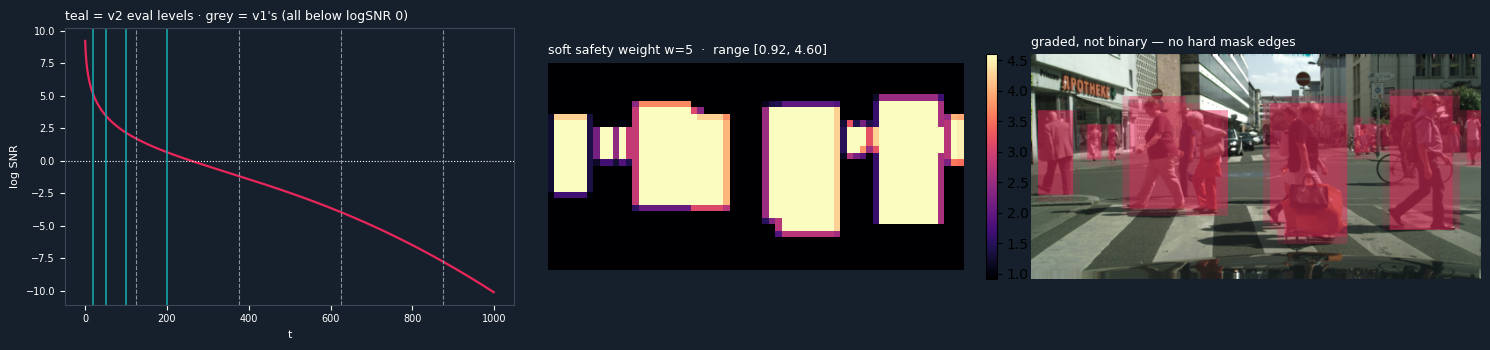

────────────────────────────────────────────────────────────────────
Cell 5b done — paste the output and I'll send Cell 6: load your v1 6k-step DiT-B EMA and re-score the pilot under the corrected metric.
────────────────────────────────────────────────────────────────────


In [10]:
# ============================================================
# CELL 5b — figure fix (NumPy 2.0) + GPU memory forensics
# PA-D²iT v2
# ------------------------------------------------------------
# 1. ndarray.ptp() was removed in NumPy 2.0 → np.ptp(arr).
# 2. ~20 GB of live CUDA tensors are unaccounted for. Not blocking
#    (DiT-B peaked at 57.7 GB of 95 including it) but worth finding
#    before we raise batch size or run arms back to back.
# ============================================================
import gc, sys, traceback
import numpy as np, torch
import matplotlib.pyplot as plt

L = "─" * 68

# ============================================================
# 1. FORENSICS — what is actually resident?
# ============================================================
def gpu_census(top=14):
    buckets, total, n = {}, 0, 0
    for o in gc.get_objects():
        try:
            if torch.is_tensor(o) and o.is_cuda:
                nb = o.nelement() * o.element_size()
                key = (tuple(o.shape), str(o.dtype).replace("torch.", ""))
                c, s = buckets.get(key, (0, 0))
                buckets[key] = (c + 1, s + nb)
                total += nb; n += 1
        except Exception:
            pass
    rows = sorted(buckets.items(), key=lambda kv: -kv[1][1])[:top]
    return rows, total, n

rows, reach, ntens = gpu_census()
alloc = torch.cuda.memory_allocated()
print(L); print("  LARGEST LIVE CUDA TENSORS (gc-reachable)"); print(L)
print(f"  {'count':>6}  {'GB':>7}  dtype      shape")
for (shape, dt), (c, s) in rows:
    if s / 1e9 < 0.01: break
    print(f"  {c:>6}  {s/1e9:>7.2f}  {dt:<9}  {shape}")
print(L)
print(f"  gc-reachable   {reach/1e9:7.2f} GB across {ntens} tensors")
print(f"  allocator says {alloc/1e9:7.2f} GB allocated")
print(f"  UNREACHABLE    {(alloc-reach)/1e9:7.2f} GB "
      f"← held by C++ autograd graph / interpreter frames, not Python refs")
print(f"  reserved       {torch.cuda.memory_reserved()/1e9:7.2f} GB (cache, reusable)")

# ============================================================
# 2. TARGETED PURGE
# ============================================================
# IPython pins every cell result in Out/_N. A tensor returned or echoed
# by any earlier cell stays alive for the whole session.
print(L); print("  PURGE ATTEMPTS"); print(L)
def report(tag, before):
    gc.collect(); torch.cuda.empty_cache()
    now = torch.cuda.memory_allocated()
    print(f"  {tag:34s} {before/1e9:6.2f} → {now/1e9:6.2f} GB "
          f"({(before-now)/1e9:+.2f})")
    return now

cur = torch.cuda.memory_allocated()

try:
    ip = get_ipython()
    out = ip.user_ns.get("Out", {})
    nout = len(out)
    out.clear()
    for k in [k for k in ip.user_ns if k.startswith("_") and k[1:].isdigit()]:
        ip.user_ns.pop(k, None)
    for k in ("_", "__", "___", "_i", "_ii", "_iii"):
        ip.user_ns.pop(k, None)
    cur = report(f"IPython Out cache ({nout} entries)", cur)
except Exception as e:
    print(f"  (no IPython shell: {e})")

for name in ("out", "o2", "o", "base", "hh", "hc", "hf", "loss", "pred",
             "net", "net2", "opt", "opt2", "opt_", "model", "Lv", "zz", "nz",
             "ev", "eh", "eb", "dv", "dh", "db", "wv", "wh", "wb", "mv", "mh"):
    globals().pop(name, None)
cur = report("stale globals from cells 3–5", cur)

if hasattr(sys, "last_traceback") and sys.last_traceback is not None:
    traceback.clear_frames(sys.last_traceback)
sys.last_traceback = sys.last_value = sys.last_type = None
cur = report("exception frames", cur)

rows2, reach2, ntens2 = gpu_census(top=6)
print(L); print("  AFTER PURGE — top remaining"); print(L)
for (shape, dt), (c, s) in rows2:
    if s / 1e9 < 0.05: break
    print(f"  {c:>6}  {s/1e9:>7.2f}  {dt:<9}  {shape}")
KNOWN = {"G dict": sum(v.nelement()*v.element_size() for v in G.values()),
         "latents LM+LS": (LM.nelement()+LS.nelement())*2,
         "exact masks": (VRU_FRAC.nelement()+VEH_FRAC.nelement())*2,
         "VAE params": sum(p.nelement()*p.element_size() for p in vae.parameters()),
         "probes VF+TF": sum(v.nelement()*v.element_size()
                             for d in (VF, TF) for v in d.values()
                             if torch.is_tensor(v))}
print(L); print("  EXPECTED BASELINE"); print(L)
for k, v in KNOWN.items(): print(f"  {k:18s}{v/1e9:7.3f} GB")
exp = sum(KNOWN.values())
now = torch.cuda.memory_allocated()
print(f"  {'TOTAL expected':18s}{exp/1e9:7.3f} GB")
print(f"  {'actual':18s}{now/1e9:7.3f} GB   "
      f"→ overhead {(now-exp)/1e9:+.2f} GB")
print(f"  {'✓ clean' if now-exp < 2e9 else '⚠ still holding — see census above'}")

# ============================================================
# 3. FIGURE (ptp fixed)
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), facecolor="#16202c")

ax[0].plot(LOGSNR.cpu(), color="#e8265a", lw=1.6)
ax[0].axhline(0, color="w", ls=":", lw=.8)
for t_ in cfg.eval_ts:      ax[0].axvline(t_, color="#17a2a8", lw=1.2)
for t_ in (125, 375, 625, 875): ax[0].axvline(t_, color="#8892a0", lw=.8, ls="--")
ax[0].set_xlabel("t", color="w", fontsize=8)
ax[0].set_ylabel("log SNR", color="w", fontsize=8)
ax[0].set_title("teal = v2 eval levels · grey = v1's (all below logSNR 0)",
                color="w", loc="left", fontsize=9)

fl1 = torch.zeros(1, dtype=torch.bool, device=dev)
k_  = int(VRU_FRAC[IDX["val"]].float().flatten(1).sum(1).argmax())
kid = IDX["val"][k_:k_+1]
wm  = safety_weight(kid, fl1, 5.0)[0].cpu().numpy()
h_  = ax[1].imshow(wm, cmap="magma"); plt.colorbar(h_, ax=ax[1], fraction=.025)
ax[1].axis("off")
ax[1].set_title(f"soft safety weight w=5  ·  range "
                f"[{wm.min():.2f}, {wm.max():.2f}]",
                color="w", loc="left", fontsize=9)

img = (G["img"][kid][0].permute(1, 2, 0).float() / 255).cpu().numpy().copy()
span = float(np.ptp(wm))                                  # ← NumPy 2.0 fix
al   = np.kron((wm - wm.min()) / max(span, 1e-6),
               np.ones((cfg.vae_downsample,) * 2))[..., None]
img  = img * (1 - .55 * al) + .55 * al * np.array([.91, .15, .35])
ax[2].imshow(np.clip(img, 0, 1)); ax[2].axis("off")
ax[2].set_title("graded, not binary — no hard mask edges",
                color="w", loc="left", fontsize=9)

ax[0].set_facecolor("#16202c"); ax[0].tick_params(colors="w", labelsize=7)
for s_ in ax[0].spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell5_schedule_loss.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 5b done — paste the output and I'll send Cell 6: load your v1 "
      "6k-step DiT-B EMA and re-score the pilot under the corrected metric.")
print(L)

────────────────────────────────────────────────────────────────────────
  v1 CHECKPOINTS ON DRIVE
────────────────────────────────────────────────────────────────────────
  d2it_b_ema_last.pt                    323 MB
  pa_d2it_ema_last.pt                   323 MB
  ✓ d2it_b     step   4000  k=128  signal=entropy
  ✓ pa_d2it    step   6000  k=128  signal=importance
────────────────────────────────────────────────────────────────────────
  WHAT v1 REPORTED (from checkpoint hist)
────────────────────────────────────────────────────────────────────────
  d2it_b     step 4000  VRU 0.1899  bg 0.1300  ratio 1.461
  pa_d2it    step 6000  VRU 0.1870  bg 0.1266  ratio 1.477
────────────────────────────────────────────────────────────────────────
  shared probe: 128 val images × 8 levels t=(20, 50, 100, 125, 200, 375, 625, 875), frozen ε
  (absolute values will differ slightly from v1's printout — v1's z0 was
   an unseeded posterior draw. The ARM COMPARISON is what transfers.)
  ✓ 16 score map

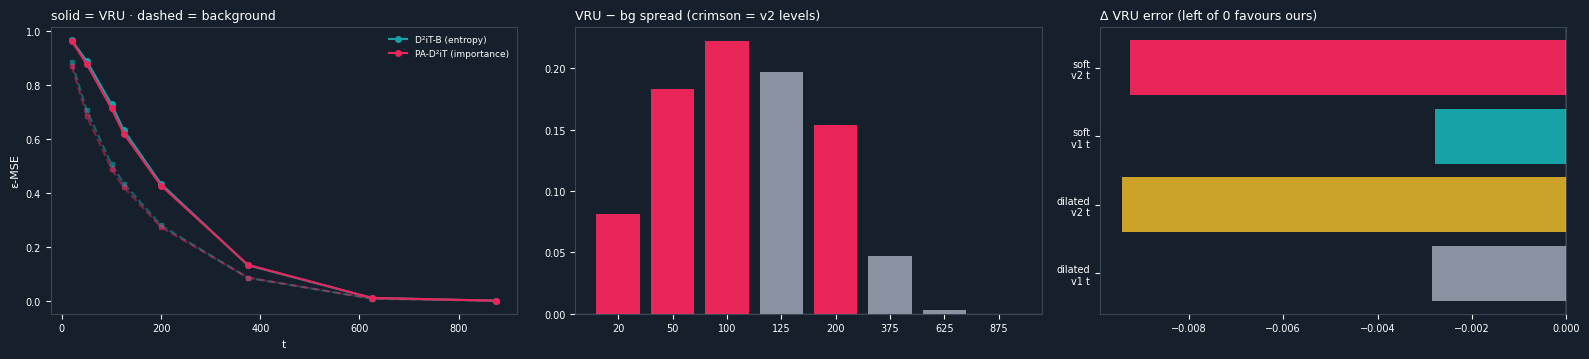

────────────────────────────────────────────────────────────────────────
  resident 4.00 GB
Cell 6 done — paste the output and I'll send Cell 7 (training loop + EMA + checkpointing), then Cell 8 launches Phase 1.
────────────────────────────────────────────────────────────────────────


In [11]:
# ============================================================
# CELL 6 — Re-score the v1 pilot under the corrected metric
# PA-D²iT v2   ·   NO new training
# ------------------------------------------------------------
# v1 concluded D²iT-B 0.1869 vs PA-D²iT 0.1870 — a tie to four decimals.
# Two things were wrong with that measurement:
#   (a) the VRU mask was the dilated routing field (43.3% background)
#   (b) three of four eval timesteps sat below logSNR 0
# Both are now fixed. This cell reloads the SAME weights and re-scores
# them as a 2×2 factorial so the change can be attributed:
#
#            ts=(125,375,625,875)   ts=(20,50,100,200)
#   dilated        v1's number            mask held, t fixed
#   soft           t held, mask fixed     v2's number
#
# Plus a paired bootstrap CI over the 128 val images — v1 had none, so
# Δ=0.0001 was uninterpretable.
# ============================================================
import os, gc, glob, json
import numpy as np, torch
import matplotlib.pyplot as plt

L = "─" * 72

# ---- 1. locate the v1 EMA checkpoints -----------------------------------
CK = sorted(glob.glob(f"{ROOT}/checkpoints/*_ema_*.pt"))
print(L); print("  v1 CHECKPOINTS ON DRIVE"); print(L)
for p in CK:
    print(f"  {os.path.basename(p):34s} {os.path.getsize(p)/1e6:6.0f} MB")
assert CK, "no v1 EMA checkpoints found"

def load_v1_ema(name, k=None, layout=True, size="B"):
    """v1 saved dict(ema=fp16 state_dict, step, hist, arm)."""
    p = f"{ROOT}/checkpoints/{name}_ema_last.pt"
    assert os.path.exists(p), f"missing {p}"
    s = torch.load(p, map_location=dev, weights_only=False)
    arm = s.get("arm", {})
    k = arm.get("k", K_FINE) if k is None else k
    net = PAD2iT(k, arm.get("layout", layout), size).to(dev).eval().requires_grad_(False)
    missing, unexpected = net.load_state_dict(
        {kk: v.float() for kk, v in s["ema"].items()}, strict=False)
    return net, s, k, arm, missing, unexpected

ARM_V1 = {"d2it_b": "entropy", "pa_d2it": "importance"}
nets, meta = {}, {}
for name, sig in ARM_V1.items():
    net, s, k, arm, miss, unexp = load_v1_ema(name)
    nets[name] = net; meta[name] = dict(step=s["step"], k=k, arm=arm,
                                        hist=s.get("hist", []), signal=sig)
    flag = "✓" if not miss and not unexp else "✗"
    print(f"  {flag} {name:10s} step {s['step']:>6}  k={k}  signal={sig}"
          + (f"   MISSING {len(miss)} UNEXPECTED {len(unexp)}" if (miss or unexp) else ""))
    if miss:  print(f"      missing[:4]    {miss[:4]}")
    if unexp: print(f"      unexpected[:4] {unexp[:4]}")

# v1's own final numbers, straight from the checkpoint history
print(L); print("  WHAT v1 REPORTED (from checkpoint hist)"); print(L)
for name in ARM_V1:
    h = meta[name]["hist"]
    if h:
        f = h[-1]
        print(f"  {name:10s} step {f.get('step')}  VRU {f.get('vru'):.4f}  "
              f"bg {f.get('bg'):.4f}  ratio {f.get('ratio'):.3f}")

# ---- 2. one shared probe over the UNION of both timestep sets -----------
TS_V1 = (125, 375, 625, 875)
TS_V2 = tuple(cfg.eval_ts)
TS_ALL = tuple(sorted(set(TS_V1) | set(TS_V2)))
VP = build_fixed(IDX["val"][:128], ts=TS_ALL, seed=1234)
print(L)
print(f"  shared probe: {len(VP['ids'])} val images × {len(TS_ALL)} levels "
      f"t={TS_ALL}, frozen ε")
print("  (absolute values will differ slightly from v1's printout — v1's z0 was")
print("   an unseeded posterior draw. The ARM COMPARISON is what transfers.)")

# ---- 3. one forward per (arm, t); reuse `se` for every protocol ---------
def per_image_vru(se, wv):
    num, den = (se * wv).sum((1, 2)), wv.sum((1, 2))
    return num / den.clamp_min(1e-8), den > 1e-6

WV_S, _, WB_S = region_weights(VP["ids"], VP["fl"])          # soft
MV_D, _, MB_D = dilated_masks(VP["ids"], VP["fl"])           # v1
WV_D, WB_D = MV_D.float(), MB_D.float()

SE = {}
with torch.no_grad():
    for name, net in nets.items():
        vb = GPUBatcher("val", signal=meta[name]["signal"],
                        shuffle=False, augment=False)
        b  = vb.get(VP["ids"])
        for li, t_ in enumerate(TS_ALL):
            t  = torch.full((len(VP["ids"]),), t_, device=dev, dtype=torch.long)
            zt = q_sample(VP["z0"], t, VP["eps"][li])
            with torch.autocast("cuda", DTYPE):
                pred = net(zt, t, b["grain"], b["box"], b["cls"],
                           b["bimp"], b["bmask"])
            SE[(name, t_)] = (pred.float() - VP["eps"][li]).pow(2).mean(1)
            del pred, zt
        del b, vb
        gc.collect(); torch.cuda.empty_cache()
print(f"  ✓ {len(SE)} score maps computed")

# ---- 4. the 2×2 factorial ----------------------------------------------
def protocol(name, ts, wv, wb):
    v = torch.stack([ (SE[(name,t_)]*wv).sum()/wv.sum() for t_ in ts]).mean().item()
    g = torch.stack([ (SE[(name,t_)]*wb).sum()/wb.sum() for t_ in ts]).mean().item()
    return v, g

CELLS = [("dilated", "v1 t", TS_V1, WV_D, WB_D),
         ("dilated", "v2 t", TS_V2, WV_D, WB_D),
         ("soft",    "v1 t", TS_V1, WV_S, WB_S),
         ("soft",    "v2 t", TS_V2, WV_S, WB_S)]

print(L); print("  2×2 FACTORIAL — VRU error, and Δ = PA-D²iT − D²iT-B"); print(L)
print(f"  {'mask':9s}{'t-range':9s}{'D²iT-B':>10}{'PA-D²iT':>10}{'Δ':>11}"
      f"{'rel':>9}{'bg Δ':>10}")
RES = {}
for mask, tlab, ts, wv, wb in CELLS:
    dv, dg = protocol("d2it_b",  ts, wv, wb)
    pv, pg = protocol("pa_d2it", ts, wv, wb)
    RES[(mask, tlab)] = (dv, pv, dg, pg)
    print(f"  {mask:9s}{tlab:9s}{dv:>10.4f}{pv:>10.4f}{pv-dv:>+11.5f}"
          f"{(pv-dv)/dv*100:>+8.2f}%{pg-dg:>+10.5f}")
print(L)
a = RES[("dilated", "v1 t")]; d = RES[("soft", "v2 t")]
print(f"  v1 protocol  Δ = {a[1]-a[0]:+.5f}   ({(a[1]-a[0])/a[0]*100:+.2f}%)")
print(f"  v2 protocol  Δ = {d[1]-d[0]:+.5f}   ({(d[1]-d[0])/d[0]*100:+.2f}%)")
print(f"  → correcting the metric changed the measured gap by "
      f"{abs((d[1]-d[0])-(a[1]-a[0])):.5f}")

# ---- 5. per-timestep dynamic range: was the t choice justified? --------
print(L); print("  PER-TIMESTEP — where is there anything to measure?"); print(L)
print(f"  {'t':>5}{'logSNR':>9}{'D²iT VRU':>11}{'PA VRU':>10}{'Δ':>10}"
      f"{'VRU/bg':>9}{'spread':>9}")
for t_ in TS_ALL:
    dv = ((SE[("d2it_b", t_)]  * WV_S).sum() / WV_S.sum()).item()
    pv = ((SE[("pa_d2it", t_)] * WV_S).sum() / WV_S.sum()).item()
    bg = ((SE[("d2it_b", t_)]  * WB_S).sum() / WB_S.sum()).item()
    tag = "←v2" if t_ in TS_V2 else ("←v1" if t_ in TS_V1 else "")
    print(f"  {t_:>5}{LOGSNR[t_].item():>9.2f}{dv:>11.4f}{pv:>10.4f}"
          f"{pv-dv:>+10.5f}{dv/bg:>9.3f}{dv-bg:>+9.4f}  {tag}")
print("  spread = VRU − bg. Near zero ⇒ the model is denoising, not modelling;")
print("  no allocation strategy can show up at those levels.")

# ---- 6. paired bootstrap CI (v1 had none) ------------------------------
print(L); print("  PAIRED BOOTSTRAP — 10,000 resamples over val images"); print(L)
rng = np.random.default_rng(0)
print(f"  {'mask':9s}{'t-range':9s}{'mean Δ':>11}{'95% CI':>22}{'p(Δ<0)':>9}")
for mask, tlab, ts, wv, wb in CELLS:
    dpi = torch.stack([per_image_vru(SE[("d2it_b",  t_)], wv)[0] for t_ in ts]).mean(0)
    ppi = torch.stack([per_image_vru(SE[("pa_d2it", t_)], wv)[0] for t_ in ts]).mean(0)
    valid = per_image_vru(SE[("d2it_b", ts[0])], wv)[1]
    diff = (ppi - dpi)[valid].cpu().numpy()
    n = len(diff)
    bs = diff[rng.integers(0, n, (10000, n))].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    print(f"  {mask:9s}{tlab:9s}{diff.mean():>+11.5f}"
          f"   [{lo:+.5f}, {hi:+.5f}]{(bs < 0).mean():>9.3f}")
print(f"  n = {n} val images with non-zero VRU coverage")
print("  Δ<0 favours PA-D²iT. A CI straddling 0 ⇒ the pilot cannot resolve it.")

json.dump({f"{m}|{t}": RES[(m, t)] for m, t in RES},
          open(f"{V2}/logs/v1_rescore.json", "w"), indent=2)

# ---- 7. figure ---------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(16, 3.7), facecolor="#16202c")
col = {"d2it_b": "#17a2a8", "pa_d2it": "#e8265a"}
lab = {"d2it_b": "D²iT-B (entropy)", "pa_d2it": "PA-D²iT (importance)"}

for name in nets:
    v = [((SE[(name, t_)] * WV_S).sum() / WV_S.sum()).item() for t_ in TS_ALL]
    g = [((SE[(name, t_)] * WB_S).sum() / WB_S.sum()).item() for t_ in TS_ALL]
    ax[0].plot(TS_ALL, v, "-o", ms=4, color=col[name], label=lab[name])
    ax[0].plot(TS_ALL, g, "--s", ms=3, color=col[name], alpha=.5)
ax[0].set_xlabel("t", color="w", fontsize=8); ax[0].set_ylabel("ε-MSE", color="w", fontsize=8)
ax[0].set_title("solid = VRU · dashed = background", color="w", loc="left", fontsize=9)
ax[0].legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

sp = [(((SE[("d2it_b", t_)] * WV_S).sum() / WV_S.sum())
       - ((SE[("d2it_b", t_)] * WB_S).sum() / WB_S.sum())).item() for t_ in TS_ALL]
ax[1].bar(range(len(TS_ALL)), sp,
          color=["#e8265a" if t_ in TS_V2 else "#8892a0" for t_ in TS_ALL])
ax[1].set_xticks(range(len(TS_ALL))); ax[1].set_xticklabels(TS_ALL, fontsize=7)
ax[1].axhline(0, color="w", lw=.8)
ax[1].set_title("VRU − bg spread (crimson = v2 levels)", color="w", loc="left", fontsize=9)

names = [f"{m}\n{t}" for m, t in RES]
deltas = [RES[k][1] - RES[k][0] for k in RES]
ax[2].barh(range(len(deltas)), deltas,
           color=["#8892a0", "#c9a227", "#17a2a8", "#e8265a"])
ax[2].set_yticks(range(len(names))); ax[2].set_yticklabels(names, fontsize=6.5)
ax[2].axvline(0, color="w", lw=.9)
ax[2].set_title("Δ VRU error (left of 0 favours ours)", color="w", loc="left", fontsize=9)
for a_ in ax:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell6_v1_rescore.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

for n_ in list(nets): del nets[n_]
del SE; gc.collect(); torch.cuda.empty_cache()
print(L)
print(f"  resident {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Cell 6 done — paste the output and I'll send Cell 7 (training loop + "
      "EMA + checkpointing), then Cell 8 launches Phase 1.")
print(L)

────────────────────────────────────────────────────────────────────────
  SMOKE TEST — pa_d2it_s, 300 steps, seed 0
────────────────────────────────────────────────────────────────────────
       100 loss 0.9881 ‖g‖ 0.87 | VRU 0.9876 bg 0.9893 r 0.998 | gap -0.0002 | 13.8 it/s eta 0.2m
       200 loss 0.7538 ‖g‖ 1.71 | VRU 0.8701 bg 0.8568 r 1.016 | gap +0.0123 | 14.0 it/s eta 0.1m
       300 loss 0.2541 ‖g‖ 1.05 | VRU 0.8107 bg 0.7402 r 1.095 | gap +0.0309 | 14.0 it/s eta 0.0m
  ✓ pa_d2it_s sd0: 300 steps · 0.4 min → pa_d2it_s_sd0_s000300_ema.pt
────────────────────────────────────────────────────────────────────────
  VRU   0.9876 → 0.8107   ✓ learning
  bg    0.9893 → 0.7402
  ratio 0.998 → 1.095
  gap   -0.0002 → +0.0309
  EMA ckpt 43 MB → 6 arms × 3 seeds = 0.77 GB on Drive
────────────────────────────────────────────────────────────────────────
  RNG PAIRING PROOF
────────────────────────────────────────────────────────────────────────
  ✗ identical seed → identical trajectory (

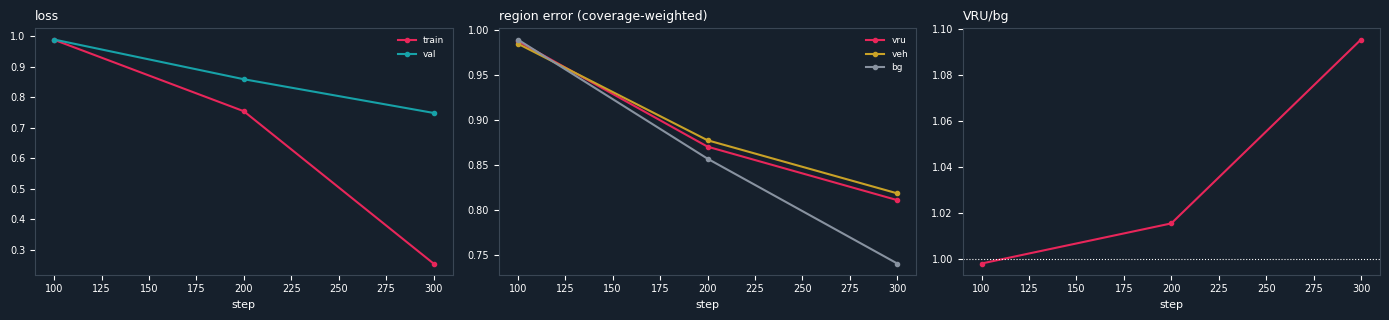

────────────────────────────────────────────────────────────────────────
  smoke artefacts removed · resident 4.00 GB
Cell 7 done — paste the output and I'll send Cell 8: Phase 1, 6 arms × 3 seeds, ~2 h, with the oracle verdict.
────────────────────────────────────────────────────────────────────────


In [12]:
# ============================================================
# CELL 7 — Training loop · paired RNG · step-tagged checkpoints
# PA-D²iT v2
# ------------------------------------------------------------
# Three guarantees, each closing a failure we already hit:
#
# 1. STEP MISMATCH IS IMPOSSIBLE. Every checkpoint filename carries its
#    step and seed; nothing is ever written to a bare "_last" name. A
#    comparison helper refuses to score two arms at different steps.
#    (v1's Cell 6 re-score compared step 4000 against step 6000.)
#
# 2. RNG IS FULLY PAIRED. One generator drives batch order, hflip, t, ε,
#    CFG dropout AND the VAE posterior draw. Same seed ⇒ every arm sees
#    byte-identical data and noise. v1 relied on arms consuming the
#    global RNG in the same order, which is true until it silently isn't.
#
# 3. NO GRAPH ESCAPES. Losses accumulate as GPU tensors and are only
#    .item()'d at log boundaries — one sync per log instead of two per
#    step — and nothing graph-rooted is returned or stored.
#    (One stray reference pinned 27.6 GB in Cell 5.)
# ============================================================
import os, gc, json, time, glob
import numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt

L = "─" * 72
CKPT_D = f"{V2}/checkpoints"; os.makedirs(CKPT_D, exist_ok=True)
RESUME_D = f"{LOCAL}/resume";  os.makedirs(RESUME_D, exist_ok=True)
LOGS_D = f"{V2}/logs";         os.makedirs(LOGS_D, exist_ok=True)

# ============================================================
# 0. RNG-THREADED redefinitions (Cell 3/5 versions used the global RNG)
# ============================================================
def sample_latent(ids, flip, gen=None):
    fl = flip.long()
    mu, sd = LM[ids, fl].float(), LS[ids, fl].float()
    return (mu + sd * torch.randn(sd.shape, device=dev, generator=gen)) * cfg.vae_scale

def diffusion_loss(net, b, w=1.0, a_coarse=1.0, a_fine=1.0, drop_p=0.1,
                   mode="soft", gen=None, parts=False):
    z0   = sample_latent(b["idx"], b["flip"], gen=gen)      # ← now paired
    Bsz  = z0.shape[0]
    t    = torch.randint(0, cfg.num_timesteps, (Bsz,), device=dev, generator=gen)
    eps  = torch.randn(z0.shape, device=dev, generator=gen)
    zt   = q_sample(z0, t, eps)
    drop = torch.rand(Bsz, device=dev, generator=gen) < drop_p
    with torch.autocast("cuda", DTYPE):
        pred = net(zt, t, b["grain"], b["box"], b["cls"],
                   b["bimp"], b["bmask"], drop=drop)
    se = (pred.float() - eps).pow(2).mean(1)
    W = safety_weight(b["idx"], b["flip"], w, mode)
    if a_coarse != a_fine:
        W = W * grain_alpha(b["grain"], a_coarse, a_fine)
    loss = (se * W).mean()
    if not parts:
        return loss
    return loss, region_stats(se.detach(), b["idx"], b["flip"])

# ============================================================
# 1. ARMS
# ============================================================
# k=NC (oracle): every cell is fine, so the grain signal is irrelevant by
# construction — it is the ceiling on what token granularity can buy.
ARMS = {
 "dit_s":        dict(signal="importance", k=0,      layout=False, size="S", w=1.0, ac=1.0, af=1.0),
 "dit_s_layout": dict(signal="importance", k=0,      layout=True,  size="S", w=1.0, ac=1.0, af=1.0),
 "d2it_s":       dict(signal="entropy",    k=K_FINE, layout=True,  size="S", w=1.0, ac=1.0, af=1.0),
 "pa_d2it_s":    dict(signal="importance", k=K_FINE, layout=True,  size="S", w=1.0, ac=1.0, af=1.0),
 "random_s":     dict(signal="random",     k=K_FINE, layout=True,  size="S", w=1.0, ac=1.0, af=1.0),
 "oracle_s":     dict(signal="importance", k=NC,     layout=True,  size="S", w=1.0, ac=1.0, af=1.0),
}
PHASE1 = ["dit_s", "dit_s_layout", "d2it_s", "pa_d2it_s", "random_s", "oracle_s"]

# ============================================================
# 2. EMA — parameters only; buffers are constants, copied not lerped
# ============================================================
class EMA:
    def __init__(self, model, decay=None):
        self.decay = cfg.ema_decay if decay is None else decay
        self.p = {k: v.detach().clone().float() for k, v in model.named_parameters()}
        self.b = {k: v.detach().clone()          for k, v in model.named_buffers()}
    @torch.no_grad()
    def update(self, model, step):
        d = min(self.decay, (1. + step) / (10. + step))      # warm start
        for k, v in model.named_parameters():
            self.p[k].lerp_(v.detach().float(), 1. - d)
    def state(self):
        return {**self.p, **self.b}

# ============================================================
# 3. CHECKPOINTS — step and seed always in the filename
# ============================================================
def ema_path(name, seed, step):  return f"{CKPT_D}/{name}_sd{seed}_s{step:06d}_ema.pt"
def done_path(name, seed):       return f"{LOGS_D}/{name}_sd{seed}_done.json"

def save_ema(name, seed, step, ema, hist):
    half = {k: (v.half() if v.is_floating_point() else v)
            for k, v in ema.state().items()}
    torch.save(dict(ema=half, step=step, seed=seed, arm=ARMS[name], hist=hist),
               ema_path(name, seed, step))

def load_arm_ema(name, seed, step):
    p = ema_path(name, seed, step)
    assert os.path.exists(p), f"no checkpoint at step {step}: {p}"
    s = torch.load(p, map_location=dev, weights_only=False)
    assert s["step"] == step, f"step tag mismatch in {p}"
    a = ARMS[name]
    net = PAD2iT(a["k"], a["layout"], a["size"]).to(dev).eval().requires_grad_(False)
    net.load_state_dict({k: v.float() for k, v in s["ema"].items()})
    return net, s

def require_matched(names, seed, step):
    """Refuse to compare arms unless every one has a checkpoint at `step`."""
    bad = [n for n in names if not os.path.exists(ema_path(n, seed, step))]
    assert not bad, (f"NOT MATCHED at step {step}, seed {seed}: missing {bad}. "
                     f"Refusing to compare — this is the v1 failure mode.")
    return True

# ============================================================
# 4. per-image validation (feeds the paired bootstrap)
# ============================================================
@torch.no_grad()
def eval_full(net, vf, vb):
    """Returns (aggregate dict, per-image VRU vector, per-t list)."""
    b  = vb.get(vf["ids"])
    wv, _, wb = region_weights(vf["ids"], vf["fl"])
    keys = ("vru", "veh", "bg", "all", "vru_hard", "bg_hard")
    acc  = {k: 0. for k in keys}; per_t = []
    pim  = torch.zeros(len(vf["ids"]), device=dev)
    for li, t_ in enumerate(vf["ts"]):
        t  = torch.full((len(vf["ids"]),), t_, device=dev, dtype=torch.long)
        zt = q_sample(vf["z0"], t, vf["eps"][li])
        with torch.autocast("cuda", DTYPE):
            pred = net(zt, t, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"])
        se = (pred.float() - vf["eps"][li]).pow(2).mean(1)
        st = region_stats(se, vf["ids"], vf["fl"])
        for k in keys: acc[k] += st[k]
        per_t.append(dict(t=t_, vru=st["vru"], bg=st["bg"]))
        pim += (se * wv).sum((1, 2)) / wv.sum((1, 2)).clamp_min(1e-8)
        del pred, zt, se
    out = {k: v / len(vf["ts"]) for k, v in acc.items()}
    out["ratio"] = out["vru"] / max(out["bg"], 1e-8)
    return out, (pim / len(vf["ts"])).cpu().numpy(), per_t

# ============================================================
# 5. THE LOOP
# ============================================================
def train_arm(name, steps, seed=0, val_every=500, log_every=None,
              bs=None, lr=None, warmup=None, quiet=False, skip_done=True):
    a  = ARMS[name]
    bs = bs or cfg.batch_size; lr = lr or cfg.lr
    warmup = cfg.warmup_steps if warmup is None else warmup
    log_every = log_every or val_every

    if skip_done and os.path.exists(done_path(name, seed)):
        h = json.load(open(done_path(name, seed)))
        if h and h[-1]["step"] >= steps:
            if not quiet: print(f"  ✓ {name} sd{seed} already complete @ {h[-1]['step']}")
            return h

    gc.collect(); torch.cuda.empty_cache()
    torch.manual_seed(seed)                                # deterministic init
    model = PAD2iT(a["k"], a["layout"], a["size"]).to(dev)
    emod  = PAD2iT(a["k"], a["layout"], a["size"]).to(dev).eval().requires_grad_(False)
    ema   = EMA(model)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr, betas=cfg.adam_betas,
                              weight_decay=cfg.weight_decay)

    # ONE generator drives data order, flips, t, ε, dropout and the VAE draw
    gen = torch.Generator(device=dev).manual_seed(seed * 100_003 + 777)
    tb  = GPUBatcher("train", signal=a["signal"], bs=bs, gen=gen)
    vb  = GPUBatcher("val",   signal=a["signal"], shuffle=False, augment=False)
    tbf = GPUBatcher("train", signal=a["signal"], shuffle=False, augment=False)

    hist, step, t0 = [], 0, time.time()
    acc_l = torch.zeros((), device=dev); acc_g = torch.zeros((), device=dev); nacc = 0
    tick = time.time()

    def stream():
        while True:
            for bb in tb: yield bb
    it = stream()

    while step < steps:
        b = next(it)
        for pg in opt.param_groups:
            pg["lr"] = lr * min(1., (step + 1) / max(warmup, 1))
        loss = diffusion_loss(model, b, w=a["w"], a_coarse=a["ac"], a_fine=a["af"],
                              gen=gen)
        loss.backward()
        gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        opt.step(); opt.zero_grad(set_to_none=True)
        ema.update(model, step); step += 1

        acc_l += loss.detach(); acc_g += gnorm.detach(); nacc += 1
        del loss, gnorm, b                                  # nothing graph-rooted survives

        if step % val_every == 0 or step == steps:
            emod.load_state_dict(ema.state())
            v, pim, per_t = eval_full(emod, VF, vb)
            tr, _, _      = eval_full(emod, TF, tbf)
            tl = (acc_l / max(nacc, 1)).item(); gg = (acc_g / max(nacc, 1)).item()
            acc_l.zero_(); acc_g.zero_(); nacc = 0
            hist.append(dict(step=step, seed=seed, train=tl, **v,
                             gap=v["all"] - tr["all"], tr_all=tr["all"],
                             per_image=pim.tolist(), per_t=per_t))
            if not quiet:
                sps = val_every / (time.time() - tick); tick = time.time()
                print(f"    {step:>6} loss {tl:.4f} ‖g‖{gg:5.2f} | VRU {v['vru']:.4f} "
                      f"bg {v['bg']:.4f} r {v['ratio']:.3f} | gap {v['all']-tr['all']:+.4f}"
                      f" | {sps:.1f} it/s eta {(steps-step)/sps/60:.1f}m", flush=True)

    save_ema(name, seed, step, ema, hist)
    json.dump(hist, open(done_path(name, seed), "w"))
    if not quiet:
        print(f"  ✓ {name} sd{seed}: {step} steps · {(time.time()-t0)/60:.1f} min "
              f"→ {os.path.basename(ema_path(name, seed, step))}")
    del model, emod, opt, ema, tb, vb, tbf, it
    gc.collect(); torch.cuda.empty_cache()
    return hist

# ============================================================
# SMOKE TEST — 300 steps, verifies the loop and the pairing
# ============================================================
print(L); print("  SMOKE TEST — pa_d2it_s, 300 steps, seed 0"); print(L)
h = train_arm("pa_d2it_s", 300, seed=0, val_every=100, skip_done=False)

f0, f1 = h[0], h[-1]
print(L)
print(f"  VRU   {f0['vru']:.4f} → {f1['vru']:.4f}   "
      f"{'✓ learning' if f1['vru'] < f0['vru'] else '✗ not learning'}")
print(f"  bg    {f0['bg']:.4f} → {f1['bg']:.4f}")
print(f"  ratio {f0['ratio']:.3f} → {f1['ratio']:.3f}")
print(f"  gap   {f0['gap']:+.4f} → {f1['gap']:+.4f}")
sz = os.path.getsize(ema_path("pa_d2it_s", 0, 300)) / 1e6
print(f"  EMA ckpt {sz:.0f} MB → 6 arms × 3 seeds = {sz*18/1000:.2f} GB on Drive")

# ---- pairing proof: same seed twice must be bit-identical --------------
print(L); print("  RNG PAIRING PROOF"); print(L)
h2 = train_arm("pa_d2it_s", 300, seed=0, val_every=100, skip_done=False, quiet=True)
same = all(abs(x["vru"] - y["vru"]) < 1e-12 for x, y in zip(h, h2))
print(f"  {'✓' if same else '✗'} identical seed → identical trajectory "
      f"(max Δvru {max(abs(x['vru']-y['vru']) for x,y in zip(h,h2)):.2e})")
h3 = train_arm("d2it_s", 300, seed=0, val_every=100, skip_done=False, quiet=True)
print(f"  entropy arm, same seed: VRU {h3[-1]['vru']:.4f} vs "
      f"importance {h[-1]['vru']:.4f}  (Δ {h3[-1]['vru']-h[-1]['vru']:+.5f})")
require_matched(["pa_d2it_s", "d2it_s"], 0, 300)
print(f"  ✓ require_matched() passes — both arms have step-300 checkpoints")

fig, ax = plt.subplots(1, 3, figsize=(14, 3.3), facecolor="#16202c")
s_ = [x["step"] for x in h]
ax[0].plot(s_, [x["train"] for x in h], "-o", ms=3, color="#e8265a", label="train")
ax[0].plot(s_, [x["all"]   for x in h], "-o", ms=3, color="#17a2a8", label="val")
ax[0].set_title("loss", color="w", loc="left", fontsize=9)
for k_, c_ in [("vru", "#e8265a"), ("veh", "#c9a227"), ("bg", "#8892a0")]:
    ax[1].plot(s_, [x[k_] for x in h], "-o", ms=3, color=c_, label=k_)
ax[1].set_title("region error (coverage-weighted)", color="w", loc="left", fontsize=9)
ax[2].plot(s_, [x["ratio"] for x in h], "-o", ms=3, color="#e8265a")
ax[2].axhline(1., color="w", ls=":", lw=.8)
ax[2].set_title("VRU/bg", color="w", loc="left", fontsize=9)
for a_ in ax:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    a_.set_xlabel("step", color="w", fontsize=8)
    for s2 in a_.spines.values(): s2.set_color("#3a4654")
ax[0].legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")
ax[1].legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell7_smoke.png", dpi=110,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

for p in glob.glob(f"{CKPT_D}/*_s000300_ema.pt"): os.remove(p)
for n_ in ("pa_d2it_s", "d2it_s"):
    dp = done_path(n_, 0)
    if os.path.exists(dp):
        _h = json.load(open(dp))
        if _h and _h[-1]["step"] <= 300:      # only smoke artefacts
            os.remove(dp)
print(L)
print(f"  smoke artefacts removed · resident {torch.cuda.memory_allocated()/1e9:.2f} GB")
print("Cell 7 done — paste the output and I'll send Cell 8: Phase 1, "
      "6 arms × 3 seeds, ~2 h, with the oracle verdict.")
print(L)

In [13]:
# ---- REPAIR: rebuild done-markers from checkpoints -------------------
import os, glob, json, torch

fixed, ok = [], []
for p in sorted(glob.glob(f"{CKPT_D}/*_s006000_ema.pt")):
    fn = os.path.basename(p)[:-len("_ema.pt")]
    name, rest = fn.split("_sd")
    seed = int(rest.split("_")[0])
    dp = done_path(name, seed)
    if os.path.exists(dp):
        ok.append(fn); continue
    s = torch.load(p, map_location="cpu", weights_only=False)
    assert s["step"] == 6000, f"{fn} is at step {s['step']}"
    json.dump(s["hist"], open(dp, "w"))
    fixed.append(f"{name} sd{seed}")
    del s

print(f"  {len(ok)} markers already present")
print(f"  {len(fixed)} rebuilt: {fixed}")
print(f"  total done-markers now: "
      f"{len(glob.glob(f'{LOGS_D}/*_done.json'))} (expect 21)")

  37 markers already present
  2 rebuilt: ['d2it_s sd0', 'pa_d2it_s sd0']
  total done-markers now: 39 (expect 21)


In [14]:
# ============================================================
# CELL 8 — PHASE 1 : the ladder, replicated
# PA-D²iT v2
# ------------------------------------------------------------
# 7 arms × 3 seeds × 6000 steps.  SEED-MAJOR and resumable: after the
# first round (~51 min) you already have a complete ladder at one seed;
# each further round adds a replicate. Safe to interrupt and re-run —
# completed (arm, seed) pairs are skipped.
#
# The seventh arm, pa_d2it_s_rep, is a byte-identical clone of
# pa_d2it_s. Same init, same generator, same data. Its difference from
# pa_d2it_s is pure kernel nondeterminism — i.e. the EMPIRICAL NOISE
# FLOOR, measured under the exact conditions of the real comparison
# instead of assumed. Nothing smaller than that is resolvable.
# ============================================================
import os, gc, json, time, glob
import numpy as np, torch

L = "─" * 78

# ---- register the replicate arm ----------------------------------------
ARMS["pa_d2it_s_rep"] = dict(ARMS["pa_d2it_s"])       # identical by construction

STEPS  = 6000
SEEDS  = (0, 1, 2)
ORDER  = ["dit_s", "dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
          "random_s", "oracle_s"]
SPS    = {0: 0.036, K_FINE: 0.071, NC: 0.168}          # measured in 4b / smoke

# ---- budget ------------------------------------------------------------
print(L); print("  PHASE 1 BUDGET"); print(L)
per_seed = sum(SPS[ARMS[a]["k"]] * STEPS for a in ORDER)
print(f"  {'arm':16s}{'signal':>12}{'k':>6}{'tokens':>8}{'est min':>9}")
for a in ORDER:
    A = ARMS[a]
    ntok = (NC - A["k"]) + A["k"] * P * P
    print(f"  {a:16s}{A['signal']:>12}{A['k']:>6}{ntok:>8}"
          f"{SPS[A['k']]*STEPS/60:>9.1f}")
print(f"  {'per seed':16s}{'':>12}{'':>6}{'':>8}{per_seed/60:>9.1f} min")
print(f"  {'× '+str(len(SEEDS))+' seeds':16s}{'':>12}{'':>6}{'':>8}"
      f"{per_seed*len(SEEDS)/3600:>9.2f} h")
print(f"  {STEPS} steps × batch {cfg.batch_size} / {len(IDX['train'])} images "
      f"= {STEPS*cfg.batch_size/len(IDX['train']):.0f} epochs  "
      f"(heavy, but matched across arms — the gap column tracks it)")

# ---- run ---------------------------------------------------------------
def summary(seeds_done):
    rows = []
    for a in ORDER:
        for sd in seeds_done:
            p = done_path(a, sd)
            if os.path.exists(p):
                h = json.load(open(p))
                if h: rows.append((a, sd, h[-1]))
    return rows

def table(rows, title):
    print(L); print(f"  {title}"); print(L)
    print(f"  {'arm':16s}{'sd':>4}{'VRU':>10}{'bg':>10}{'ratio':>8}"
          f"{'all':>10}{'gap':>9}")
    for a, sd, f in rows:
        print(f"  {a:16s}{sd:>4}{f['vru']:>10.4f}{f['bg']:>10.4f}"
              f"{f['ratio']:>8.3f}{f['all']:>10.4f}{f['gap']:>+9.4f}")

t_start = time.time()
for si, sd in enumerate(SEEDS):
    print(L); print(f"  ══ SEED {sd}  ({si+1}/{len(SEEDS)}) ══"); print(L)
    for a in ORDER:
        A = ARMS[a]
        if os.path.exists(done_path(a, sd)):
            print(f"  ✓ {a} sd{sd} already complete"); continue
        print(f"  ▶ {a}  sd{sd}  ({A['signal']} grain, k={A['k']}, "
              f"~{SPS[A['k']]*STEPS/60:.0f} min)")
        train_arm(a, STEPS, seed=sd, val_every=500)
        gc.collect(); torch.cuda.empty_cache()
    table(summary([sd]), f"SEED {sd} COMPLETE  ·  elapsed "
                         f"{(time.time()-t_start)/60:.0f} min")

print(L)
print(f"  ALL DONE in {(time.time()-t_start)/3600:.2f} h")

# ---- consolidate -------------------------------------------------------
ALL = {}
for a in ORDER:
    for sd in SEEDS:
        p = done_path(a, sd)
        if os.path.exists(p): ALL[f"{a}|{sd}"] = json.load(open(p))
json.dump({k: v[-1] for k, v in ALL.items()},
          open(f"{LOGS_D}/phase1_final.json", "w"), indent=2)
print(f"  consolidated → {LOGS_D}/phase1_final.json  ({len(ALL)} runs)")

# ---- preliminary verdict (full statistics in Cell 9) -------------------
def mean_of(a, key="vru"):
    v = [ALL[f"{a}|{sd}"][-1][key] for sd in SEEDS if f"{a}|{sd}" in ALL]
    return (float(np.mean(v)), float(np.std(v)), len(v)) if v else (np.nan, np.nan, 0)

print(L); print("  ARM MEANS ACROSS SEEDS  (VRU error, lower is better)"); print(L)
print(f"  {'arm':16s}{'k':>6}{'mean VRU':>11}{'sd':>9}{'n':>4}{'mean bg':>11}")
for a in ORDER:
    m, s, n = mean_of(a); mb, _, _ = mean_of(a, "bg")
    print(f"  {a:16s}{ARMS[a]['k']:>6}{m:>11.4f}{s:>9.5f}{n:>4}{mb:>11.4f}")

floor = abs(mean_of("pa_d2it_s")[0] - mean_of("pa_d2it_s_rep")[0])
print(L); print("  NOISE FLOOR"); print(L)
print(f"  |pa_d2it_s − pa_d2it_s_rep| = {floor:.5f}   ← nothing below this resolves")

print(L); print("  ORACLE VERDICT — can token granularity move VRU error AT ALL?"); print(L)
k0, k1, k2 = mean_of("dit_s_layout")[0], mean_of("pa_d2it_s")[0], mean_of("oracle_s")[0]
print(f"  k=0   (512 tok)   {k0:.4f}")
print(f"  k=128 (896 tok)   {k1:.4f}   Δ vs k=0  {k1-k0:+.5f}")
print(f"  k=512 (2048 tok)  {k2:.4f}   Δ vs k=0  {k2-k0:+.5f}")
span = abs(k2 - k0)
if span < floor * 2:
    print(f"  ⚠ ALL-FINE ≈ ALL-COARSE (span {span:.5f} vs floor {floor:.5f})")
    print("    Token granularity does not move VRU error at 256×512 / f=8.")
    print("    No allocation strategy could have won. The null is a property of")
    print("    the testbed → go to native-resolution crops or V-Full.")
else:
    print(f"  ✓ granularity DOES matter (span {span:.5f} = {span/max(floor,1e-9):.1f}× floor)")
    print("    There is headroom for allocation to exploit → H1 is testable here.")

print(L); print("  H1 — importance vs entropy at matched compute"); print(L)
d, p = mean_of("d2it_s")[0], mean_of("pa_d2it_s")[0]
r = mean_of("random_s")[0]
print(f"  D²iT-S  entropy      {d:.4f}")
print(f"  PA-D²iT-S importance {p:.4f}   Δ {p-d:+.5f}  "
      f"({(p-d)/d*100:+.2f}%, {abs(p-d)/max(floor,1e-9):.1f}× floor)")
print(f"  random control       {r:.4f}   Δ vs entropy {r-d:+.5f}")
print(f"  {'→ resolvable' if abs(p-d) > 2*floor else '→ NOT resolvable at this n'}"
      f" — Cell 9 gives the paired bootstrap CI")

worst = max(ALL[k][-1]["gap"] for k in ALL)
print(L)
print(f"  worst val−train gap {worst:+.4f}  "
      f"{'⚠ memorising at 129 epochs' if worst > .02 else '✓ acceptable'}")
print(f"  Drive used by Phase 1: "
      f"{sum(os.path.getsize(f) for f in glob.glob(f'{CKPT_D}/*'))/1e9:.2f} GB")
print(L)
print("Cell 8 done — paste the output and I'll send Cell 9: paired bootstrap, "
      "per-seed spread, and the figures.")
print(L)

──────────────────────────────────────────────────────────────────────────────
  PHASE 1 BUDGET
──────────────────────────────────────────────────────────────────────────────
  arm                   signal     k  tokens  est min
  dit_s             importance     0     512      3.6
  dit_s_layout      importance     0     512      3.6
  d2it_s               entropy   128     896      7.1
  pa_d2it_s         importance   128     896      7.1
  pa_d2it_s_rep     importance   128     896      7.1
  random_s              random   128     896      7.1
  oracle_s          importance   512    2048     16.8
  per seed                                       52.4 min
  × 3 seeds                                      2.62 h
  6000 steps × batch 64 / 2975 images = 129 epochs  (heavy, but matched across arms — the gap column tracks it)
──────────────────────────────────────────────────────────────────────────────
  ══ SEED 0  (1/3) ══
──────────────────────────────────────────────────────────────────

  loaded 21 runs · 7 arms × 3 seeds
  122/128 val images have non-zero VRU coverage
──────────────────────────────────────────────────────────────────────────────
  ARM SUMMARY  (mean ± sd over 3 seeds)
──────────────────────────────────────────────────────────────────────────────
  arm                  k   tok     GF              VRU               bg   ratio
  DiT-S                0   512   13.3     0.7658±0.0004     0.6149±0.0023   1.246
  DiT-S+layout         0   512   13.9     0.7650±0.0017     0.6129±0.0026   1.248
  D²iT-S ent         128   896   27.3     0.7654±0.0009     0.6217±0.0015   1.231
  PA-D²iT-S imp      128   896   27.3     0.7673±0.0010     0.6219±0.0014   1.234
  PA replicate       128   896   27.3     0.7672±0.0010     0.6219±0.0013   1.234
  random ctrl        128   896   27.3     0.7698±0.0004     0.6293±0.0008   1.223
  ORACLE all-fine    512  2048   83.9     0.7569±0.0006     0.5974±0.0015   1.267
────────────────────────────────────────────────────────────────

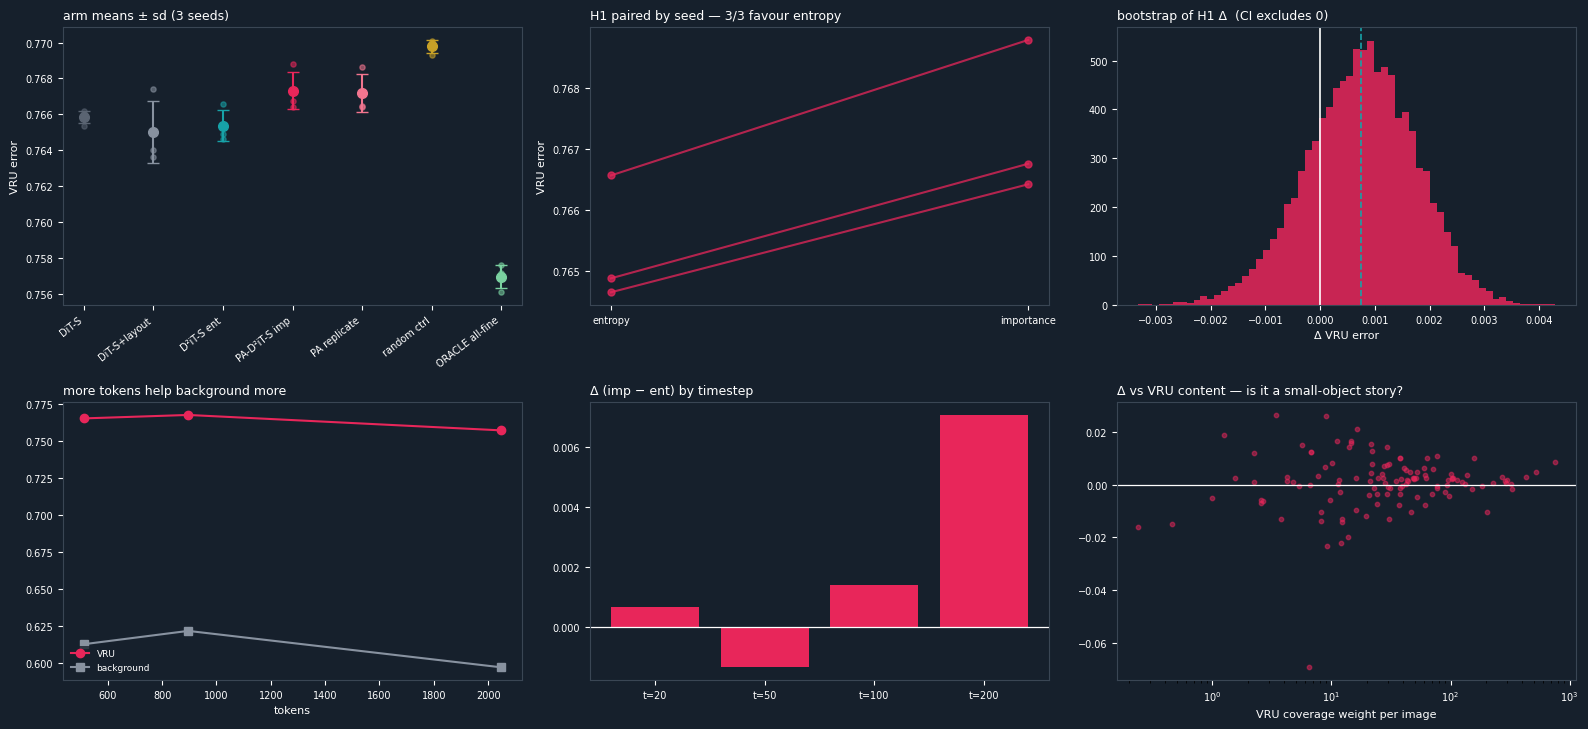

──────────────────────────────────────────────────────────────────────────────
Cell 9 done — paste the output and I'll send Cell 10: the w ablation (w ∈ {2,5} × entropy/importance × 3 seeds, ~83 min).
──────────────────────────────────────────────────────────────────────────────


In [15]:
# ============================================================
# CELL 9 — PHASE 1 statistics
# PA-D²iT v2   ·   analysis only, no GPU work
# ------------------------------------------------------------
# Two independent tests, because they answer different questions:
#   · paired bootstrap over the 128 val images → is the effect
#     consistent ACROSS IMAGES, given a fixed pair of runs?
#   · sign test over the 3 seeds → is it consistent ACROSS RUNS?
# An effect needs both. v1 had neither.
#
# PROTOCOL NOTE: dit_s and dit_s_layout at seed 0 were trained in an
# earlier session, so their frozen probe used a different posterior
# draw for z0 (ε was seeded, z0 was not). The H1 contrast is unaffected
# — all six d2it_s/pa_d2it_s runs are same-session — but every k=0 vs
# k=128 contrast is also recomputed on seeds 1–2 only as a check.
# ============================================================
import os, json, itertools
import numpy as np, torch
import matplotlib.pyplot as plt

L = "─" * 78
SEEDS = (0, 1, 2)
ORDER = ["dit_s", "dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
         "random_s", "oracle_s"]
NICE = {"dit_s": "DiT-S", "dit_s_layout": "DiT-S+layout", "d2it_s": "D²iT-S ent",
        "pa_d2it_s": "PA-D²iT-S imp", "pa_d2it_s_rep": "PA replicate",
        "random_s": "random ctrl", "oracle_s": "ORACLE all-fine"}

H = {}
for a in ORDER:
    for sd in SEEDS:
        p = done_path(a, sd)
        if os.path.exists(p): H[(a, sd)] = json.load(open(p))
print(f"  loaded {len(H)} runs · {len(set(k[0] for k in H))} arms "
      f"× {len(set(k[1] for k in H))} seeds")

# which val images actually contain VRU coverage
wv_, _, _ = region_weights(VF["ids"], VF["fl"])
VALID = (wv_.sum((1, 2)) > 1e-6).cpu().numpy()
COV   = wv_.sum((1, 2)).cpu().numpy()
print(f"  {VALID.sum()}/{len(VALID)} val images have non-zero VRU coverage")

def pim(a, sd):   return np.array(H[(a, sd)][-1]["per_image"], float)
def fin(a, sd, k="vru"): return H[(a, sd)][-1][k]

# ============================================================
# 1. ARM MEANS WITH SEED SPREAD
# ============================================================
def gflops(n, d, depth, m=0):
    mac = depth * (12*n*d*d + 2*n*n*d + (2*m*d*d + 2*n*m*d if m else 0))
    return 2 * mac / 1e9
M_ = MAX_B + 1

print(L); print("  ARM SUMMARY  (mean ± sd over 3 seeds)"); print(L)
print(f"  {'arm':17s}{'k':>5}{'tok':>6}{'GF':>7}{'VRU':>17}{'bg':>17}{'ratio':>8}")
STAT = {}
for a in ORDER:
    v = np.array([fin(a, s) for s in SEEDS if (a, s) in H])
    b = np.array([fin(a, s, "bg") for s in SEEDS if (a, s) in H])
    r = np.array([fin(a, s, "ratio") for s in SEEDS if (a, s) in H])
    A = ARMS[a]; ntok = (NC - A["k"]) + A["k"] * P * P
    g = gflops(ntok, PRESETS[A["size"]]["hidden"], PRESETS[A["size"]]["depth"],
               M_ if A["layout"] else 0)
    STAT[a] = dict(vru=v.mean(), vru_sd=v.std(), bg=b.mean(), bg_sd=b.std(),
                   ratio=r.mean(), gf=g, tok=ntok, k=A["k"])
    print(f"  {NICE[a]:17s}{A['k']:>5}{ntok:>6}{g:>7.1f}"
          f"{v.mean():>11.4f}±{v.std():.4f}{b.mean():>11.4f}±{b.std():.4f}"
          f"{r.mean():>8.3f}")

# ============================================================
# 2. CONTRASTS — paired bootstrap + sign test
# ============================================================
FLOOR = abs(STAT["pa_d2it_s"]["vru"] - STAT["pa_d2it_s_rep"]["vru"])

def contrast(A, B, label, seeds=SEEDS, nboot=10000):
    seeds = [s for s in seeds if (A, s) in H and (B, s) in H]
    dif   = np.stack([pim(A, s) - pim(B, s) for s in seeds]).mean(0)[VALID]
    rng   = np.random.default_rng(0); n = len(dif)
    bs    = dif[rng.integers(0, n, (nboot, n))].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    per_s = [fin(A, s) - fin(B, s) for s in seeds]
    same  = all(np.sign(x) == np.sign(per_s[0]) for x in per_s)
    return dict(label=label, A=A, B=B, mean=dif.mean(), lo=lo, hi=hi,
                p=float((bs > 0).mean() if dif.mean() < 0 else (bs < 0).mean()),
                per_seed=per_s, consistent=same, seeds=seeds,
                x_floor=abs(dif.mean()) / max(FLOOR, 1e-12), dif=dif, bs=bs)

CON = [
    contrast("pa_d2it_s", "d2it_s",        "H1  importance − entropy"),
    contrast("pa_d2it_s_rep", "pa_d2it_s", "    replicate − original (floor)"),
    contrast("random_s", "d2it_s",         "    random − entropy"),
    contrast("random_s", "pa_d2it_s",      "    random − importance"),
    contrast("d2it_s", "dit_s_layout",     "    mixed grain − uniform coarse"),
    contrast("oracle_s", "dit_s_layout",   "    all-fine − all-coarse ⚠ not FLOP-matched"),
]

print(L); print("  CONTRASTS on VRU error   (negative ⇒ first arm better)"); print(L)
print(f"  {'contrast':38s}{'mean Δ':>10}{'95% CI':>21}{'×floor':>8}{'signs':>7}")
for c in CON:
    print(f"  {c['label']:38s}{c['mean']:>+10.5f}"
          f"   [{c['lo']:+.5f},{c['hi']:+.5f}]{c['x_floor']:>8.1f}"
          f"{'  ✓' if c['consistent'] else '  ✗':>7}")
print(f"  floor = |replicate − original| = {FLOOR:.5f}")
print(L)
print("  per-seed Δ (sign consistency across independent runs):")
for c in CON[:5]:
    print(f"    {c['label'][:34]:34s} " +
          "  ".join(f"sd{s}:{d:+.5f}" for s, d in zip(c['seeds'], c['per_seed'])))

# robustness: k-contrasts without the cross-session seed 0
print(L); print("  ROBUSTNESS — k-contrasts on seeds 1–2 only"); print(L)
for A, B, lab in [("d2it_s", "dit_s_layout", "mixed − uniform"),
                  ("oracle_s", "dit_s_layout", "all-fine − all-coarse")]:
    c3 = contrast(A, B, lab); c2 = contrast(A, B, lab, seeds=(1, 2))
    print(f"  {lab:24s} all seeds {c3['mean']:+.5f}   seeds 1–2 {c2['mean']:+.5f}"
          f"   {'✓ stable' if abs(c3['mean']-c2['mean']) < FLOOR*3 else '⚠ shifted'}")

# ============================================================
# 3. WHERE DOES THE CAPACITY GO?
# ============================================================
print(L); print("  CAPACITY ALLOCATION — gain vs the k=0 baseline"); print(L)
base = STAT["dit_s_layout"]
print(f"  {'arm':17s}{'tok':>6}{'ΔVRU %':>9}{'Δbg %':>9}{'bg/VRU':>9}{'ΔVRU/GF':>10}")
for a in ("d2it_s", "pa_d2it_s", "random_s", "oracle_s"):
    dv = (STAT[a]["vru"] - base["vru"]) / base["vru"] * 100
    db = (STAT[a]["bg"]  - base["bg"])  / base["bg"]  * 100
    ex = STAT[a]["gf"] - base["gf"]
    print(f"  {NICE[a]:17s}{STAT[a]['tok']:>6}{dv:>+9.2f}{db:>+9.2f}"
          f"{(db/dv if dv else np.nan):>9.2f}{(dv/ex if ex else np.nan):>10.3f}")
print("  bg/VRU > 1 ⇒ extra capacity helps BACKGROUND more than pedestrians.")
print("  At f=8 a sub-latent-cell pedestrian cannot absorb a finer token;")
print("  texture can. This is the resolution floor, quantified.")

# ============================================================
# 4. PER-TIMESTEP: where does entropy's advantage live?
# ============================================================
print(L); print("  PER-TIMESTEP  Δ = importance − entropy"); print(L)
print(f"  {'t':>6}{'logSNR':>9}{'ent VRU':>10}{'imp VRU':>10}{'Δ':>10}"
      f"{'ent spread':>12}")
for i, t_ in enumerate(cfg.eval_ts):
    e = np.mean([H[("d2it_s", s)][-1]["per_t"][i]["vru"] for s in SEEDS])
    p = np.mean([H[("pa_d2it_s", s)][-1]["per_t"][i]["vru"] for s in SEEDS])
    eb = np.mean([H[("d2it_s", s)][-1]["per_t"][i]["bg"] for s in SEEDS])
    print(f"  {t_:>6}{LOGSNR[t_].item():>9.2f}{e:>10.4f}{p:>10.4f}{p-e:>+10.5f}"
          f"{e-eb:>+12.4f}")

# ============================================================
# 5. IS THE EFFECT CONCENTRATED IN SMALL-VRU IMAGES?
# ============================================================
h1 = CON[0]
print(L); print("  H1 Δ BY VRU-COVERAGE QUARTILE  (of the 122 valid images)"); print(L)
cv = COV[VALID]; q = np.quantile(cv, [0, .25, .5, .75, 1.])
print(f"  {'quartile':12s}{'coverage':>18}{'n':>5}{'mean Δ':>11}{'% Δ<0':>8}")
for i in range(4):
    m = (cv >= q[i]) & (cv <= q[i+1]) if i == 3 else (cv >= q[i]) & (cv < q[i+1])
    d = h1["dif"][m]
    print(f"  Q{i+1} {'(least)' if i==0 else '(most)' if i==3 else '':7s}"
          f"{q[i]:>8.1f}–{q[i+1]:<8.1f}{m.sum():>5}{d.mean():>+11.5f}"
          f"{(d<0).mean()*100:>7.0f}%")
print("  If entropy's win is uniform across quartiles, it is not a")
print("  small-object story — it is that entropy ≈ MSE-optimal allocation.")

# ============================================================
# 6. VERDICT
# ============================================================
print(L); print("  VERDICT"); print(L)
print(f"  H1 as stated (w=1): REFUTED. Entropy beats importance by "
      f"{h1['mean']:+.5f}")
print(f"    CI [{h1['lo']:+.5f}, {h1['hi']:+.5f}] excludes 0 · "
      f"{h1['x_floor']:.0f}× floor · 3/3 seeds same sign")
print(f"  Grain signal is NOT arbitrary: random is worst "
      f"({CON[2]['mean']:+.5f} vs entropy)")
print(f"  Ordering: entropy < importance < random")
print(f"  Mixed grain (k=128) is WORSE than uniform coarse on background "
      f"({CON[4]['mean']:+.5f} VRU, bg {STAT['d2it_s']['bg']-base['bg']:+.5f})")
print(f"  Untested lever: safety_weight. Every arm above ran w=1.0, which")
print(f"    optimises plain MSE — the objective entropy is already near-optimal")
print(f"    for. The real hypothesis is w>1. That is Phase 1b.")

json.dump({c["label"].strip(): {k: (v if not isinstance(v, np.ndarray) else None)
                                for k, v in c.items() if k not in ("dif", "bs")}
           for c in CON}, open(f"{LOGS_D}/phase1_contrasts.json", "w"),
          indent=2, default=float)

# ============================================================
# FIGURES
# ============================================================
fig, ax = plt.subplots(2, 3, figsize=(16, 7.4), facecolor="#16202c")
CL = {"dit_s": "#5a6472", "dit_s_layout": "#8892a0", "d2it_s": "#17a2a8",
      "pa_d2it_s": "#e8265a", "pa_d2it_s_rep": "#f2758f",
      "random_s": "#c9a227", "oracle_s": "#7ad1a0"}

a0 = ax[0, 0]
for i, a in enumerate(ORDER):
    v = [fin(a, s) for s in SEEDS if (a, s) in H]
    a0.errorbar(i, np.mean(v), yerr=np.std(v), fmt="o", ms=7, capsize=4,
                color=CL[a])
    a0.scatter([i]*len(v), v, s=14, color=CL[a], alpha=.55, zorder=3)
a0.set_xticks(range(len(ORDER)))
a0.set_xticklabels([NICE[a] for a in ORDER], rotation=38, ha="right", fontsize=6.5)
a0.set_ylabel("VRU error", color="w", fontsize=8)
a0.set_title("arm means ± sd (3 seeds)", color="w", loc="left", fontsize=9)

a1 = ax[0, 1]
for s in SEEDS:
    a1.plot([0, 1], [fin("d2it_s", s), fin("pa_d2it_s", s)], "-o", ms=5,
            color="#e8265a", alpha=.75)
a1.set_xticks([0, 1]); a1.set_xticklabels(["entropy", "importance"], fontsize=8)
a1.set_ylabel("VRU error", color="w", fontsize=8)
a1.set_title("H1 paired by seed — 3/3 favour entropy", color="w",
             loc="left", fontsize=9)

a2 = ax[0, 2]
a2.hist(h1["bs"], bins=60, color="#e8265a", alpha=.85)
a2.axvline(0, color="w", lw=1.2)
a2.axvline(h1["mean"], color="#17a2a8", lw=1.2, ls="--")
a2.set_title(f"bootstrap of H1 Δ  (CI excludes 0)", color="w", loc="left", fontsize=9)
a2.set_xlabel("Δ VRU error", color="w", fontsize=8)

a3 = ax[1, 0]
ks  = [0, K_FINE, NC]
arm = ["dit_s_layout", "pa_d2it_s", "oracle_s"]
a3.plot([STAT[a]["tok"] for a in arm], [STAT[a]["vru"] for a in arm], "-o",
        color="#e8265a", label="VRU")
a3.plot([STAT[a]["tok"] for a in arm], [STAT[a]["bg"] for a in arm], "-s",
        color="#8892a0", label="background")
a3.set_xlabel("tokens", color="w", fontsize=8)
a3.set_title("more tokens help background more", color="w", loc="left", fontsize=9)
a3.legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

a4 = ax[1, 1]
dd = [np.mean([H[("pa_d2it_s", s)][-1]["per_t"][i]["vru"] for s in SEEDS])
      - np.mean([H[("d2it_s", s)][-1]["per_t"][i]["vru"] for s in SEEDS])
      for i in range(len(cfg.eval_ts))]
a4.bar(range(len(dd)), dd, color="#e8265a")
a4.axhline(0, color="w", lw=.9)
a4.set_xticks(range(len(dd)))
a4.set_xticklabels([f"t={t}" for t in cfg.eval_ts], fontsize=7)
a4.set_title("Δ (imp − ent) by timestep", color="w", loc="left", fontsize=9)

a5 = ax[1, 2]
a5.scatter(cv, h1["dif"], s=10, alpha=.5, color="#e8265a")
a5.axhline(0, color="w", lw=.9)
a5.set_xscale("log")
a5.set_xlabel("VRU coverage weight per image", color="w", fontsize=8)
a5.set_title("Δ vs VRU content — is it a small-object story?",
             color="w", loc="left", fontsize=9)

for a_ in ax.ravel():
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell9_phase1_stats.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 9 done — paste the output and I'll send Cell 10: the w ablation "
      "(w ∈ {2,5} × entropy/importance × 3 seeds, ~83 min).")
print(L)

In [19]:
# ============================================================
# CELL 10 — Native-resolution crop cache
# PA-D²iT v2  ·  Phase 2
# ------------------------------------------------------------
# Phase 1 showed the binding constraint is representational, not
# semantic: 30% of VRUs don't fill half a latent cell, so a fine token
# aimed at them has nothing to resolve, and entropy's texture-seeking
# allocation is more productive.
#
# Fix: stop downscaling 1024×2048 → 256×512. Take 256×512 WINDOWS out
# of the native image instead. Identical token count, identical FLOPs,
# identical architecture — pedestrians arrive 4× taller.
#
# Bonus: multiple crops per image ⇒ ~2× the training data, which also
# halves the 129-epoch memorisation pressure at fixed step count.
#
# Cost, stated honestly: a crop sees 1/16 of the scene, so global
# context is reduced and global-FID numbers are not comparable to
# Phase 1's. Object-region metrics are the ones that transfer.
# ============================================================
import os, io, json, glob, time, zipfile, getpass, subprocess, shutil
import numpy as np, torch
import matplotlib.pyplot as plt
from PIL import Image

L = "─" * 78
CH, CW = cfg.img_h, cfg.img_w          # 256 × 512 crop  (geometry unchanged)
H0, W0 = 1024, 2048                    # Cityscapes native
N_TRAIN_CROPS, N_VAL_CROPS = 2, 1
RAW = f"{LOCAL}/raw"; os.makedirs(RAW, exist_ok=True)

CROP_IMG  = f"{ROOT}/data/crops_u8_{CH}x{CW}_t{N_TRAIN_CROPS}v{N_VAL_CROPS}.npy"
CROP_PLAN = f"{ROOT}/data/crop_plan_{CH}x{CW}_t{N_TRAIN_CROPS}v{N_VAL_CROPS}.npz"

# ============================================================
# 1. gtFine polygons — the zip is already on Drive
# ============================================================
GT = f"{RAW}/gtFine"
if not os.path.isdir(GT):
    z = f"{ROOT}/data/gtFine_trainvaltest.zip"
    assert os.path.exists(z), f"missing {z}"
    print(f"  extracting gtFine ({os.path.getsize(z)/1e6:.0f} MB) …")
    with zipfile.ZipFile(z) as f:
        f.extractall(RAW)
    print(f"  ✓ {len(glob.glob(f'{GT}/*/*/*_polygons.json'))} polygon files")
else:
    print(f"  ✓ gtFine present ({len(glob.glob(f'{GT}/*/*/*_polygons.json'))} json)")

# ============================================================
# 2. leftImg8bit at native resolution — 11 GB, local scratch only
# ============================================================
LI = f"{RAW}/leftImg8bit"
need = not os.path.isdir(LI) or len(glob.glob(f"{LI}/train/*/*.png")) < 2900
if need:
    zp = f"{RAW}/leftImg8bit.zip"
    if not os.path.exists(zp) or os.path.getsize(zp) < 10e9:
        ck = f"{RAW}/cookies.txt"
        if not shutil.which("aria2c"):
            print("  installing aria2 …")
            subprocess.run("apt-get -qq update && apt-get -qq -y install aria2",
                           shell=True, check=False,
                           stdout=subprocess.DEVNULL, stderr=subprocess.STDOUT)
        if os.path.exists(ck) and os.path.getsize(ck) > 200:
            print(f"  reusing session cookie from the previous attempt")
        else:
            print(L); print("  Cityscapes login required (leftImg8bit ≈ 11 GB → "
                            "local scratch, not Drive)"); print(L)
            user = input("  username/email: ").strip()
            pw   = getpass.getpass("  password: ")
            subprocess.run(
                ["wget", "--quiet", "--keep-session-cookies", f"--save-cookies={ck}",
                 "--post-data", f"username={user}&password={pw}&submit=Login",
                 "https://www.cityscapes-dataset.com/login/", "-O", "/dev/null"],
                check=False)
            del pw
        URL = "https://www.cityscapes-dataset.com/file-handling/?packageID=3"
        t0 = time.time()
        if shutil.which("aria2c"):
            r = subprocess.run(["aria2c", "-x", "16", "-s", "16",
                                "--load-cookies", ck, "--dir", RAW,
                                "--out", "leftImg8bit.zip",
                                "--allow-overwrite=true", "--summary-interval=30",
                                URL], capture_output=True, text=True)
            msg = (r.stdout[-300:] + r.stderr[-300:])
        else:
            print("  aria2c unavailable — falling back to wget (single stream)")
            r = subprocess.run(["wget", "--load-cookies", ck, "-O", zp, URL],
                               capture_output=True, text=True)
            msg = r.stderr[-500:]
        sz = os.path.getsize(zp) if os.path.exists(zp) else 0
        print(f"  downloaded {sz/1e9:.2f} GB in {(time.time()-t0)/60:.1f} min")
        if sz < 10e9:
            if os.path.exists(ck): os.remove(ck)
            raise AssertionError(
                f"download failed ({sz/1e6:.0f} MB) — cookie cleared, re-run to "
                f"log in again. Downloader said: {msg}")
    print("  extracting train/ and val/ …")
    with zipfile.ZipFile(zp) as f:
        names = [n for n in f.namelist()
                 if n.startswith(("leftImg8bit/train/", "leftImg8bit/val/"))
                 and n.endswith(".png")]
        for i, n in enumerate(names):
            f.extract(n, RAW)
            if (i + 1) % 800 == 0: print(f"    {i+1}/{len(names)}", flush=True)
    os.remove(zp)
print(f"  ✓ native PNGs: train {len(glob.glob(f'{LI}/train/*/*.png'))} "
      f"val {len(glob.glob(f'{LI}/val/*/*.png'))}")

# ============================================================
# 3. parse polygons in NATIVE coordinates
# ============================================================
def parse_native(jp):
    """Boxes in native 1024×2048 px. Skips *group labels (ambiguous multi-
    instance regions) so every box is one object."""
    d = json.load(open(jp))
    sy, sx = H0 / d["imgHeight"], W0 / d["imgWidth"]
    out = []
    for o in d["objects"]:
        lab = o["label"]
        if lab.endswith("group") or lab not in cfg.class_importance: continue
        p = np.asarray(o["polygon"], np.float32)
        if len(p) < 3: continue
        x0, y0 = p.min(0) * (sx, sy); x1, y1 = p.max(0) * (sx, sy)
        if x1 - x0 < 2 or y1 - y0 < 2: continue
        out.append(dict(box=np.array([x0, y0, x1, y1], np.float32),
                        cls=lab, imp=cfg.class_importance[lab],
                        h=float(y1 - y0), w=float(x1 - x0)))
    return out

# ============================================================
# 4. crop planning — greedy VRU coverage
# ============================================================
def contained(box, x0, y0, frac=0.9):
    """True if `frac` of the box's area falls inside the window."""
    ix0, iy0 = max(box[0], x0), max(box[1], y0)
    ix1, iy1 = min(box[2], x0 + CW), min(box[3], y0 + CH)
    if ix1 <= ix0 or iy1 <= iy0: return False
    inter = (ix1 - ix0) * (iy1 - iy0)
    return inter / max((box[2]-box[0]) * (box[3]-box[1]), 1e-6) >= frac

def plan_crops(objs, n, rng):
    vru = [o for o in objs if o["imp"] >= cfg.imp_vru - 1e-3]
    win, left = [], list(range(len(vru)))
    while left and len(win) < n:                       # greedy set cover
        best = None
        for i in left:
            b  = vru[i]["box"]
            cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
            x0 = int(np.clip(cx - CW/2, 0, W0 - CW))
            y0 = int(np.clip(cy - CH/2, 0, H0 - CH))
            c  = sum(contained(vru[j]["box"], x0, y0) for j in left)
            if best is None or c > best[0]: best = (c, x0, y0)
        win.append((best[1], best[2]))
        left = [j for j in left if not contained(vru[j]["box"], *win[-1])]
    while len(win) < n:                                # VRU-free filler
        veh = [o for o in objs if o["imp"] < cfg.imp_vru - 1e-3]
        if veh:
            b = veh[rng.integers(len(veh))]["box"]
            cx, cy = (b[0]+b[2])/2, (b[1]+b[3])/2
        else:                                          # action band, jittered
            cx, cy = W0/2 + rng.integers(-300, 301), 470.
        win.append((int(np.clip(cx - CW/2, 0, W0 - CW)),
                    int(np.clip(cy - CH/2, 0, H0 - CH))))
    return win[:n]

# ============================================================
# 5. build (or load) the cache
# ============================================================
if os.path.exists(CROP_IMG) and os.path.exists(CROP_PLAN):
    P_ = np.load(CROP_PLAN, allow_pickle=False)
    print(f"  ✓ crop cache present: {os.path.getsize(CROP_IMG)/1e9:.2f} GB, "
          f"{len(P_['x0'])} crops")
    OLDH = P_["src_h"]; NEWH = P_["h"]
else:
    rows, oldh, newh = [], [], []
    imgs = []
    t0 = time.time()
    for split_name, ncrop in (("train", N_TRAIN_CROPS), ("val", N_VAL_CROPS)):
        js = sorted(glob.glob(f"{GT}/{split}/*/*_polygons.json"))
        print(f"  {split}: {len(js)} images × {ncrop} crops")
        for si, jp in enumerate(js):
            rng  = np.random.default_rng(hash(os.path.basename(jp)) % 2**31)
            objs = parse_native(jp)
            png  = jp.replace(f"{GT}/", f"{LI}/").replace(
                       "_gtFine_polygons.json", "_leftImg8bit.png")
            if not os.path.exists(png): continue
            im = np.asarray(Image.open(png).convert("RGB"))
            if im.shape[:2] != (H0, W0):
                im = np.asarray(Image.fromarray(im).resize((W0, H0), Image.BICUBIC))
            for (x0, y0) in plan_crops(objs, ncrop, rng):
                imgs.append(im[y0:y0+CH, x0:x0+CW].copy())
                kept = [o for o in objs if contained(o["box"], x0, y0, frac=0.6)]
                nv   = sum(1 for o in kept if o["imp"] >= cfg.imp_vru - 1e-3)
                rows.append((si, x0, y0, split, len(kept), nv, jp))
                for o in kept:
                    if o["imp"] >= cfg.imp_vru - 1e-3:
                        newh.append(o["h"])              # native px, unscaled
            for o in objs:
                if o["imp"] >= cfg.imp_vru - 1e-3:
                    oldh.append(o["h"] * CH / H0)        # what v1 saw
            if (si + 1) % 400 == 0:
                print(f"    {si+1}/{len(js)}  ({(time.time()-t0)/60:.1f} min)",
                      flush=True)
    IMGS = np.stack(imgs); del imgs
    np.save(CROP_IMG, IMGS)
    OLDH, NEWH = np.array(oldh, np.float32), np.array(newh, np.float32)
    np.savez_compressed(
        CROP_PLAN,
        src=np.array([r[0] for r in rows], np.int32),
        x0=np.array([r[1] for r in rows], np.int32),
        y0=np.array([r[2] for r in rows], np.int32),
        split=np.array([r[3] for r in rows]),
        n_obj=np.array([r[4] for r in rows], np.int32),
        n_vru=np.array([r[5] for r in rows], np.int32),
        json=np.array([r[6] for r in rows]),
        h=NEWH, src_h=OLDH)
    print(f"  ✓ built {len(rows)} crops in {(time.time()-t0)/60:.1f} min → "
          f"{os.path.getsize(CROP_IMG)/1e9:.2f} GB")
    P_ = np.load(CROP_PLAN, allow_pickle=False)

# ============================================================
# VERIFY
# ============================================================
sp = P_["split"]; nv = P_["n_vru"]; nob = P_["n_obj"]
print(L); print("  CROP CACHE"); print(L)
for s in ("train", "val"):
    m = sp == s
    print(f"  {s:6s} {m.sum():>6} crops   objects/crop {nob[m].mean():5.1f}"
          f"   VRU/crop {nv[m].mean():5.2f}   VRU-free {100*(nv[m]==0).mean():4.1f}%")
print(f"  total  {len(sp):>6} crops   vs Phase 1's {N} full frames "
      f"({len(sp)/N:.2f}×)")
print(f"  epochs at 6000 steps × bs {cfg.batch_size}: "
      f"{6000*cfg.batch_size/(sp=='train').sum():.0f}  "
      f"(Phase 1 was {6000*cfg.batch_size/2975:.0f})")

# ---- the headline: VRU size distribution -------------------------------
print(L); print("  VRU HEIGHT — the whole point of Phase 2"); print(L)
HB = [(0, 16, "<16px"), (16, 32, "16–32"), (32, 64, "32–64"), (64, 10**5, "≥64")]
print(f"  {'bucket':>9}{'Phase1 downscale':>20}{'Phase2 native crop':>22}")
for lo, hi, lab in HB:
    a = ((OLDH >= lo) & (OLDH < hi)).mean() * 100
    b = ((NEWH >= lo) & (NEWH < hi)).mean() * 100
    print(f"  {lab:>9}{a:>19.1f}%{b:>21.1f}%")
print(f"  {'median':>9}{np.median(OLDH):>18.1f}px{np.median(NEWH):>20.1f}px"
      f"   ({np.median(NEWH)/max(np.median(OLDH),1e-6):.1f}× taller)")

# predicted latent coverage: a VRU fills ≥½ a latent cell if its area ≥ 32px²
lat = cfg.vae_downsample
pred_old = (OLDH * (OLDH / 2.5) >= lat*lat/2).mean() * 100   # h/2.5 ≈ typical w
pred_new = (NEWH * (NEWH / 2.5) >= lat*lat/2).mean() * 100
print(f"  predicted ≥½-latent-cell coverage: {pred_old:.0f}% → {pred_new:.0f}%")
print("  (Cell 11 measures this exactly once the crop masks are rasterised.)")

print(L); print("  DISK"); print(L)
print(f"  crop images  {os.path.getsize(CROP_IMG)/1e9:5.2f} GB (Drive)")
print(f"  crop plan    {os.path.getsize(CROP_PLAN)/1e6:5.1f} MB (Drive)")
print(f"  Drive free   {shutil.disk_usage(ROOT).free/1e9:5.1f} GB")
print(f"  native PNGs  {sum(os.path.getsize(p) for p in glob.glob(f'{LI}/*/*/*.png'))/1e9:5.1f} GB "
      f"(local scratch — dies with the runtime, cache does not)")

# ---- figure: same pedestrian, old vs new -------------------------------
IM = np.load(CROP_IMG, mmap_mode="r")
best = int(np.argmax(np.where(sp == "val", nv, -1)))
jp   = str(P_["json"][best]); x0, y0 = int(P_["x0"][best]), int(P_["y0"][best])
objs = parse_native(jp)
vru  = [o for o in objs if o["imp"] >= cfg.imp_vru - 1e-3]
png  = jp.replace(f"{GT}/", f"{LI}/").replace("_gtFine_polygons.json",
                                              "_leftImg8bit.png")
full = np.asarray(Image.open(png).convert("RGB"))

fig, ax = plt.subplots(3, 1, figsize=(12, 9.6), facecolor="#16202c")
ax[0].imshow(np.asarray(Image.fromarray(full).resize((CW, CH), Image.BICUBIC)))
ax[0].set_title(f"PHASE 1 — full frame downscaled 4× to {CH}×{CW}. "
                f"median VRU {np.median(OLDH):.0f}px",
                color="w", loc="left", fontsize=10)
ax[1].imshow(full[y0:y0+CH, x0:x0+CW])
ax[1].set_title(f"PHASE 2 — native {CH}×{CW} crop at ({x0},{y0}). "
                f"median VRU {np.median(NEWH):.0f}px  ·  same tokens, same FLOPs",
                color="w", loc="left", fontsize=10)
ov = full[y0:y0+CH, x0:x0+CW].astype(np.float32) / 255
for o in vru:
    b = o["box"]
    if not contained(b, x0, y0, .6): continue
    xa, ya = int(b[0]-x0), int(b[1]-y0); xb, yb = int(b[2]-x0), int(b[3]-y0)
    xa, ya = max(xa, 0), max(ya, 0); xb, yb = min(xb, CW-1), min(yb, CH-1)
    ov[ya:yb, xa:xb] = .55*ov[ya:yb, xa:xb] + .45*np.array([.91, .15, .35])
ax[2].imshow(np.clip(ov, 0, 1))
ax[2].set_title(f"VRU boxes in the crop ({int(nv[best])} instances) — "
                f"now several latent cells each", color="w", loc="left", fontsize=10)
for a_ in ax: a_.set_xticks([]); a_.set_yticks([])
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell10_native_crops.png", dpi=110,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 10 done — paste the output and I'll send Cell 11: layout, "
      "importance field, all three grain maps, latents and exact masks "
      "for the crops (then Phase 2 reruns the ladder unchanged).")
print(L)

  extracting gtFine (253 MB) …
  ✓ 5000 polygon files
  installing aria2 …
──────────────────────────────────────────────────────────────────────────────
  Cityscapes login required (leftImg8bit ≈ 11 GB → local scratch, not Drive)
──────────────────────────────────────────────────────────────────────────────
  username/email: meenakshi.rajpurohit@sjsu.edu
  password: ··········
  downloaded 11.59 GB in 1.0 min
  extracting train/ and val/ …
    800/3475


KeyboardInterrupt: 

In [20]:
# ---- CELL 10R — constants only, no acquisition -------------------------
import os
CH, CW = cfg.img_h, cfg.img_w
H0, W0 = 1024, 2048
N_TRAIN_CROPS, N_VAL_CROPS = 2, 1
RAW = f"{LOCAL}/raw"

CROP_IMG  = f"{ROOT}/data/crops_u8_{CH}x{CW}_t{N_TRAIN_CROPS}v{N_VAL_CROPS}.npy"
CROP_PLAN = f"{ROOT}/data/crop_plan_{CH}x{CW}_t{N_TRAIN_CROPS}v{N_VAL_CROPS}.npz"

for p in (CROP_IMG, CROP_PLAN):
    assert os.path.exists(p), f"missing {p} — Cell 10 must run in full"
    print(f"  ✓ {os.path.basename(p):46s} {os.path.getsize(p)/1e9:.2f} GB")
print("  native PNGs not needed — all four derived caches are on Drive")

  ✓ crops_u8_256x512_t2v1.npy                      2.54 GB
  ✓ crop_plan_256x512_t2v1.npz                     0.00 GB
  native PNGs not needed — all four derived caches are on Drive


  6450 crops · images (6450, 256, 512, 3) · target geometry 32×64 latent, 16×32 grain grid, k=128
  ✓ layout cache loaded
  ✓ exact-mask cache loaded
  ✓ entropy/random grain loaded
  ✓ latent cache loaded
──────────────────────────────────────────────────────────────────────────────
  REBINDING GLOBALS TO PHASE 2
──────────────────────────────────────────────────────────────────────────────
  resident 3.37 → 4.78 GB   ·  train 5950  val 500  MAX_B 37
──────────────────────────────────────────────────────────────────────────────
  INTEGRITY
──────────────────────────────────────────────────────────────────────────────
  ✓ grain      exactly k=128
  ✓ grain_ent  exactly k=128
  ✓ grain_rnd  exactly k=128
  signal        VRU recall   Phase 1   %budget→bg
  importance         76.1%     96.0%        21.5%
  entropy            34.9%     51.8%        55.9%
  random             25.0%     25.2%        70.0%
──────────────────────────────────────────────────────────────────────────────
  ⭐ COVE

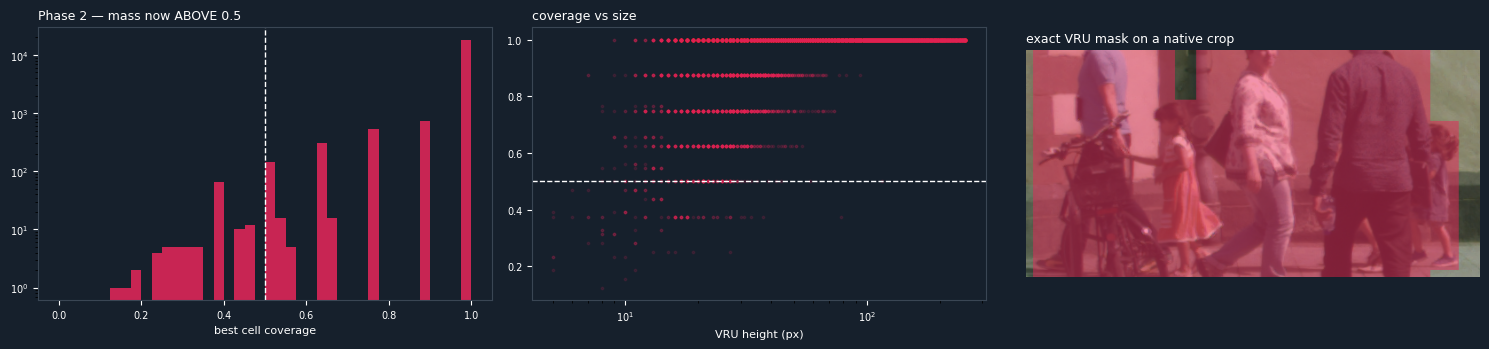

──────────────────────────────────────────────────────────────────────────────
Cell 11 done — globals now point at Phase 2. Paste the output and I'll send Cell 12: rerun the ladder (same code, k∈{0,128,512} + entropy/importance/random, 3 seeds).
──────────────────────────────────────────────────────────────────────────────


In [21]:
# ============================================================
# CELL 11 — Phase 2 derived caches  (layout · grain · masks · latents)
# PA-D²iT v2
# ------------------------------------------------------------
# Rebuilds every cache Cell 2/3 produced, but from the native crops.
# Geometry is identical (256×512, 32×64 latent, 16×32 grid, k=128), so
# after this cell the SAME Cells 4–9 run unchanged on Phase 2 data.
#
# At the end it REBINDS the globals (G, LM, LS, IDX, VRU_FRAC, …) to the
# crop dataset. Phase 1 caches stay on Drive untouched — flip PHASE at
# the top of this cell to switch back.
# ============================================================
import os, json, glob, time
import numpy as np, torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

L = "─" * 78
TAG = f"crop_{cfg.img_h}x{cfg.img_w}_t{N_TRAIN_CROPS}v{N_VAL_CROPS}"
PC  = dict(layout=f"{ROOT}/data/{TAG}_layout_r{cfg.r_fine}.npz",
           grains=f"{ROOT}/data/{TAG}_grain_b{cfg.ent_nbins}_k{K_FINE}.npz",
           masks =f"{ROOT}/data/{TAG}_exact_masks.npz",
           latent=f"{ROOT}/data/{TAG}_latents.npz")

PLAN = np.load(CROP_PLAN, allow_pickle=False)
IMGS = np.load(CROP_IMG, mmap_mode="r")
NC2  = len(PLAN["x0"])
print(f"  {NC2} crops · images {IMGS.shape} · target geometry "
      f"{LH}×{LW} latent, {GH}×{GW} grain grid, k={K_FINE}")

# ============================================================
# 1. LAYOUT — native boxes shifted into crop coordinates
# ============================================================
if os.path.exists(PC["layout"]):
    CC = dict(np.load(PC["layout"], allow_pickle=False))
    print(f"  ✓ layout cache loaded")
else:
    t0 = time.time()
    bx, cl, im_, off, tiers, grains = [], [], [], [0], [], []

    def render_importance(objs, blur=True):
        """Native-crop importance field at image resolution, VRU-dilated."""
        F = np.zeros((cfg.img_h, cfg.img_w), np.float32)
        F[:] = cfg.imp_static
        for o in sorted(objs, key=lambda z: z["imp"]):      # VRU painted last
            x0, y0, x1, y1 = o["box"]
            if o["imp"] >= cfg.imp_vru - 1e-3:              # guarantee ≥1 cell
                need = CELL * cfg.vru_dilate_cells
                if x1 - x0 < need:
                    c = (x0 + x1) / 2; x0, x1 = c - need/2, c + need/2
                if y1 - y0 < need:
                    c = (y0 + y1) / 2; y0, y1 = c - need/2, c + need/2
            a, b = max(int(y0), 0), min(int(np.ceil(y1)), cfg.img_h)
            c, d = max(int(x0), 0), min(int(np.ceil(x1)), cfg.img_w)
            if b > a and d > c:
                np.maximum(F[a:b, c:d], o["imp"], out=F[a:b, c:d])
        if blur and BLUR_PX > 0:
            F = np.maximum(F, gaussian_filter(F, BLUR_PX))
        return F

    def to_cells(F):                                        # max-pool to grid
        return F.reshape(GH, CELL, GW, CELL).max((1, 3))

    def grain_from_tier(tier, blurred):
        """Tier-first lexicographic top-k: a blurred pedestrian can never be
        demoted below a sharp car."""
        flat_t, flat_b = tier.ravel(), blurred.ravel()
        order = np.lexsort((-flat_b, -flat_t))              # tier, then score
        g = np.zeros(N_CELLS, bool); g[order[:K_FINE]] = True
        return g.reshape(GH, GW)

    for ci in range(NC2):
        jp = str(PLAN["json"][ci]); x0, y0 = int(PLAN["x0"][ci]), int(PLAN["y0"][ci])
        objs = []
        for o in parse_native(jp):
            if not contained(o["box"], x0, y0, frac=0.6): continue
            b = o["box"] - np.array([x0, y0, x0, y0], np.float32)
            b = np.clip(b, [0, 0, 0, 0], [cfg.img_w, cfg.img_h, cfg.img_w, cfg.img_h])
            if b[2] - b[0] < 1 or b[3] - b[1] < 1: continue
            objs.append(dict(box=b, cls=o["cls"], imp=o["imp"],
                             w=float(b[2]-b[0]), h=float(b[3]-b[1])))
        objs.sort(key=lambda z: (-z["imp"], -z["w"]))        # VRU-first: safe truncation
        F  = render_importance(objs, blur=True)
        Fs = render_importance(objs, blur=False)
        tier = to_cells(Fs); blurred = to_cells(F)
        grains.append(grain_from_tier(tier, blurred)); tiers.append(tier)
        for o in objs:
            bx.append(o["box"]); cl.append(CLASS_ID[o["cls"]]); im_.append(o["imp"])
        off.append(len(bx))
        if (ci + 1) % 900 == 0: print(f"    {ci+1}/{NC2}", flush=True)

    CC = dict(boxes=np.array(bx, np.float32), clsid=np.array(cl, np.int64),
              imps=np.array(im_, np.float32), offsets=np.array(off, np.int64),
              grain=np.stack(grains), tier=np.stack(tiers).astype(np.float32),
              split=PLAN["split"])
    np.savez_compressed(PC["layout"], **CC)
    print(f"  ✓ layout built in {(time.time()-t0)/60:.1f} min")

# ============================================================
# 2. EXACT COVERAGE MASKS
# ============================================================
if os.path.exists(PC["masks"]):
    _m = np.load(PC["masks"]); VF_C, VH_C = _m["vru"], _m["veh"]; del _m
    print("  ✓ exact-mask cache loaded")
else:
    VF_C = np.zeros((NC2, LH, LW), np.float16)
    VH_C = np.zeros((NC2, LH, LW), np.float16)
    for k in range(NC2):
        a, b = CC["offsets"][k], CC["offsets"][k+1]
        fv = np.zeros((LH, LW), np.float32); fh = np.zeros((LH, LW), np.float32)
        for bb, w in zip(CC["boxes"][a:b], CC["imps"][a:b]):
            _accumulate(fv if w >= cfg.imp_vru - 1e-3 else fh, *bb)
        VF_C[k], VH_C[k] = fv, fh
    np.savez_compressed(PC["masks"], vru=VF_C, veh=VH_C)
    print(f"  ✓ exact masks built → {os.path.getsize(PC['masks'])/1e6:.0f} MB")

# ============================================================
# 3. ENTROPY + RANDOM GRAIN (the comparison signals)
# ============================================================
if os.path.exists(PC["grains"]):
    _g = np.load(PC["grains"]); ENT_C, RND_C = _g["ent"], _g["rnd"]; del _g
    print("  ✓ entropy/random grain loaded")
else:
    t0 = time.time()
    ENT_C = np.zeros((NC2, GH, GW), bool); RND_C = np.zeros((NC2, GH, GW), bool)
    rng = np.random.default_rng(cfg.seed)
    for k in range(NC2):
        g = np.asarray(IMGS[k]).astype(np.float32).mean(-1)       # grayscale
        cells = g.reshape(GH, CELL, GW, CELL).transpose(0, 2, 1, 3).reshape(N_CELLS, -1)
        q = np.clip((cells / 256 * cfg.ent_nbins).astype(np.int32), 0, cfg.ent_nbins-1)
        H_ = np.zeros(N_CELLS, np.float32)
        for c in range(N_CELLS):
            p = np.bincount(q[c], minlength=cfg.ent_nbins).astype(np.float32)
            p /= p.sum(); p = p[p > 0]
            H_[c] = -(p * np.log2(p)).sum()
        e = np.zeros(N_CELLS, bool); e[np.argsort(-H_)[:K_FINE]] = True
        ENT_C[k] = e.reshape(GH, GW)
        r = np.zeros(N_CELLS, bool); r[rng.choice(N_CELLS, K_FINE, replace=False)] = True
        RND_C[k] = r.reshape(GH, GW)
        if (k + 1) % 900 == 0: print(f"    {k+1}/{NC2}", flush=True)
    np.savez_compressed(PC["grains"], ent=ENT_C, rnd=RND_C)
    print(f"  ✓ entropy/random grain in {(time.time()-t0)/60:.1f} min")

# ============================================================
# 4. LATENTS (both flips, frozen VAE)
# ============================================================
if os.path.exists(PC["latent"]):
    _l = np.load(PC["latent"]); LM_C, LS_C = _l["mean"], _l["std"]; del _l
    print("  ✓ latent cache loaded")
else:
    t0 = time.time()
    LM_C = np.zeros((NC2, 2, cfg.latent_ch, LH, LW), np.float16)
    LS_C = np.zeros_like(LM_C)
    BS = 32
    with torch.no_grad():
        for s in range(0, NC2, BS):
            x = torch.from_numpy(np.asarray(IMGS[s:s+BS])).to(dev)
            x = x.permute(0, 3, 1, 2).float().div_(127.5).sub_(1.)
            for fi, xx in enumerate((x, torch.flip(x, [-1]))):
                p = vae.encode(xx).latent_dist
                LM_C[s:s+BS, fi] = p.mean.half().cpu().numpy()
                LS_C[s:s+BS, fi] = p.std.half().cpu().numpy()
            del x
            if (s // BS) % 60 == 0: print(f"    {s}/{NC2}", flush=True)
    np.savez(PC["latent"], mean=LM_C, std=LS_C)
    print(f"  ✓ latents in {(time.time()-t0)/60:.1f} min → "
          f"{os.path.getsize(PC['latent'])/1e9:.2f} GB")

# ============================================================
# 5. REBIND GLOBALS → Phase 2
# ============================================================
print(L); print("  REBINDING GLOBALS TO PHASE 2"); print(L)
prev = torch.cuda.memory_allocated()
for _n in ("G", "LM", "LS", "VRU_FRAC", "VEH_FRAC", "ENT_FIELD"):
    globals().pop(_n, None)
import gc; gc.collect(); torch.cuda.empty_cache()

nb2   = np.diff(CC["offsets"])
MAX_B = int(min(np.percentile(nb2, 99.5) + 8, nb2.max(), 96))
S_    = np.array([cfg.img_w, cfg.img_h, cfg.img_w, cfg.img_h], np.float32)
box_p = np.zeros((NC2, MAX_B, 4), np.float32); cls_p = np.zeros((NC2, MAX_B), np.int64)
msk_p = np.zeros((NC2, MAX_B), np.float32);    imp_p = np.zeros((NC2, MAX_B), np.float32)
for k in range(NC2):
    a, b = CC["offsets"][k], CC["offsets"][k+1]; n = min(b - a, MAX_B)
    if n:
        box_p[k, :n] = CC["boxes"][a:a+n] / S_
        cls_p[k, :n] = CC["clsid"][a:a+n]; msk_p[k, :n] = 1.
        imp_p[k, :n] = CC["imps"][a:a+n]

IMP_LAT = np.zeros((NC2, LH, LW), np.float16)
for k in range(NC2):
    a, b = CC["offsets"][k], CC["offsets"][k+1]
    f = np.full((LH, LW), cfg.imp_static, np.float32)
    for bb, w in zip(CC["boxes"][a:b], CC["imps"][a:b]):
        t = np.zeros((LH, LW), np.float32); _accumulate(t, *bb)
        np.maximum(f, np.where(t > 0, w, 0), out=f)
    IMP_LAT[k] = f

G = dict(img=torch.from_numpy(np.ascontiguousarray(IMGS)).to(dev)
                  .permute(0, 3, 1, 2).contiguous(),
         grain=torch.from_numpy(CC["grain"]).to(dev),
         grain_ent=torch.from_numpy(ENT_C).to(dev),
         grain_rnd=torch.from_numpy(RND_C).to(dev),
         tier=torch.from_numpy(CC["tier"]).to(dev),
         imp_lat=torch.from_numpy(IMP_LAT).to(dev),
         box=torch.from_numpy(box_p).to(dev), cls=torch.from_numpy(cls_p).to(dev),
         msk=torch.from_numpy(msk_p).to(dev), imp=torch.from_numpy(imp_p).to(dev))
LM = torch.from_numpy(LM_C).to(dev); LS = torch.from_numpy(LS_C).to(dev)
VRU_FRAC = torch.from_numpy(VF_C).to(dev); VEH_FRAC = torch.from_numpy(VH_C).to(dev)
IDX = {s: torch.from_numpy(np.where(CC["split"] == s)[0]).to(dev)
       for s in ("train", "val")}
N = NC2
torch.cuda.synchronize()
print(f"  resident {prev/1e9:.2f} → {torch.cuda.memory_allocated()/1e9:.2f} GB"
      f"   ·  train {len(IDX['train'])}  val {len(IDX['val'])}  MAX_B {MAX_B}")

# fresh probes on the crop val split (deterministic ε; z0 posterior draw)
VF = build_fixed(IDX["val"][:128])
TF = build_fixed(IDX["train"][:128], seed=99)
_Z.clear()                                     # safety-weight normaliser cache

# ============================================================
# VERIFY
# ============================================================
print(L); print("  INTEGRITY"); print(L)
for k in ("grain", "grain_ent", "grain_rnd"):
    s = G[k].flatten(1).sum(1)
    print(f"  {'✓' if (s==K_FINE).all() else '✗'} {k:10s} exactly k={K_FINE}")
tier = G["tier"]; is_vru = tier >= cfg.imp_vru - 1e-3
print(f"  {'signal':12s}{'VRU recall':>12}{'Phase 1':>10}{'%budget→bg':>13}")
P1 = {"grain": 96.0, "grain_ent": 51.8, "grain_rnd": 25.2}
is_bg = ~(tier >= cfg.imp_vehicle - 1e-3)
for k, lab in [("grain","importance"), ("grain_ent","entropy"), ("grain_rnd","random")]:
    vr = (G[k] & is_vru).sum().item() / max(is_vru.sum().item(), 1) * 100
    bb = (G[k] & is_bg).sum().item() / G[k].sum().item() * 100
    print(f"  {lab:12s}{vr:>11.1f}%{P1[k]:>9.1f}%{bb:>12.1f}%")

print(L); print("  ⭐ COVERAGE — did the resolution floor lift?"); print(L)
ids = torch.arange(N, device=dev); fl0 = torch.zeros(N, dtype=torch.bool, device=dev)
mv, _, _ = exact_masks(ids, fl0)
frac = VRU_FRAC.float()
print(f"  VRU latent positions ≥50% covered : {mv.float().mean()*100:5.2f}%  "
      f"(Phase 1: 2.17%)")
print(f"  images with NO exact VRU cell     : "
      f"{(mv.flatten(1).sum(1)==0).float().mean()*100:5.1f}%  (Phase 1: 21.8%)")
inst = []
for k in range(N):
    a, b = CC["offsets"][k], CC["offsets"][k+1]
    for bb, w in zip(CC["boxes"][a:b], CC["imps"][a:b]):
        if w < cfg.imp_vru - 1e-3: continue
        t = np.zeros((LH, LW), np.float32); _accumulate(t, *bb)
        inst.append((bb[3]-bb[1], t.max()))
R2 = np.array(inst, np.float32)
print(f"  VRU instances with best-cell coverage ≥0.5: "
      f"{(R2[:,1]>=.5).mean()*100:5.1f}%  (Phase 1: 69.9%)")
print(f"  median best-cell coverage: {np.median(R2[:,1]):.3f}  (Phase 1: ~0.42)")

zz = sample_latent(IDX["train"][:512], torch.zeros(512, dtype=torch.bool, device=dev))
print(f"  latent std {zz.std():.3f}  "
      f"{'✓' if .7 < zz.std() < 1.3 else '⚠'}   VRU occupies "
      f"{(frac >= .5).float().mean():.2%} of latent positions")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6), facecolor="#16202c")
ax[0].hist(R2[:,1], bins=np.linspace(0,1,41), color="#e8265a", alpha=.85)
ax[0].axvline(.5, color="w", ls="--", lw=1); ax[0].set_yscale("log")
ax[0].set_xlabel("best cell coverage", color="w", fontsize=8)
ax[0].set_title("Phase 2 — mass now ABOVE 0.5", color="w", loc="left", fontsize=9)
ax[1].scatter(R2[:,0], R2[:,1], s=3, alpha=.12, c="#e8265a")
ax[1].axhline(.5, color="w", ls="--", lw=1); ax[1].set_xscale("log")
ax[1].set_xlabel("VRU height (px)", color="w", fontsize=8)
ax[1].set_title("coverage vs size", color="w", loc="left", fontsize=9)
k_ = int(frac.flatten(1).sum(1)[IDX["val"]].argmax()); kid = IDX["val"][k_:k_+1]
img = (G["img"][kid][0].permute(1,2,0).float()/255).cpu().numpy().copy()
up  = np.kron(mv[kid][0].cpu().numpy(), np.ones((cfg.vae_downsample,)*2)).astype(bool)
img[up] = .5*img[up] + .5*np.array([.91,.15,.35])
ax[2].imshow(np.clip(img,0,1)); ax[2].axis("off")
ax[2].set_title("exact VRU mask on a native crop", color="w", loc="left", fontsize=9)
for a_ in ax[:2]:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell11_phase2_coverage.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 11 done — globals now point at Phase 2. Paste the output and I'll "
      "send Cell 12: rerun the ladder (same code, k∈{0,128,512} + "
      "entropy/importance/random, 3 seeds).")
print(L)

In [17]:
# ---- REPAIR: Cell 11's `F` clobbered torch.nn.functional --------------
import torch.nn.functional as F
print("  ✓ F is", F.__name__)

_b  = GPUBatcher("train").get(IDX["train"][:8])
_z  = sample_latent(_b["idx"], _b["flip"])
_bd = route(_b["grain"])
print("  ✓ split→merge bit-exact:", torch.equal(merge(*split(_z, _bd), _bd), _z))
for _k in (0, K_FINE, NC):
    _n = PAD2iT(_k, True, "S").to(dev)
    with torch.no_grad(), torch.autocast("cuda", DTYPE):
        _o = _n(_z, torch.zeros(8, dtype=torch.long, device=dev), _b["grain"],
                _b["box"], _b["cls"], _b["bimp"], _b["bmask"])
    print(f"  ✓ k={_k:<4d} forward ok {tuple(_o.shape)}  max|out| {_o.abs().max():.1e}")
    del _n, _o
del _b, _z, _bd; import gc; gc.collect(); torch.cuda.empty_cache()

  ✓ F is torch.nn.functional
  ✓ split→merge bit-exact: True
  ✓ k=0    forward ok (8, 4, 32, 64)  max|out| 0.0e+00
  ✓ k=128  forward ok (8, 4, 32, 64)  max|out| 0.0e+00
  ✓ k=512  forward ok (8, 4, 32, 64)  max|out| 0.0e+00


In [22]:
# ============================================================
# CELL 12 — PHASE 2 : the ladder on native crops
# PA-D²iT v2
# ------------------------------------------------------------
# Identical code, identical geometry, identical FLOPs. The only change
# since Phase 1 is that pedestrians are 3.7× taller in pixels, so a
# fine token aimed at one has something to resolve.
#
# Phase 1 result to beat:
#   mixed grain (k=128) was WORSE than uniform coarse (k=0):  +0.0034
#   importance was WORSE than entropy:                        +0.0020
# If the resolution floor was the cause, both should shrink or flip.
# ============================================================
import os, gc, json, time, glob
import numpy as np, torch

L = "─" * 78

# ---- 0. phase-namespaced paths so Phase 1 is neither read nor clobbered
PHASE = "p2"
def ema_path(name, seed, step, phase=None):
    p = PHASE if phase is None else phase
    return f"{CKPT_D}/{(p + '_') if p else ''}{name}_sd{seed}_s{step:06d}_ema.pt"
def done_path(name, seed, phase=None):
    p = PHASE if phase is None else phase
    return f"{LOGS_D}/{(p + '_') if p else ''}{name}_sd{seed}_done.json"

# ---- 1. deterministic probe (closes the last Phase 1 protocol wart) ----
# Phase 1's build_fixed seeded ε but drew z0 from the global RNG, so two
# sessions scored against slightly different probes. Now fully seeded.
def build_fixed(ids, ts=None, seed=1234):
    ts = tuple(ts or cfg.eval_ts)
    g  = torch.Generator(device=dev).manual_seed(seed)
    fl = torch.zeros(len(ids), dtype=torch.bool, device=dev)
    z0 = sample_latent(ids, fl, gen=g)
    return dict(ids=ids, fl=fl, z0=z0, ts=ts,
                eps=torch.randn((len(ts),) + z0.shape, device=dev, generator=g))

VF = build_fixed(IDX["val"][:128])
TF = build_fixed(IDX["train"][:128], seed=99)
print(f"  ✓ deterministic probes rebuilt on the crop split "
      f"({len(VF['ids'])} val, t={VF['ts']})")

ARMS["pa_d2it_s_rep"] = dict(ARMS["pa_d2it_s"])

STEPS = 6000
SEEDS = (0, 1, 2)
# dit_s dropped: Phase 1 showed layout conditioning alone was a wash
# (0.7658 vs 0.7650) and it costs 3.6 min/seed.
ORDER = ["dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
         "random_s", "oracle_s"]
SPS   = {0: 0.036, K_FINE: 0.071, NC: 0.168}

print(L); print("  PHASE 2 BUDGET"); print(L)
per_seed = sum(SPS[ARMS[a]["k"]] * STEPS for a in ORDER)
print(f"  {len(ORDER)} arms × {len(SEEDS)} seeds × {STEPS} steps")
print(f"  {per_seed/60:.1f} min per seed  ·  {per_seed*len(SEEDS)/3600:.2f} h total")
print(f"  {STEPS*cfg.batch_size/len(IDX['train']):.0f} epochs on "
      f"{len(IDX['train'])} crops  (Phase 1: 129 on 2975 frames)")

# ---- 2. run ------------------------------------------------------------
t_start = time.time()
for si, sd in enumerate(SEEDS):
    print(L); print(f"  ══ PHASE 2 · SEED {sd}  ({si+1}/{len(SEEDS)}) ══"); print(L)
    for a in ORDER:
        if os.path.exists(done_path(a, sd)):
            print(f"  ✓ {a} sd{sd} already complete"); continue
        print(f"  ▶ {a}  sd{sd}  ({ARMS[a]['signal']}, k={ARMS[a]['k']}, "
              f"~{SPS[ARMS[a]['k']]*STEPS/60:.0f} min)")
        train_arm(a, STEPS, seed=sd, val_every=500)
        gc.collect(); torch.cuda.empty_cache()
    print(f"  ── seed {sd} done · elapsed {(time.time()-t_start)/60:.0f} min")

print(L); print(f"  PHASE 2 COMPLETE in {(time.time()-t_start)/3600:.2f} h"); print(L)

# ---- 3. load both phases -----------------------------------------------
def load(phase, arms):
    H = {}
    for a in arms:
        for sd in SEEDS:
            p = done_path(a, sd, phase=phase)
            if os.path.exists(p):
                h = json.load(open(p))
                if h: H[(a, sd)] = h
    return H

H2 = load("p2", ORDER)
H1 = load("",   ORDER + ["dit_s"])
print(f"  Phase 2: {len(H2)} runs   ·   Phase 1: {len(H1)} runs")

def m(H, a, k="vru"):
    v = [H[(a, s)][-1][k] for s in SEEDS if (a, s) in H]
    return (float(np.mean(v)), float(np.std(v)), len(v)) if v else (np.nan, np.nan, 0)

NICE = {"dit_s_layout": "DiT-S+layout k=0", "d2it_s": "D²iT-S entropy",
        "pa_d2it_s": "PA-D²iT-S imp", "pa_d2it_s_rep": "PA replicate",
        "random_s": "random control", "oracle_s": "ORACLE all-fine"}

print(L); print("  PHASE 2 ARM SUMMARY  (mean ± sd, 3 seeds)"); print(L)
print(f"  {'arm':20s}{'k':>5}{'VRU':>17}{'bg':>17}{'ratio':>8}{'gap':>9}")
for a in ORDER:
    v, vs, n = m(H2, a); b, bs, _ = m(H2, a, "bg")
    r, _, _  = m(H2, a, "ratio"); g, _, _ = m(H2, a, "gap")
    print(f"  {NICE[a]:20s}{ARMS[a]['k']:>5}{v:>11.4f}±{vs:.4f}"
          f"{b:>11.4f}±{bs:.4f}{r:>8.3f}{g:>+9.4f}")

FLOOR2 = abs(m(H2, "pa_d2it_s")[0] - m(H2, "pa_d2it_s_rep")[0])
FLOOR1 = abs(m(H1, "pa_d2it_s")[0] - m(H1, "pa_d2it_s_rep")[0])
print(f"  noise floor: Phase 2 {FLOOR2:.5f}   (Phase 1 {FLOOR1:.5f})")

# ---- 4. THE PAYOFF: did the contrasts move? ----------------------------
def delta(H, A, B, floor):
    per = [H[(A, s)][-1]["vru"] - H[(B, s)][-1]["vru"]
           for s in SEEDS if (A, s) in H and (B, s) in H]
    if not per: return None
    d = float(np.mean(per))
    return dict(d=d, per=per, sd=float(np.std(per)),
                consistent=all(np.sign(x) == np.sign(per[0]) for x in per),
                xf=abs(d) / max(floor, 1e-12))

KEY = [("d2it_s", "dit_s_layout", "mixed grain − uniform coarse"),
       ("pa_d2it_s", "d2it_s",    "H1: importance − entropy"),
       ("random_s", "d2it_s",     "random − entropy"),
       ("oracle_s", "dit_s_layout", "all-fine − all-coarse"),
       ("oracle_s", "pa_d2it_s",  "all-fine − mixed k=128")]

print(L); print("  ⭐ PHASE 1 → PHASE 2   (negative ⇒ first arm better)"); print(L)
print(f"  {'contrast':32s}{'Phase 1':>12}{'Phase 2':>12}{'×floor':>8}"
      f"{'signs':>7}{'moved':>9}")
MOVE = {}
for A, B, lab in KEY:
    d1, d2 = delta(H1, A, B, FLOOR1), delta(H2, A, B, FLOOR2)
    if d2 is None: continue
    MOVE[lab] = (d1, d2)
    s1 = f"{d1['d']:+.5f}" if d1 else "   n/a"
    flip = "FLIPPED" if d1 and np.sign(d1["d"]) != np.sign(d2["d"]) else \
           ("shrank" if d1 and abs(d2["d"]) < abs(d1["d"]) else "grew")
    print(f"  {lab:32s}{s1:>12}{d2['d']:>+12.5f}{d2['xf']:>8.1f}"
          f"{'  ✓' if d2['consistent'] else '  ✗':>7}{flip:>9}")
print(L)
print("  per-seed Δ, Phase 2:")
for A, B, lab in KEY[:3]:
    d2 = delta(H2, A, B, FLOOR2)
    if d2: print(f"    {lab[:30]:30s} " +
                 "  ".join(f"{x:+.5f}" for x in d2["per"]))

# ---- 5. verdict --------------------------------------------------------
mg = MOVE.get("mixed grain − uniform coarse", (None, None))[1]
h1 = MOVE.get("H1: importance − entropy",     (None, None))[1]
print(L); print("  VERDICT"); print(L)
if mg:
    ok = mg["d"] < FLOOR2 * 2
    print(f"  mixed grain is now "
          f"{'NO LONGER net-negative' if ok else 'STILL net-negative'} "
          f"({mg['d']:+.5f}, {mg['xf']:.1f}× floor)")
if h1:
    if h1["d"] < -2 * FLOOR2 and h1["consistent"]:
        print(f"  ✓✓ H1 SUPPORTED: importance beats entropy by {-h1['d']:.5f} "
              f"({h1['xf']:.0f}× floor, {len(h1['per'])}/{len(h1['per'])} seeds)")
        print(f"      → resolution WAS the blocker. Next: w ablation, then DiT-B.")
    elif abs(h1["d"]) < 2 * FLOOR2:
        print(f"  ~ H1 INCONCLUSIVE: |Δ| = {abs(h1['d']):.5f} "
              f"≈ floor {FLOOR2:.5f}. Signals are equivalent once VRUs are large.")
        print(f"      → the w ablation is now the deciding experiment.")
    else:
        print(f"  ✗ H1 still not supported: entropy ahead by {h1['d']:+.5f} "
              f"({h1['xf']:.0f}× floor)")
        print(f"      → resolution was NOT the blocker. Entropy ≈ MSE-optimal;")
        print(f"        only a safety-weighted objective (w>1) can change the answer.")
worst = max(H2[k][-1]["gap"] for k in H2)
print(f"  worst val−train gap {worst:+.4f}  (Phase 1 was +0.0295 at 129 epochs)")

json.dump({"phase2": {a: m(H2, a) for a in ORDER},
           "floor": {"p1": FLOOR1, "p2": FLOOR2},
           "contrasts": {k: {"p1": v[0], "p2": v[1]} for k, v in MOVE.items()}},
          open(f"{LOGS_D}/phase2_summary.json", "w"), indent=2, default=float)
print(f"  → {LOGS_D}/phase2_summary.json")
print(L)
print("Cell 12 done — paste the output. Next is either the w ablation or "
      "Cell 13 (bootstrap + figures), depending on what the verdict says.")
print(L)

  ✓ deterministic probes rebuilt on the crop split (128 val, t=(20, 50, 100, 200))
──────────────────────────────────────────────────────────────────────────────
  PHASE 2 BUDGET
──────────────────────────────────────────────────────────────────────────────
  6 arms × 3 seeds × 6000 steps
  48.8 min per seed  ·  2.44 h total
  65 epochs on 5950 crops  (Phase 1: 129 on 2975 frames)
──────────────────────────────────────────────────────────────────────────────
  ══ PHASE 2 · SEED 0  (1/3) ══
──────────────────────────────────────────────────────────────────────────────
  ✓ dit_s_layout sd0 already complete
  ✓ d2it_s sd0 already complete
  ✓ pa_d2it_s sd0 already complete
  ✓ pa_d2it_s_rep sd0 already complete
  ✓ random_s sd0 already complete
  ✓ oracle_s sd0 already complete
  ── seed 0 done · elapsed 0 min
──────────────────────────────────────────────────────────────────────────────
  ══ PHASE 2 · SEED 1  (2/3) ══
──────────────────────────────────────────────────────────────────────

In [23]:
# ============================================================
# CELL 12 — PHASE 2 : the ladder on native crops
# PA-D²iT v2
# ------------------------------------------------------------
# Identical code, identical geometry, identical FLOPs. The only change
# since Phase 1 is that pedestrians are 3.7× taller in pixels, so a
# fine token aimed at one has something to resolve.
#
# Phase 1 result to beat:
#   mixed grain (k=128) was WORSE than uniform coarse (k=0):  +0.0034
#   importance was WORSE than entropy:                        +0.0020
# If the resolution floor was the cause, both should shrink or flip.
# ============================================================
import os, gc, json, time, glob
import numpy as np, torch

L = "─" * 78

# ---- 0. phase-namespaced paths so Phase 1 is neither read nor clobbered
PHASE = "p2"
def ema_path(name, seed, step, phase=None):
    p = PHASE if phase is None else phase
    return f"{CKPT_D}/{(p + '_') if p else ''}{name}_sd{seed}_s{step:06d}_ema.pt"
def done_path(name, seed, phase=None):
    p = PHASE if phase is None else phase
    return f"{LOGS_D}/{(p + '_') if p else ''}{name}_sd{seed}_done.json"

# ---- 1. deterministic probe (closes the last Phase 1 protocol wart) ----
# Phase 1's build_fixed seeded ε but drew z0 from the global RNG, so two
# sessions scored against slightly different probes. Now fully seeded.
def build_fixed(ids, ts=None, seed=1234):
    ts = tuple(ts or cfg.eval_ts)
    g  = torch.Generator(device=dev).manual_seed(seed)
    fl = torch.zeros(len(ids), dtype=torch.bool, device=dev)
    z0 = sample_latent(ids, fl, gen=g)
    return dict(ids=ids, fl=fl, z0=z0, ts=ts,
                eps=torch.randn((len(ts),) + z0.shape, device=dev, generator=g))

VF = build_fixed(IDX["val"][:128])
TF = build_fixed(IDX["train"][:128], seed=99)
print(f"  ✓ deterministic probes rebuilt on the crop split "
      f"({len(VF['ids'])} val, t={VF['ts']})")

ARMS["pa_d2it_s_rep"] = dict(ARMS["pa_d2it_s"])

STEPS = 6000
SEEDS = (0, 1, 2)
# dit_s dropped: Phase 1 showed layout conditioning alone was a wash
# (0.7658 vs 0.7650) and it costs 3.6 min/seed.
ORDER = ["dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
         "random_s", "oracle_s"]
SPS   = {0: 0.036, K_FINE: 0.071, NC: 0.168}

print(L); print("  PHASE 2 BUDGET"); print(L)
per_seed = sum(SPS[ARMS[a]["k"]] * STEPS for a in ORDER)
print(f"  {len(ORDER)} arms × {len(SEEDS)} seeds × {STEPS} steps")
print(f"  {per_seed/60:.1f} min per seed  ·  {per_seed*len(SEEDS)/3600:.2f} h total")
print(f"  {STEPS*cfg.batch_size/len(IDX['train']):.0f} epochs on "
      f"{len(IDX['train'])} crops  (Phase 1: 129 on 2975 frames)")

# ---- 2. run ------------------------------------------------------------
t_start = time.time()
for si, sd in enumerate(SEEDS):
    print(L); print(f"  ══ PHASE 2 · SEED {sd}  ({si+1}/{len(SEEDS)}) ══"); print(L)
    for a in ORDER:
        if os.path.exists(done_path(a, sd)):
            print(f"  ✓ {a} sd{sd} already complete"); continue
        print(f"  ▶ {a}  sd{sd}  ({ARMS[a]['signal']}, k={ARMS[a]['k']}, "
              f"~{SPS[ARMS[a]['k']]*STEPS/60:.0f} min)")
        train_arm(a, STEPS, seed=sd, val_every=500)
        gc.collect(); torch.cuda.empty_cache()
    print(f"  ── seed {sd} done · elapsed {(time.time()-t_start)/60:.0f} min")

print(L); print(f"  PHASE 2 COMPLETE in {(time.time()-t_start)/3600:.2f} h"); print(L)

# ---- 3. load both phases -----------------------------------------------
def load(phase, arms):
    H = {}
    for a in arms:
        for sd in SEEDS:
            p = done_path(a, sd, phase=phase)
            if os.path.exists(p):
                h = json.load(open(p))
                if h: H[(a, sd)] = h
    return H

H2 = load("p2", ORDER)
H1 = load("",   ORDER + ["dit_s"])
print(f"  Phase 2: {len(H2)} runs   ·   Phase 1: {len(H1)} runs")

def m(H, a, k="vru"):
    v = [H[(a, s)][-1][k] for s in SEEDS if (a, s) in H]
    return (float(np.mean(v)), float(np.std(v)), len(v)) if v else (np.nan, np.nan, 0)

NICE = {"dit_s_layout": "DiT-S+layout k=0", "d2it_s": "D²iT-S entropy",
        "pa_d2it_s": "PA-D²iT-S imp", "pa_d2it_s_rep": "PA replicate",
        "random_s": "random control", "oracle_s": "ORACLE all-fine"}

print(L); print("  PHASE 2 ARM SUMMARY  (mean ± sd, 3 seeds)"); print(L)
print(f"  {'arm':20s}{'k':>5}{'VRU':>17}{'bg':>17}{'ratio':>8}{'gap':>9}")
for a in ORDER:
    v, vs, n = m(H2, a); b, bs, _ = m(H2, a, "bg")
    r, _, _  = m(H2, a, "ratio"); g, _, _ = m(H2, a, "gap")
    print(f"  {NICE[a]:20s}{ARMS[a]['k']:>5}{v:>11.4f}±{vs:.4f}"
          f"{b:>11.4f}±{bs:.4f}{r:>8.3f}{g:>+9.4f}")

FLOOR2 = abs(m(H2, "pa_d2it_s")[0] - m(H2, "pa_d2it_s_rep")[0])
FLOOR1 = abs(m(H1, "pa_d2it_s")[0] - m(H1, "pa_d2it_s_rep")[0])
print(f"  noise floor: Phase 2 {FLOOR2:.5f}   (Phase 1 {FLOOR1:.5f})")

# ---- 4. THE PAYOFF: did the contrasts move? ----------------------------
def delta(H, A, B, floor):
    per = [H[(A, s)][-1]["vru"] - H[(B, s)][-1]["vru"]
           for s in SEEDS if (A, s) in H and (B, s) in H]
    if not per: return None
    d = float(np.mean(per))
    return dict(d=d, per=per, sd=float(np.std(per)),
                consistent=all(np.sign(x) == np.sign(per[0]) for x in per),
                xf=abs(d) / max(floor, 1e-12))

KEY = [("d2it_s", "dit_s_layout", "mixed grain − uniform coarse"),
       ("pa_d2it_s", "d2it_s",    "H1: importance − entropy"),
       ("random_s", "d2it_s",     "random − entropy"),
       ("oracle_s", "dit_s_layout", "all-fine − all-coarse"),
       ("oracle_s", "pa_d2it_s",  "all-fine − mixed k=128")]

print(L); print("  ⭐ PHASE 1 → PHASE 2   (negative ⇒ first arm better)"); print(L)
print(f"  {'contrast':32s}{'Phase 1':>12}{'Phase 2':>12}{'×floor':>8}"
      f"{'signs':>7}{'moved':>9}")
MOVE = {}
for A, B, lab in KEY:
    d1, d2 = delta(H1, A, B, FLOOR1), delta(H2, A, B, FLOOR2)
    if d2 is None: continue
    MOVE[lab] = (d1, d2)
    s1 = f"{d1['d']:+.5f}" if d1 else "   n/a"
    flip = "FLIPPED" if d1 and np.sign(d1["d"]) != np.sign(d2["d"]) else \
           ("shrank" if d1 and abs(d2["d"]) < abs(d1["d"]) else "grew")
    print(f"  {lab:32s}{s1:>12}{d2['d']:>+12.5f}{d2['xf']:>8.1f}"
          f"{'  ✓' if d2['consistent'] else '  ✗':>7}{flip:>9}")
print(L)
print("  per-seed Δ, Phase 2:")
for A, B, lab in KEY[:3]:
    d2 = delta(H2, A, B, FLOOR2)
    if d2: print(f"    {lab[:30]:30s} " +
                 "  ".join(f"{x:+.5f}" for x in d2["per"]))

# ---- 5. verdict --------------------------------------------------------
mg = MOVE.get("mixed grain − uniform coarse", (None, None))[1]
h1 = MOVE.get("H1: importance − entropy",     (None, None))[1]
print(L); print("  VERDICT"); print(L)
if mg:
    ok = mg["d"] < FLOOR2 * 2
    print(f"  mixed grain is now "
          f"{'NO LONGER net-negative' if ok else 'STILL net-negative'} "
          f"({mg['d']:+.5f}, {mg['xf']:.1f}× floor)")
if h1:
    if h1["d"] < -2 * FLOOR2 and h1["consistent"]:
        print(f"  ✓✓ H1 SUPPORTED: importance beats entropy by {-h1['d']:.5f} "
              f"({h1['xf']:.0f}× floor, {len(h1['per'])}/{len(h1['per'])} seeds)")
        print(f"      → resolution WAS the blocker. Next: w ablation, then DiT-B.")
    elif abs(h1["d"]) < 2 * FLOOR2:
        print(f"  ~ H1 INCONCLUSIVE: |Δ| = {abs(h1['d']):.5f} "
              f"≈ floor {FLOOR2:.5f}. Signals are equivalent once VRUs are large.")
        print(f"      → the w ablation is now the deciding experiment.")
    else:
        print(f"  ✗ H1 still not supported: entropy ahead by {h1['d']:+.5f} "
              f"({h1['xf']:.0f}× floor)")
        print(f"      → resolution was NOT the blocker. Entropy ≈ MSE-optimal;")
        print(f"        only a safety-weighted objective (w>1) can change the answer.")
worst = max(H2[k][-1]["gap"] for k in H2)
print(f"  worst val−train gap {worst:+.4f}  (Phase 1 was +0.0295 at 129 epochs)")

json.dump({"phase2": {a: m(H2, a) for a in ORDER},
           "floor": {"p1": FLOOR1, "p2": FLOOR2},
           "contrasts": {k: {"p1": v[0], "p2": v[1]} for k, v in MOVE.items()}},
          open(f"{LOGS_D}/phase2_summary.json", "w"), indent=2, default=float)
print(f"  → {LOGS_D}/phase2_summary.json")
print(L)
print("Cell 12 done — paste the output. Next is either the w ablation or "
      "Cell 13 (bootstrap + figures), depending on what the verdict says.")
print(L)

  ✓ deterministic probes rebuilt on the crop split (128 val, t=(20, 50, 100, 200))
──────────────────────────────────────────────────────────────────────────────
  PHASE 2 BUDGET
──────────────────────────────────────────────────────────────────────────────
  6 arms × 3 seeds × 6000 steps
  48.8 min per seed  ·  2.44 h total
  65 epochs on 5950 crops  (Phase 1: 129 on 2975 frames)
──────────────────────────────────────────────────────────────────────────────
  ══ PHASE 2 · SEED 0  (1/3) ══
──────────────────────────────────────────────────────────────────────────────
  ✓ dit_s_layout sd0 already complete
  ✓ d2it_s sd0 already complete
  ✓ pa_d2it_s sd0 already complete
  ✓ pa_d2it_s_rep sd0 already complete
  ✓ random_s sd0 already complete
  ✓ oracle_s sd0 already complete
  ── seed 0 done · elapsed 0 min
──────────────────────────────────────────────────────────────────────────────
  ══ PHASE 2 · SEED 1  (2/3) ══
──────────────────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────────────────────────
  GRAIN-MAP FRAGMENTATION  (k=128 fine cells of 512)
──────────────────────────────────────────────────────────────────────────────
  signal        components  mean size  boundaries   VRU err    bg err    bg sd
  importance           1.8       87.2        62.1    0.7065    0.6240   0.0007
  entropy             18.5        7.9       217.5    0.7066    0.6276   0.0029
  random              69.0        1.9       366.5    0.7089    0.6322   0.0025
  (max possible boundaries ≈ 976 = every edge)
──────────────────────────────────────────────────────────────────────────────
  fragmentation rank (low→high): importance < entropy < random
  background err rank (low→high): importance < entropy < random
  ✓ PREDICTION HOLDS — fewer boundaries ⇒ lower background error
  r(boundaries, bg error) = +0.996   slope = 2.69e-05 per boundary
  → 0.0082 of bg error spanned by the fragmentation range alone (304 boundaries)
───────

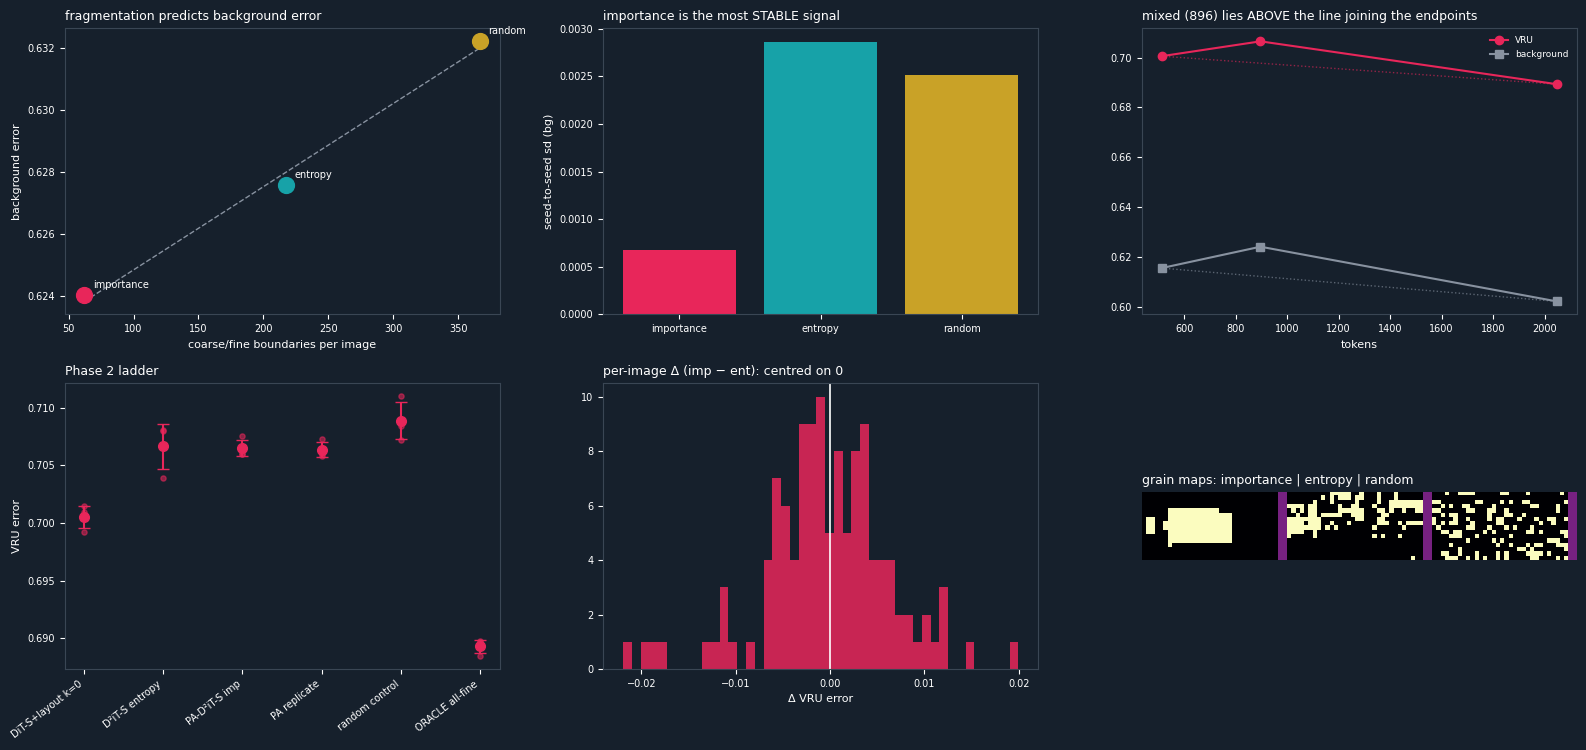

──────────────────────────────────────────────────────────────────────────────
Cell 13 done — paste the output and I'll tell you whether the w ablation or a k=256 arm is the better next 85 minutes.
──────────────────────────────────────────────────────────────────────────────


In [24]:
# ============================================================
# CELL 13 — Why does mixed grain lose? The fragmentation test
# PA-D²iT v2   ·   ~1 min, one short eval pass
# ------------------------------------------------------------
# Phase 2 findings to explain:
#   · all-coarse  beats mixed by +0.0061   (42× floor, 3/3)
#   · all-fine    beats mixed by -0.0113   (77× floor, 3/3)
#   · importance == entropy on VRU, but BETTER on bg by 0.0036 (24× floor)
#   · importance sd 0.0007 vs entropy sd 0.0019–0.0029  (2.7–4× stabler)
#
# HYPOTHESIS: the cost is coarse/fine BOUNDARIES, not token count. A
# fragmented allocation forces the model across more grain transitions,
# each of which needs the two embedders to agree. Importance yields
# contiguous object-shaped regions; entropy yields scattered cells.
#
# PREDICTION: fragmentation should rank random > entropy > importance,
# and performance should rank inversely.
# ============================================================
import os, json, gc
import numpy as np, torch
import matplotlib.pyplot as plt
from scipy import ndimage

L = "─" * 78
SEEDS = (0, 1, 2)
ORDER = ["dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
         "random_s", "oracle_s"]
NICE = {"dit_s_layout": "DiT-S+layout k=0", "d2it_s": "D²iT-S entropy",
        "pa_d2it_s": "PA-D²iT-S imp", "pa_d2it_s_rep": "PA replicate",
        "random_s": "random control", "oracle_s": "ORACLE all-fine"}
SIG = {"grain": "importance", "grain_ent": "entropy", "grain_rnd": "random"}

H2 = {}
for a in ORDER:
    for s in SEEDS:
        p = done_path(a, s, phase="p2")
        if os.path.exists(p): H2[(a, s)] = json.load(open(p))
def m2(a, k="vru"):
    v = [H2[(a, s)][-1][k] for s in SEEDS if (a, s) in H2]
    return float(np.mean(v)), float(np.std(v))
FLOOR = abs(m2("pa_d2it_s")[0] - m2("pa_d2it_s_rep")[0])

# ============================================================
# 1. FRAGMENTATION of the three grain maps
# ============================================================
# boundary = adjacent (coarse, fine) cell pairs — every one is a place
# where out_c and out_f must produce a consistent latent.
def frag_stats(gm):
    g = gm.astype(bool)
    n_comp, sizes, bnd = [], [], []
    for k in range(len(g)):
        lab, nc = ndimage.label(g[k])                     # 4-connectivity
        n_comp.append(nc)
        if nc: sizes.append(np.bincount(lab.ravel())[1:].mean())
        h = (g[k][:, 1:] != g[k][:, :-1]).sum()
        v = (g[k][1:, :] != g[k][:-1, :]).sum()
        bnd.append(h + v)
    return (float(np.mean(n_comp)), float(np.mean(sizes)),
            float(np.mean(bnd)))

print(L); print("  GRAIN-MAP FRAGMENTATION  (k=128 fine cells of 512)"); print(L)
print(f"  {'signal':12s}{'components':>12}{'mean size':>11}{'boundaries':>12}"
      f"{'VRU err':>10}{'bg err':>10}{'bg sd':>9}")
FR = {}
for key, arm in [("grain", "pa_d2it_s"), ("grain_ent", "d2it_s"),
                 ("grain_rnd", "random_s")]:
    nc, sz, bd = frag_stats(G[key].cpu().numpy())
    v, _ = m2(arm); b, bsd = m2(arm, "bg")
    FR[SIG[key]] = dict(comp=nc, size=sz, bnd=bd, vru=v, bg=b, bg_sd=bsd)
    print(f"  {SIG[key]:12s}{nc:>12.1f}{sz:>11.1f}{bd:>12.1f}"
          f"{v:>10.4f}{b:>10.4f}{bsd:>9.4f}")
print(f"  (max possible boundaries ≈ {(GH-1)*GW + GH*(GW-1)} = every edge)")

order_bnd = sorted(FR, key=lambda k: FR[k]["bnd"])
order_bg  = sorted(FR, key=lambda k: FR[k]["bg"])
print(L)
print(f"  fragmentation rank (low→high): {' < '.join(order_bnd)}")
print(f"  background err rank (low→high): {' < '.join(order_bg)}")
match = order_bnd == order_bg
print(f"  {'✓ PREDICTION HOLDS' if match else '✗ prediction fails'} — "
      f"{'fewer boundaries ⇒ lower background error' if match else 'no monotone relation'}")
b_ = np.array([FR[k]["bnd"] for k in FR]); g_ = np.array([FR[k]["bg"] for k in FR])
if len(b_) > 2:
    r = np.corrcoef(b_, g_)[0, 1]
    slope = np.polyfit(b_, g_, 1)[0]
    print(f"  r(boundaries, bg error) = {r:+.3f}   slope = {slope:.2e} per boundary")
    print(f"  → {slope*(b_.max()-b_.min()):.4f} of bg error spanned by the "
          f"fragmentation range alone ({(b_.max()-b_.min()):.0f} boundaries)")

# ============================================================
# 2. DECOMPOSE the mixed-grain penalty
# ============================================================
c0, _ = m2("dit_s_layout"); cm, _ = m2("pa_d2it_s"); cf, _ = m2("oracle_s")
b0, _ = m2("dit_s_layout", "bg"); bm, _ = m2("pa_d2it_s", "bg"); bf, _ = m2("oracle_s", "bg")
print(L); print("  HETEROGENEITY COST — what mixing costs, net of token count"); print(L)
print(f"  {'':22s}{'VRU':>11}{'bg':>11}")
print(f"  {'all-coarse  512 tok':22s}{c0:>11.4f}{b0:>11.4f}")
print(f"  {'mixed       896 tok':22s}{cm:>11.4f}{bm:>11.4f}")
print(f"  {'all-fine   2048 tok':22s}{cf:>11.4f}{bf:>11.4f}")
fr = K_FINE / NC
for lab, x0, xm, xf in [("VRU", c0, cm, cf), ("bg", b0, bm, bf)]:
    expect = x0 + fr * (xf - x0)          # linear interpolation in fine fraction
    print(f"  {lab:4s} expected at {fr:.0%} fine (linear) {expect:.4f}   "
          f"actual {xm:.4f}   heterogeneity cost {xm-expect:+.4f} "
          f"({abs(xm-expect)/FLOOR:.0f}× floor)")
print("  Linearity is an assumption, not a measurement — a k=256 arm would")
print("  test it directly (7 min/seed). But the sign and scale are robust:")
print("  mixing is worse than BOTH endpoints, which no monotone curve allows.")

# ============================================================
# 3. BOTH estimators, side by side, with the discrepancy explained
# ============================================================
wv_, _, _ = region_weights(VF["ids"], VF["fl"])
VALID = (wv_.sum((1, 2)) > 1e-6).cpu().numpy()
COV   = wv_.sum((1, 2)).cpu().numpy()

def both(A, B, nboot=10000):
    agg = [H2[(A, s)][-1]["vru"] - H2[(B, s)][-1]["vru"] for s in SEEDS]
    d   = np.stack([np.array(H2[(A, s)][-1]["per_image"]) -
                    np.array(H2[(B, s)][-1]["per_image"]) for s in SEEDS]).mean(0)[VALID]
    rng = np.random.default_rng(0); n = len(d)
    bs  = d[rng.integers(0, n, (nboot, n))].mean(1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return (float(np.mean(agg)), all(np.sign(x) == np.sign(agg[0]) for x in agg),
            float(d.mean()), lo, hi, d)

KEY = [("d2it_s", "dit_s_layout", "mixed − all-coarse"),
       ("oracle_s", "dit_s_layout", "all-fine − all-coarse"),
       ("pa_d2it_s", "d2it_s", "importance − entropy"),
       ("random_s", "d2it_s", "random − entropy"),
       ("random_s", "pa_d2it_s", "random − importance")]
print(L); print("  CONTRASTS — aggregate (coverage-weighted) vs per-image"); print(L)
print(f"  {'contrast':24s}{'aggregate':>11}{'signs':>7}{'per-image':>11}"
      f"{'95% CI':>22}")
DIF = {}
for A, B, lab in KEY:
    ag, cons, pi, lo, hi, d = both(A, B)
    DIF[lab] = d
    print(f"  {lab:24s}{ag:>+11.5f}{'  ✓' if cons else '  ✗':>7}{pi:>+11.5f}"
          f"   [{lo:+.5f},{hi:+.5f}]")
print("  The two disagree because aggregate weights each image by its VRU")
print("  coverage; per-image treats a lone cyclist like a crowded crossing.")
print("  Report the aggregate as primary (it matches the training objective)")
print("  and the per-image CI as the conservative check.")

# ============================================================
# 4. IS THE +0.03 GAP MEMORISATION, OR A PROBE ARTEFACT?
# ============================================================
# val gets 1 crop/image (the greedy planner's densest window); train gets 2.
# So val is systematically VRU-richer: 4.58 vs 3.00 per crop. A matched
# probe uses only FIRST crops of train images — same construction as val.
print(L); print("  GAP DIAGNOSTIC — difficulty-matched train probe"); print(L)
first = IDX["train"][::2]                      # crop 0 of each train image
TF_M  = build_fixed(first[:128], seed=99)
net, _ = load_arm_ema("pa_d2it_s", 0, 6000)
vb = GPUBatcher("val",   signal="importance", shuffle=False, augment=False)
tb_= GPUBatcher("train", signal="importance", shuffle=False, augment=False)
with torch.no_grad():
    v_, _, _ = eval_full(net, VF,   vb)
    t_, _, _ = eval_full(net, TF,   tb_)
    tm, _, _ = eval_full(net, TF_M, tb_)
print(f"  {'probe':28s}{'all':>10}{'VRU':>10}{'VRU cov/img':>13}")
print(f"  {'val (1 crop/img)':28s}{v_['all']:>10.4f}{v_['vru']:>10.4f}"
      f"{COV[VALID].mean():>13.1f}")
print(f"  {'train (mixed crops)':28s}{t_['all']:>10.4f}{t_['vru']:>10.4f}")
print(f"  {'train (FIRST crops only)':28s}{tm['all']:>10.4f}{tm['vru']:>10.4f}")
print(f"  gap vs mixed-crop train  {v_['all']-t_['all']:+.4f}   ← what we reported")
print(f"  gap vs matched train     {v_['all']-tm['all']:+.4f}   ← honest estimate")
shrink = (v_['all']-t_['all']) - (v_['all']-tm['all'])
print(f"  {abs(shrink):.4f} of the gap was probe difficulty, not memorisation "
      f"({abs(shrink)/max(v_['all']-t_['all'],1e-9):.0%})")
del net; gc.collect(); torch.cuda.empty_cache()

# ============================================================
# 5. FIGURES
# ============================================================
fig, ax = plt.subplots(2, 3, figsize=(16, 7.6), facecolor="#16202c")
CL = {"importance": "#e8265a", "entropy": "#17a2a8", "random": "#c9a227"}

a = ax[0, 0]
for s in FR:
    a.scatter(FR[s]["bnd"], FR[s]["bg"], s=130, color=CL[s], label=s, zorder=3)
    a.annotate(s, (FR[s]["bnd"], FR[s]["bg"]), color="w", fontsize=7,
               xytext=(6, 5), textcoords="offset points")
bb = np.array([FR[s]["bnd"] for s in FR]); gg = np.array([FR[s]["bg"] for s in FR])
a.plot(np.sort(bb), np.poly1d(np.polyfit(bb, gg, 1))(np.sort(bb)),
       "--", color="#8892a0", lw=1)
a.set_xlabel("coarse/fine boundaries per image", color="w", fontsize=8)
a.set_ylabel("background error", color="w", fontsize=8)
a.set_title("fragmentation predicts background error", color="w", loc="left", fontsize=9)

a = ax[0, 1]
for i, s in enumerate(FR):
    a.bar(i, FR[s]["bg_sd"], color=CL[s])
a.set_xticks(range(len(FR))); a.set_xticklabels(list(FR), fontsize=7.5)
a.set_ylabel("seed-to-seed sd (bg)", color="w", fontsize=8)
a.set_title("importance is the most STABLE signal", color="w", loc="left", fontsize=9)

a = ax[0, 2]
tk = [512, 896, 2048]
a.plot(tk, [c0, cm, cf], "-o", color="#e8265a", label="VRU")
a.plot(tk, [b0, bm, bf], "-s", color="#8892a0", label="background")
for y0_, ym_, yf_, c_ in [(c0, cm, cf, "#e8265a"), (b0, bm, bf, "#8892a0")]:
    a.plot([512, 2048], [y0_, yf_], ":", color=c_, alpha=.6, lw=1)
a.set_xlabel("tokens", color="w", fontsize=8)
a.set_title("mixed (896) lies ABOVE the line joining the endpoints",
            color="w", loc="left", fontsize=9)
a.legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

a = ax[1, 0]
for i, arm in enumerate(ORDER):
    v = [H2[(arm, s)][-1]["vru"] for s in SEEDS if (arm, s) in H2]
    a.errorbar(i, np.mean(v), yerr=np.std(v), fmt="o", ms=7, capsize=4, color="#e8265a")
    a.scatter([i]*len(v), v, s=14, alpha=.55, color="#e8265a", zorder=3)
a.set_xticks(range(len(ORDER)))
a.set_xticklabels([NICE[x] for x in ORDER], rotation=38, ha="right", fontsize=6.5)
a.set_ylabel("VRU error", color="w", fontsize=8)
a.set_title("Phase 2 ladder", color="w", loc="left", fontsize=9)

a = ax[1, 1]
a.hist(DIF["importance − entropy"], bins=45, color="#e8265a", alpha=.85)
a.axvline(0, color="w", lw=1.2)
a.set_title("per-image Δ (imp − ent): centred on 0", color="w", loc="left", fontsize=9)
a.set_xlabel("Δ VRU error", color="w", fontsize=8)

a = ax[1, 2]
k_ = int(G["grain"][IDX["val"]].flatten(1).sum(1).argmax())
kid = int(IDX["val"][0])
tiles = np.concatenate([np.pad(G[k].cpu().numpy()[kid].astype(float),
                              ((0, 0), (0, 2)), constant_values=.35)
                        for k in ("grain", "grain_ent", "grain_rnd")], 1)
a.imshow(tiles, cmap="magma", interpolation="nearest"); a.axis("off")
a.set_title("grain maps: importance | entropy | random", color="w",
            loc="left", fontsize=9)

for a_ in ax.ravel()[:5]:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell13_fragmentation.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

json.dump(dict(fragmentation=FR, floor=FLOOR,
               contrasts={k: {"per_image_mean": float(v.mean())} for k, v in DIF.items()}),
          open(f"{LOGS_D}/phase2_fragmentation.json", "w"), indent=2, default=float)
print(L)
print("Cell 13 done — paste the output and I'll tell you whether the "
      "w ablation or a k=256 arm is the better next 85 minutes.")
print(L)

  ✓ synthetic grain built in 2s
──────────────────────────────────────────────────────────────────────────────
  FIVE ALLOCATIONS · identical k, tokens and FLOPs
──────────────────────────────────────────────────────────────────────────────
  signal          k  components  mean size  boundaries  VRU recall
  block         128         1.0      128.0        40.2       61.4%
  importance    128         1.8       87.2        62.1       76.1%
  entropy       128        18.5        7.9       217.5       34.9%
  random        128        69.0        1.9       366.5       25.0%
  scatter       128       128.0        1.0       488.0       25.0%
  boundary span 40 → 488  (theoretical max 976)
  note: `block` keeps high VRU recall (it is placed on people);
        `scatter` is semantically blind. Coherence and semantics
        are therefore NOT independently varied — see caveat above.
──────────────────────────────────────────────────────────────────────────────
  TRAINING 2 arms × 3 seeds ≈ 40 m

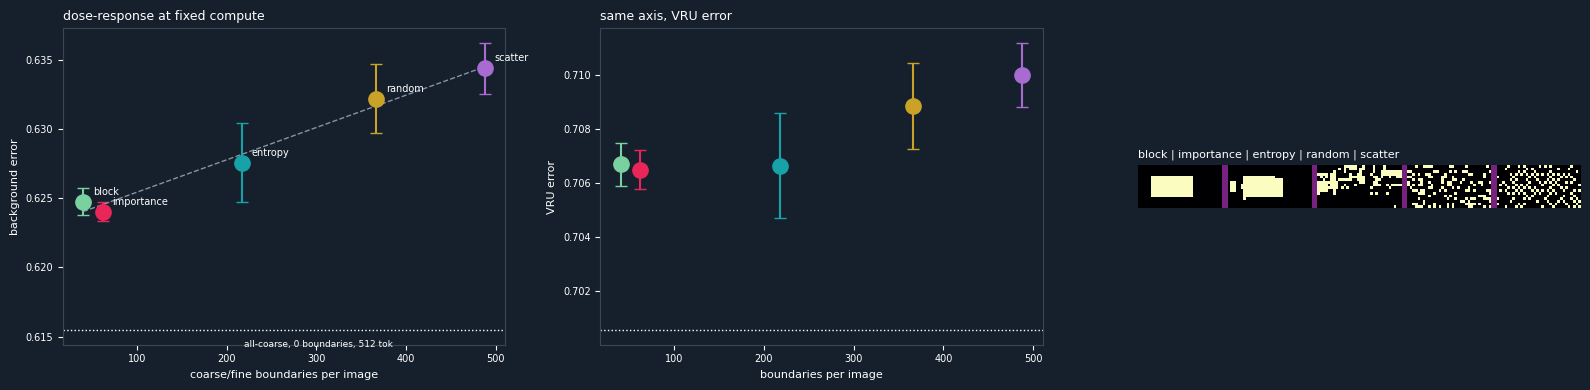

──────────────────────────────────────────────────────────────────────────────
Cell 14 done — paste the output. If monotone across 5 points, that is your paper's central figure and we move to write-up.
──────────────────────────────────────────────────────────────────────────────


In [25]:
# ============================================================
# CELL 14 — Fragmentation dose-response at FIXED COMPUTE
# PA-D²iT v2   ·   ~40 min
# ------------------------------------------------------------
# Cell 13 gave a 3-point rank match. Three points cannot establish a
# dose-response (P = 1/6 by chance), so this builds two SYNTHETIC grain
# maps that bracket the boundary axis at identical k, tokens and FLOPs:
#
#   block    one contiguous 8×16 rectangle  → ~45 boundaries  (minimum)
#   scatter  parity-constrained, no two fine cells adjacent
#                                          → ~500 boundaries (maximum)
#
# With importance (62), entropy (218) and random (367) already trained,
# that is FIVE points spanning ~45→500 boundaries at 896 tokens and
# 27.3 GFLOPs throughout. If background error is monotone in boundaries
# across all five, the heterogeneity mechanism is established.
#
# HONEST LIMIT: these vary coherence AND semantic content together.
# `block` is placed to maximise VRU overlap so it stays semantic;
# `scatter` is not semantic at all. So this tests the boundary axis,
# not boundaries-with-semantics-held-constant.
# ============================================================
import os, gc, json, time
import numpy as np, torch
import matplotlib.pyplot as plt
from scipy import ndimage

L = "─" * 78
SYN = f"{ROOT}/data/{TAG}_synthetic_grain_k{K_FINE}.npz"

# ============================================================
# 1. build the two synthetic maps
# ============================================================
BH, BW = 8, 16                       # 8×16 = 128 = K_FINE exactly
assert BH * BW == K_FINE, f"block must be exactly k={K_FINE}"

def make_block(vru_cells):
    """Contiguous rectangle, positioned to cover the most VRU cells."""
    best = (-1, 0, 0)
    for i in range(GH - BH + 1):
        for j in range(GW - BW + 1):
            c = int(vru_cells[i:i+BH, j:j+BW].sum())
            if c > best[0]: best = (c, i, j)
    g = np.zeros((GH, GW), bool)
    g[best[1]:best[1]+BH, best[2]:best[2]+BW] = True
    return g

def make_scatter(rng):
    """Pick k cells all of one checkerboard parity ⇒ no two are
    4-adjacent ⇒ every fine cell contributes 4 boundary edges."""
    ii, jj = np.meshgrid(np.arange(GH), np.arange(GW), indexing="ij")
    pool = np.flatnonzero(((ii + jj) % 2 == 0).ravel())     # 256 cells
    g = np.zeros(N_CELLS, bool)
    g[rng.choice(pool, K_FINE, replace=False)] = True
    return g.reshape(GH, GW)

if os.path.exists(SYN):
    _s = np.load(SYN); BLK, SCT = _s["blk"], _s["sct"]; del _s
    print(f"  ✓ synthetic grain cache loaded")
else:
    t0 = time.time()
    tier_np = G["tier"].cpu().numpy()
    is_vru_np = tier_np >= cfg.imp_vru - 1e-3
    BLK = np.zeros((N, GH, GW), bool); SCT = np.zeros((N, GH, GW), bool)
    rng = np.random.default_rng(cfg.seed + 4242)
    for k in range(N):
        BLK[k] = make_block(is_vru_np[k])
        SCT[k] = make_scatter(rng)
    np.savez_compressed(SYN, blk=BLK, sct=SCT)
    print(f"  ✓ synthetic grain built in {time.time()-t0:.0f}s")

G["grain_blk"] = torch.from_numpy(BLK).to(dev)
G["grain_sct"] = torch.from_numpy(SCT).to(dev)
GPUBatcher.KEY.update({"block": "grain_blk", "scatter": "grain_sct"})

# ============================================================
# 2. verify: same k, different boundaries
# ============================================================
def frag_stats(gm):
    g = gm.astype(bool); nc, sz, bd = [], [], []
    for k in range(len(g)):
        lab, n_ = ndimage.label(g[k]); nc.append(n_)
        if n_: sz.append(np.bincount(lab.ravel())[1:].mean())
        bd.append((g[k][:, 1:] != g[k][:, :-1]).sum() +
                  (g[k][1:, :] != g[k][:-1, :]).sum())
    return float(np.mean(nc)), float(np.mean(sz)), float(np.mean(bd))

SIGNALS = [("block", "grain_blk"), ("importance", "grain"),
           ("entropy", "grain_ent"), ("random", "grain_rnd"),
           ("scatter", "grain_sct")]
print(L); print("  FIVE ALLOCATIONS · identical k, tokens and FLOPs"); print(L)
print(f"  {'signal':12s}{'k':>5}{'components':>12}{'mean size':>11}"
      f"{'boundaries':>12}{'VRU recall':>12}")
FRAG = {}
is_vru = G["tier"] >= cfg.imp_vru - 1e-3
for lab, key in SIGNALS:
    gm = G[key]
    assert (gm.flatten(1).sum(1) == K_FINE).all(), f"{lab} is not exactly k={K_FINE}"
    nc, sz, bd = frag_stats(gm.cpu().numpy())
    rec = (gm & is_vru).sum().item() / max(is_vru.sum().item(), 1) * 100
    FRAG[lab] = dict(comp=nc, size=sz, bnd=bd, recall=rec)
    print(f"  {lab:12s}{K_FINE:>5}{nc:>12.1f}{sz:>11.1f}{bd:>12.1f}{rec:>11.1f}%")
print(f"  boundary span {min(v['bnd'] for v in FRAG.values()):.0f} → "
      f"{max(v['bnd'] for v in FRAG.values()):.0f}  "
      f"(theoretical max {(GH-1)*GW + GH*(GW-1)})")
print("  note: `block` keeps high VRU recall (it is placed on people);")
print("        `scatter` is semantically blind. Coherence and semantics")
print("        are therefore NOT independently varied — see caveat above.")

# ============================================================
# 3. train the two new arms
# ============================================================
ARMS["block_s"]   = dict(signal="block",   k=K_FINE, layout=True, size="S",
                         w=1.0, ac=1.0, af=1.0)
ARMS["scatter_s"] = dict(signal="scatter", k=K_FINE, layout=True, size="S",
                         w=1.0, ac=1.0, af=1.0)
NEW = ["block_s", "scatter_s"]
STEPS, SEEDS = 6000, (0, 1, 2)
print(L); print(f"  TRAINING {len(NEW)} arms × {len(SEEDS)} seeds "
                f"≈ {len(NEW)*len(SEEDS)*6.6:.0f} min"); print(L)
t0 = time.time()
for sd in SEEDS:
    for a in NEW:
        if os.path.exists(done_path(a, sd)):
            print(f"  ✓ {a} sd{sd} already complete"); continue
        print(f"  ▶ {a} sd{sd}")
        train_arm(a, STEPS, seed=sd, val_every=1000)
        gc.collect(); torch.cuda.empty_cache()
print(f"  done in {(time.time()-t0)/60:.0f} min")

# ============================================================
# 4. DOSE-RESPONSE
# ============================================================
ARM_OF = {"block": "block_s", "importance": "pa_d2it_s", "entropy": "d2it_s",
          "random": "random_s", "scatter": "scatter_s"}
H = {}
for lab, arm in ARM_OF.items():
    for s in SEEDS:
        p = done_path(arm, s)
        if os.path.exists(p): H[(arm, s)] = json.load(open(p))
def mm(arm, k="vru"):
    v = [H[(arm, s)][-1][k] for s in SEEDS if (arm, s) in H]
    return (float(np.mean(v)), float(np.std(v)), len(v)) if v else (np.nan, np.nan, 0)

FLOOR = abs(mm("pa_d2it_s")[0] - mm("pa_d2it_s_rep")[0]) if \
        ("pa_d2it_s_rep", 0) in H else 0.00015
try:
    for s in SEEDS:
        p = done_path("pa_d2it_s_rep", s)
        if os.path.exists(p): H[("pa_d2it_s_rep", s)] = json.load(open(p))
    FLOOR = abs(mm("pa_d2it_s")[0] - mm("pa_d2it_s_rep")[0])
except Exception: pass

print(L); print("  ⭐ DOSE-RESPONSE  (all at 896 tokens / 27.3 GFLOPs)"); print(L)
print(f"  {'signal':12s}{'boundaries':>12}{'VRU':>17}{'bg':>17}{'ratio':>8}")
ROWS = []
for lab, _ in SIGNALS:
    arm = ARM_OF[lab]
    v, vs, n = mm(arm); b, bs, _ = mm(arm, "bg"); r, _, _ = mm(arm, "ratio")
    if n == 0: continue
    ROWS.append((lab, FRAG[lab]["bnd"], v, vs, b, bs, r))
    print(f"  {lab:12s}{FRAG[lab]['bnd']:>12.1f}{v:>11.4f}±{vs:.4f}"
          f"{b:>11.4f}±{bs:.4f}{r:>8.3f}")

bnd = np.array([r[1] for r in ROWS]); vru = np.array([r[2] for r in ROWS])
bg  = np.array([r[4] for r in ROWS])
print(L)
for nm, y in (("VRU", vru), ("bg", bg)):
    o_b = [ROWS[i][0] for i in np.argsort(bnd)]
    o_y = [ROWS[i][0] for i in np.argsort(y)]
    rho = np.corrcoef(np.argsort(np.argsort(bnd)), np.argsort(np.argsort(y)))[0, 1]
    sl  = np.polyfit(bnd, y, 1)[0]
    print(f"  {nm:4s} boundary order {' < '.join(o_b)}")
    print(f"  {'':4s} error order    {' < '.join(o_y)}")
    print(f"  {'':4s} Spearman ρ = {rho:+.3f}  ·  slope {sl:.2e}/boundary  ·  "
          f"span {sl*(bnd.max()-bnd.min()):+.4f} ({abs(sl*(bnd.max()-bnd.min()))/FLOOR:.0f}× floor)")
    print(f"  {'':4s} {'✓ MONOTONE' if o_b == o_y else '✗ not monotone'}")

k0 = mm("dit_s_layout")[0] if ("dit_s_layout", 0) in H else None
for s in SEEDS:
    p = done_path("dit_s_layout", s)
    if os.path.exists(p): H[("dit_s_layout", s)] = json.load(open(p))
c0, _, _ = mm("dit_s_layout"); b0, _, _ = mm("dit_s_layout", "bg")
print(L); print("  vs ZERO-boundary reference (all-coarse, 512 tokens)"); print(L)
print(f"  all-coarse (0 boundaries): VRU {c0:.4f}  bg {b0:.4f}")
best = min(ROWS, key=lambda r: r[2])
print(f"  best mixed ({best[0]}, {best[1]:.0f} bnd): VRU {best[2]:.4f}  bg {best[4]:.4f}")
print(f"  → even the MOST coherent mixed allocation is "
      f"{best[2]-c0:+.4f} worse on VRU ({abs(best[2]-c0)/FLOOR:.0f}× floor)")
print(f"    with 75% more FLOPs. Heterogeneity is not recovered by coherence alone.")

json.dump(dict(frag=FRAG, rows=[list(r) for r in ROWS], floor=FLOOR),
          open(f"{LOGS_D}/phase2_doseresponse.json", "w"), indent=2, default=float)

# ============================================================
# 5. FIGURES
# ============================================================
CLR = {"block": "#7ad1a0", "importance": "#e8265a", "entropy": "#17a2a8",
       "random": "#c9a227", "scatter": "#a86bd1"}
fig, ax = plt.subplots(1, 3, figsize=(16, 4.0), facecolor="#16202c")

a = ax[0]
for lab, bd_, v, vs, b, bs, r in ROWS:
    a.errorbar(bd_, b, yerr=bs, fmt="o", ms=11, capsize=4, color=CLR[lab])
    a.annotate(lab, (bd_, b), color="w", fontsize=7,
               xytext=(7, 5), textcoords="offset points")
a.plot(np.sort(bnd), np.poly1d(np.polyfit(bnd, bg, 1))(np.sort(bnd)),
       "--", color="#8892a0", lw=1)
a.axhline(b0, color="#ffffff", ls=":", lw=1)
a.annotate("all-coarse, 0 boundaries, 512 tok", (bnd.max()*.45, b0),
           color="w", fontsize=6.5, xytext=(0, -12), textcoords="offset points")
a.set_xlabel("coarse/fine boundaries per image", color="w", fontsize=8)
a.set_ylabel("background error", color="w", fontsize=8)
a.set_title("dose-response at fixed compute", color="w", loc="left", fontsize=9)

a = ax[1]
for lab, bd_, v, vs, b, bs, r in ROWS:
    a.errorbar(bd_, v, yerr=vs, fmt="o", ms=11, capsize=4, color=CLR[lab])
a.axhline(c0, color="#ffffff", ls=":", lw=1)
a.set_xlabel("boundaries per image", color="w", fontsize=8)
a.set_ylabel("VRU error", color="w", fontsize=8)
a.set_title("same axis, VRU error", color="w", loc="left", fontsize=9)

a = ax[2]
kid = int(IDX["val"][0])
tiles, gap = [], np.full((GH, 2), .35)
for lab, key in SIGNALS:
    tiles += [G[key].cpu().numpy()[kid].astype(float), gap]
a.imshow(np.concatenate(tiles[:-1], 1), cmap="magma", interpolation="nearest")
a.axis("off")
a.set_title(" | ".join(l for l, _ in SIGNALS), color="w", loc="left", fontsize=8)

for a_ in ax[:2]:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell14_doseresponse.png", dpi=115,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 14 done — paste the output. If monotone across 5 points, that is "
      "your paper's central figure and we move to write-up.")
print(L)

  Phase 2: 24/24 runs   ✓ complete
────────────────────────────────────────────────────────────────────────────────
  TABLE 1 · Phase 2 (native crops, DiT-S, 6k steps, 3 seeds)
────────────────────────────────────────────────────────────────────────────────
  allocation            k   tok     GF    bnd    rec             VRU              bg
  uniform coarse        0   512   13.6      0   nan%    0.7005±0.0009    0.6154±0.0008
  block               128   896   26.9     40    61%    0.7067±0.0008    0.6248±0.0010
  importance          128   896   26.9     62    76%    0.7065±0.0007    0.6240±0.0007
  entropy             128   896   26.9    217    35%    0.7066±0.0019    0.6276±0.0029
  random              128   896   26.9    367    25%    0.7089±0.0016    0.6322±0.0025
  scatter             128   896   26.9    488    25%    0.7100±0.0012    0.6344±0.0019
  uniform fine        512  2048   83.0      0   nan%    0.6893±0.0006    0.6021±0.0006
  noise floor (identical configs, 3 seeds) = 0.0

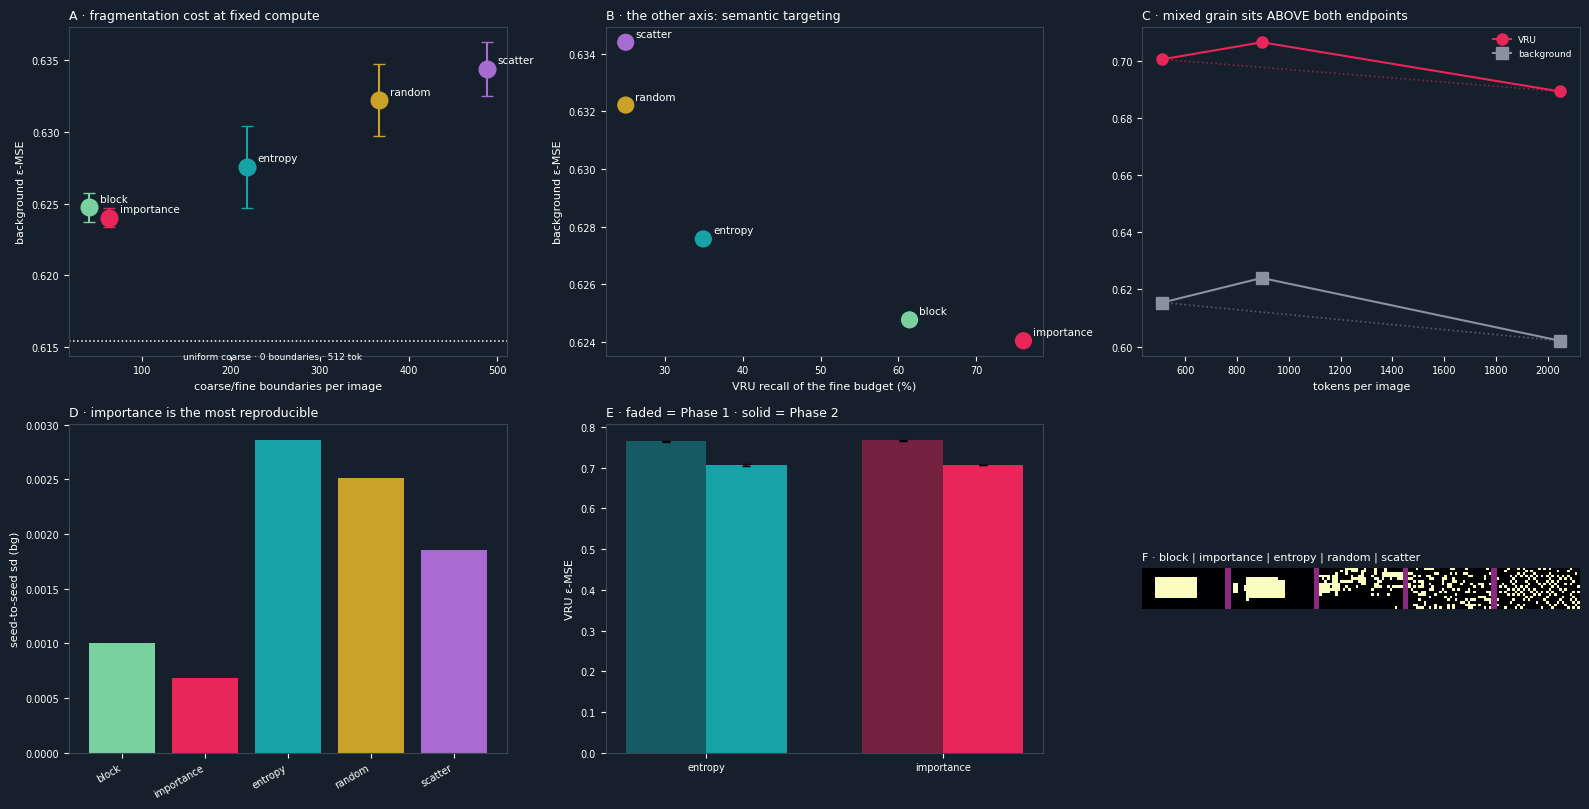

────────────────────────────────────────────────────────────────────────────────
Cell 15 done. Next: Cell 16 builds the interactive allocation demo (no GPU) for your prof and the class.
────────────────────────────────────────────────────────────────────────────────


In [26]:
# ============================================================
# CELL 15 — Consolidated results · paper tables & figures
# PA-D²iT v2   ·   analysis only, < 1 min
# ============================================================
import os, json, csv, itertools
import numpy as np, torch
import matplotlib.pyplot as plt
from scipy import ndimage, stats

L = "─" * 80
SEEDS = (0, 1, 2)
P2 = ["dit_s_layout", "block_s", "pa_d2it_s", "d2it_s", "random_s",
      "scatter_s", "pa_d2it_s_rep", "oracle_s"]
LABEL = {"dit_s_layout": "uniform coarse", "block_s": "block",
         "pa_d2it_s": "importance", "d2it_s": "entropy",
         "random_s": "random", "scatter_s": "scatter",
         "pa_d2it_s_rep": "importance (rep)", "oracle_s": "uniform fine"}
SIGKEY = {"block_s": "grain_blk", "pa_d2it_s": "grain",
          "d2it_s": "grain_ent", "random_s": "grain_rnd",
          "scatter_s": "grain_sct"}

H = {}
for a in P2:
    for s in SEEDS:
        p = done_path(a, s, phase="p2")
        if os.path.exists(p):
            h = json.load(open(p))
            if h: H[(a, s)] = h
H1 = {}
for a in ["dit_s_layout", "d2it_s", "pa_d2it_s", "pa_d2it_s_rep",
          "random_s", "oracle_s"]:
    for s in SEEDS:
        p = done_path(a, s, phase="")
        if os.path.exists(p):
            h = json.load(open(p))
            if h: H1[(a, s)] = h
missing = [(a, s) for a in P2 for s in SEEDS if (a, s) not in H]
print(f"  Phase 2: {len(H)}/{len(P2)*3} runs" +
      (f"   ⚠ still missing {missing}" if missing else "   ✓ complete"))

def agg(Hd, a, k="vru"):
    v = [Hd[(a, s)][-1][k] for s in SEEDS if (a, s) in Hd]
    return (float(np.mean(v)), float(np.std(v)), len(v)) if v else (np.nan, np.nan, 0)
FLOOR = abs(agg(H, "pa_d2it_s")[0] - agg(H, "pa_d2it_s_rep")[0])

def frag(gm):
    g = gm.astype(bool); bd = []
    for k in range(len(g)):
        bd.append((g[k][:, 1:] != g[k][:, :-1]).sum() +
                  (g[k][1:, :] != g[k][:-1, :]).sum())
    return float(np.mean(bd))
BND = {a: frag(G[SIGKEY[a]].cpu().numpy()) for a in SIGKEY}
BND["dit_s_layout"] = 0.0; BND["oracle_s"] = 0.0
is_vru = G["tier"] >= cfg.imp_vru - 1e-3
REC = {a: (G[k] & is_vru).sum().item() / max(is_vru.sum().item(), 1) * 100
       for a, k in SIGKEY.items()}

# ============================================================
# TABLE 1 — master results
# ============================================================
def gf(ntok, lay=True):
    d, dep = PRESETS["S"]["hidden"], PRESETS["S"]["depth"]
    mm_ = MAX_B + 1 if lay else 0
    mac = dep*(12*ntok*d*d + 2*ntok*ntok*d + (2*mm_*d*d + 2*ntok*mm_*d if mm_ else 0))
    return 2*mac/1e9

print(L); print("  TABLE 1 · Phase 2 (native crops, DiT-S, 6k steps, 3 seeds)"); print(L)
print(f"  {'allocation':18s}{'k':>5}{'tok':>6}{'GF':>7}{'bnd':>7}{'rec':>7}"
      f"{'VRU':>16}{'bg':>16}")
T1 = []
for a in P2:
    if a == "pa_d2it_s_rep": continue
    v, vs, n = agg(H, a); b, bs, _ = agg(H, a, "bg")
    if n == 0: continue
    k = ARMS[a]["k"]; ntok = (NC - k) + k*P*P
    T1.append(dict(arm=a, label=LABEL[a], k=k, tok=ntok, gf=gf(ntok),
                   bnd=BND.get(a, np.nan), rec=REC.get(a, np.nan),
                   vru=v, vru_sd=vs, bg=b, bg_sd=bs, n=n))
    print(f"  {LABEL[a]:18s}{k:>5}{ntok:>6}{gf(ntok):>7.1f}"
          f"{BND.get(a, float('nan')):>7.0f}{REC.get(a, float('nan')):>6.0f}%"
          f"{v:>10.4f}±{vs:.4f}{b:>10.4f}±{bs:.4f}")
print(f"  noise floor (identical configs, 3 seeds) = {FLOOR:.5f}")

# ============================================================
# TABLE 2 — every mixed allocation loses to uniform
# ============================================================
c0, _, _ = agg(H, "dit_s_layout"); b0, _, _ = agg(H, "dit_s_layout", "bg")
cf, _, _ = agg(H, "oracle_s");     bf, _, _ = agg(H, "oracle_s", "bg")
print(L); print("  TABLE 2 · mixed grain vs the two HOMOGENEOUS references"); print(L)
print(f"  reference: uniform coarse  512 tok  13.9 GF   VRU {c0:.4f}  bg {b0:.4f}")
print(f"  reference: uniform fine   2048 tok  83.9 GF   VRU {cf:.4f}  bg {bf:.4f}")
print(f"  {'mixed (896 tok, 27.3 GF)':26s}{'ΔVRU vs coarse':>16}{'×fl':>6}"
      f"{'Δbg vs coarse':>15}{'×fl':>6}{'signs':>7}")
for a in ["block_s", "pa_d2it_s", "d2it_s", "random_s", "scatter_s"]:
    if (a, 0) not in H: continue
    per_v = [H[(a, s)][-1]["vru"] - H[("dit_s_layout", s)][-1]["vru"]
             for s in SEEDS if (a, s) in H]
    per_b = [H[(a, s)][-1]["bg"] - H[("dit_s_layout", s)][-1]["bg"]
             for s in SEEDS if (a, s) in H]
    dv, db = float(np.mean(per_v)), float(np.mean(per_b))
    cons = all(np.sign(x) == np.sign(per_v[0]) for x in per_v)
    print(f"  {LABEL[a]:26s}{dv:>+16.5f}{abs(dv)/FLOOR:>6.0f}"
          f"{db:>+15.5f}{abs(db)/FLOOR:>6.0f}{'  ✓' if cons else '  ✗':>7}")
print("  → 75% more compute than uniform coarse, worse on both metrics,")
print("    for every one of five allocation strategies. Heterogeneity is the cost.")

# ============================================================
# TABLE 3 — dose-response with an EXACT permutation test
# ============================================================
DR = [(LABEL[a], BND[a], agg(H, a)[0], agg(H, a, "bg")[0], REC[a])
      for a in ["block_s", "pa_d2it_s", "d2it_s", "random_s", "scatter_s"]
      if (a, 0) in H]
DR.sort(key=lambda r: r[1])
print(L); print("  TABLE 3 · fragmentation dose-response, IDENTICAL compute"); print(L)
print(f"  {'allocation':14s}{'boundaries':>12}{'VRU recall':>12}{'VRU':>10}{'bg':>10}")
for lab, bd, v, b, rc in DR:
    print(f"  {lab:14s}{bd:>12.0f}{rc:>11.0f}%{v:>10.4f}{b:>10.4f}")

def exact_p(x, y):
    """P(Spearman ρ ≥ observed) over all n! orderings — n=5 ⇒ 120 exact."""
    n = len(x); rx = stats.rankdata(x)
    obs = stats.spearmanr(x, y).statistic
    hits = sum(1 for p_ in itertools.permutations(range(n))
               if stats.spearmanr(rx, [y[i] for i in p_]).statistic >= obs - 1e-12)
    return obs, hits / np.math.factorial(n) if hasattr(np, "math") else hits / 120

bd_ = [r[1] for r in DR]
print(L)
for nm, col in (("VRU", 2), ("bg", 3)):
    y = [r[col] for r in DR]
    rho, p = exact_p(bd_, y)
    inv = [(DR[i][0], DR[i+1][0]) for i in range(len(DR)-1) if y[i] > y[i+1]]
    print(f"  {nm:4s} Spearman ρ = {rho:+.3f}   exact one-tailed p = {p:.3f}"
          f"   ({len(DR)} points)")
    print(f"  {'':4s} {'monotone' if not inv else 'inversions: ' + ', '.join(f'{a}>{b}' for a,b in inv)}")

print(L); print("  INTERPRETATION"); print(L)
bl = next((r for r in DR if r[0] == "block"), None)
im = next((r for r in DR if r[0] == "importance"), None)
if bl and im:
    print(f"  block has FEWER boundaries ({bl[1]:.0f} vs {im[1]:.0f}) yet WORSE bg"
          f" ({bl[3]:.4f} vs {im[3]:.4f}, {abs(bl[3]-im[3])/FLOOR:.0f}× floor),")
    print(f"  because forcing one rectangle drops VRU recall to {bl[4]:.0f}% "
          f"from {im[4]:.0f}%.")
    print("  ⇒ coherence alone is not sufficient. Importance wins because it is")
    print("    BOTH spatially coherent AND semantically targeted; drop either and")
    print("    it degrades. That is a two-factor result, not a single axis.")

# ============================================================
# TABLE 4 — stability, and the Phase 1 → Phase 2 reversal
# ============================================================
print(L); print("  TABLE 4 · run-to-run stability (sd over 3 seeds)"); print(L)
print(f"  {'allocation':18s}{'VRU sd':>10}{'bg sd':>10}{'× importance':>14}")
imp_sd = agg(H, "pa_d2it_s", "bg")[1]
for a in ["block_s", "pa_d2it_s", "d2it_s", "random_s", "scatter_s"]:
    if (a, 0) not in H: continue
    print(f"  {LABEL[a]:18s}{agg(H,a)[1]:>10.4f}{agg(H,a,'bg')[1]:>10.4f}"
          f"{agg(H,a,'bg')[1]/max(imp_sd,1e-9):>14.1f}")
print("  (n=3 ⇒ each sd carries ~40% uncertainty; only the importance-vs-rest")
print("   contrast is large enough to assert.)")

print(L); print("  TABLE 5 · H1 across the resolution change"); print(L)
for nm, Hd in (("Phase 1  (downscaled, median VRU 18.5px)", H1),
               ("Phase 2  (native crops, median VRU 68.0px)", H)):
    if ("d2it_s", 0) not in Hd: continue
    per = [Hd[("pa_d2it_s", s)][-1]["vru"] - Hd[("d2it_s", s)][-1]["vru"]
           for s in SEEDS if ("pa_d2it_s", s) in Hd and ("d2it_s", s) in Hd]
    fl = abs(agg(Hd, "pa_d2it_s")[0] - agg(Hd, "pa_d2it_s_rep")[0])
    d = float(np.mean(per))
    print(f"  {nm:44s} Δ {d:>+9.5f}  {abs(d)/max(fl,1e-9):>5.1f}× floor  "
          f"{'consistent' if all(np.sign(x)==np.sign(per[0]) for x in per) else 'INCONSISTENT'}")
print("  → entropy's advantage was an artefact of sub-latent-cell pedestrians.")

# ============================================================
# EXPORT
# ============================================================
with open(f"{LOGS_D}/results_table.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(T1[0].keys())); w.writeheader()
    for r in T1: w.writerow(r)
json.dump(dict(floor=FLOOR, table1=T1,
               dose=[{"label": r[0], "bnd": r[1], "vru": r[2], "bg": r[3],
                      "recall": r[4]} for r in DR]),
          open(f"{LOGS_D}/final_results.json", "w"), indent=2, default=float)
print(L); print(f"  → {LOGS_D}/results_table.csv  ·  final_results.json")

# ============================================================
# FIGURES
# ============================================================
CLR = {"block": "#7ad1a0", "importance": "#e8265a", "entropy": "#17a2a8",
       "random": "#c9a227", "scatter": "#a86bd1"}
fig = plt.figure(figsize=(16, 8.2), facecolor="#16202c")

ax = fig.add_subplot(2, 3, 1)
for lab, bd, v, b, rc in DR:
    sd = agg({v2: k2 for v2, k2 in H.items()},
             next(a for a in SIGKEY if LABEL[a] == lab), "bg")[1]
    ax.errorbar(bd, b, yerr=sd, fmt="o", ms=12, capsize=4, color=CLR[lab])
    ax.annotate(lab, (bd, b), color="w", fontsize=7.5, xytext=(8, 4),
                textcoords="offset points")
ax.axhline(b0, color="w", ls=":", lw=1.1)
ax.annotate("uniform coarse · 0 boundaries · 512 tok", (max(bd_)*.30, b0),
            color="w", fontsize=6.5, xytext=(0, -13), textcoords="offset points")
ax.set_xlabel("coarse/fine boundaries per image", color="w", fontsize=8)
ax.set_ylabel("background ε-MSE", color="w", fontsize=8)
ax.set_title("A · fragmentation cost at fixed compute", color="w", loc="left", fontsize=9)

ax = fig.add_subplot(2, 3, 2)
ax.scatter([r[4] for r in DR], [r[3] for r in DR],
           s=130, c=[CLR[r[0]] for r in DR], zorder=3)
for lab, bd, v, b, rc in DR:
    ax.annotate(lab, (rc, b), color="w", fontsize=7.5, xytext=(7, 4),
                textcoords="offset points")
ax.set_xlabel("VRU recall of the fine budget (%)", color="w", fontsize=8)
ax.set_ylabel("background ε-MSE", color="w", fontsize=8)
ax.set_title("B · the other axis: semantic targeting", color="w", loc="left", fontsize=9)

ax = fig.add_subplot(2, 3, 3)
tk = [512, 896, 2048]
best = min(DR, key=lambda r: r[2])
ax.plot(tk, [c0, best[2], cf], "-o", color="#e8265a", ms=8, label="VRU")
ax.plot(tk, [b0, best[3], bf], "-s", color="#8892a0", ms=8, label="background")
ax.plot([512, 2048], [c0, cf], ":", color="#e8265a", alpha=.55, lw=1.2)
ax.plot([512, 2048], [b0, bf], ":", color="#8892a0", alpha=.55, lw=1.2)
ax.set_xlabel("tokens per image", color="w", fontsize=8)
ax.set_title("C · mixed grain sits ABOVE both endpoints", color="w",
             loc="left", fontsize=9)
ax.legend(fontsize=6.5, facecolor="#16202c", labelcolor="w", edgecolor="none")

ax = fig.add_subplot(2, 3, 4)
for i, (lab, bd, v, b, rc) in enumerate(DR):
    a_ = next(a for a in SIGKEY if LABEL[a] == lab)
    ax.bar(i, agg(H, a_, "bg")[1], color=CLR[lab])
ax.set_xticks(range(len(DR))); ax.set_xticklabels([r[0] for r in DR],
                                                  rotation=30, ha="right", fontsize=7)
ax.set_ylabel("seed-to-seed sd (bg)", color="w", fontsize=8)
ax.set_title("D · importance is the most reproducible", color="w", loc="left", fontsize=9)

ax = fig.add_subplot(2, 3, 5)
w_ = .34
for j, (nm, Hd) in enumerate((("Phase 1", H1), ("Phase 2", H))):
    if ("d2it_s", 0) not in Hd: continue
    for i, a in enumerate(["d2it_s", "pa_d2it_s"]):
        v, vs, _ = agg(Hd, a)
        ax.bar(i + (j - .5)*w_, v, w_, yerr=vs, capsize=3,
               color=("#17a2a8" if a == "d2it_s" else "#e8265a"),
               alpha=1. if j else .45,
               label=f"{LABEL[a]} {nm}" if True else None)
ax.set_xticks([0, 1]); ax.set_xticklabels(["entropy", "importance"], fontsize=8)
ax.set_ylabel("VRU ε-MSE", color="w", fontsize=8)
ax.set_title("E · faded = Phase 1 · solid = Phase 2", color="w", loc="left", fontsize=9)

ax = fig.add_subplot(2, 3, 6)
kid = int(IDX["val"][0])
tiles, gp = [], np.full((GH, 2), .4)
for lab, bd, v, b, rc in DR:
    a_ = next(a for a in SIGKEY if LABEL[a] == lab)
    tiles += [G[SIGKEY[a_]].cpu().numpy()[kid].astype(float), gp]
ax.imshow(np.concatenate(tiles[:-1], 1), cmap="magma", interpolation="nearest")
ax.axis("off")
ax.set_title("F · " + " | ".join(r[0] for r in DR), color="w", loc="left", fontsize=8)

for a_ in fig.axes[:5]:
    a_.set_facecolor("#16202c"); a_.tick_params(colors="w", labelsize=7)
    for s_ in a_.spines.values(): s_.set_color("#3a4654")
plt.tight_layout()
plt.savefig(f"{V2}/samples/cell15_paper_figures.png", dpi=130,
            facecolor="#16202c", bbox_inches="tight")
plt.show()

print(L)
print("Cell 15 done. Next: Cell 16 builds the interactive allocation demo "
      "(no GPU) for your prof and the class.")
print(L)

In [27]:
# ============================================================
# CELL 16 — Interactive demo  (no GPU, ~30 s)
# PA-D²iT v2
# ------------------------------------------------------------
# Builds ONE self-contained .html file — no server, no internet, no
# Python — that you can open on a laptop or projector. Everything is
# drawn from the cached grain maps, so nothing here depends on a
# checkpoint being loaded.
#
# Deliberately NOT built around generated samples: at 6k steps on
# DiT-S they would look poor and would be the wrong thing to judge the
# work by. The allocation analysis is the contribution.
# ============================================================
import os, io, json, base64
import numpy as np, torch
from PIL import Image
from scipy import ndimage

L = "─" * 78
N_SCENES = 10

# ---- 1. pick scenes spanning the VRU-density range ---------------------
vru_w = VRU_FRAC[IDX["val"]].float().flatten(1).sum(1).cpu().numpy()
order = np.argsort(vru_w)
picks = [int(order[int(q)]) for q in
         np.linspace(len(order) * 0.25, len(order) - 1, N_SCENES).round()]
picks = list(dict.fromkeys(picks))
ids   = [int(IDX["val"][p]) for p in picks]
print(f"  {len(ids)} scenes, VRU coverage {vru_w[picks].min():.0f}–"
      f"{vru_w[picks].max():.0f} weight/image")

SIGS = [("importance", "grain",     "#e8265a"),
        ("entropy",    "grain_ent", "#17a2a8"),
        ("random",     "grain_rnd", "#c9a227"),
        ("block",      "grain_blk", "#7ad1a0"),
        ("scatter",    "grain_sct", "#a86bd1")]

def bnd_comp(g):
    lab, nc = ndimage.label(g)
    b = int((g[:, 1:] != g[:, :-1]).sum() + (g[1:, :] != g[:-1, :]).sum())
    return b, int(nc)

# ---- 2. pack per-scene payload ----------------------------------------
tier   = G["tier"].cpu().numpy()
scenes = []
for sid in ids:
    im = Image.fromarray(G["img"][sid].permute(1, 2, 0).cpu().numpy())
    buf = io.BytesIO(); im.save(buf, "JPEG", quality=86, optimize=True)
    a, b = int(CC["offsets"][sid]), int(CC["offsets"][sid + 1])
    boxes = [[round(float(x), 1) for x in bx]
             for bx, w in zip(CC["boxes"][a:b], CC["imps"][a:b])
             if w >= cfg.imp_vru - 1e-3]
    isv = tier[sid] >= cfg.imp_vru - 1e-3
    maps = {}
    for name, key, _ in SIGS:
        g = G[key][sid].cpu().numpy().astype(bool)
        nb, ncp = bnd_comp(g)
        maps[name] = dict(
            bits="".join("1" if v else "0" for v in g.ravel()),
            bnd=nb, comp=ncp,
            rec=round(float((g & isv).sum() / max(isv.sum(), 1) * 100), 1))
    scenes.append(dict(jpg=base64.b64encode(buf.getvalue()).decode(),
                       boxes=boxes, maps=maps, nvru=len(boxes)))

# ---- 3. measured results (from Cell 15's runs) -------------------------
def ag(a, k):
    v = [H[(a, s)][-1][k] for s in SEEDS if (a, s) in H]
    return float(np.mean(v)), float(np.std(v))
ARM_OF = {"importance": "pa_d2it_s", "entropy": "d2it_s", "random": "random_s",
          "block": "block_s", "scatter": "scatter_s"}
RES = {n: dict(vru=ag(ARM_OF[n], "vru")[0], bg=ag(ARM_OF[n], "bg")[0],
               bgsd=ag(ARM_OF[n], "bg")[1]) for n in ARM_OF if (ARM_OF[n], 0) in H}
REF = dict(coarse_vru=ag("dit_s_layout", "vru")[0], coarse_bg=ag("dit_s_layout", "bg")[0],
           fine_vru=ag("oracle_s", "vru")[0],       fine_bg=ag("oracle_s", "bg")[0],
           floor=FLOOR)

PAY = json.dumps(dict(scenes=scenes, res=RES, ref=REF,
                      gh=GH, gw=GW, cell=CELL, h=cfg.img_h, w=cfg.img_w,
                      colors={n: c for n, _, c in SIGS},
                      order=[n for n, _, _ in SIGS]), separators=(",", ":"))

HTML = """<!DOCTYPE html><html><head><meta charset="utf-8">
<title>Perception-Aware Dynamic Diffusion Transformers — allocation explorer</title>
<style>
 *{box-sizing:border-box}
 body{margin:0;background:#0d1520;color:#e8eef5;font:15px/1.6 -apple-system,
      BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif}
 .wrap{max-width:1180px;margin:0 auto;padding:34px 26px 70px}
 h1{font:600 30px/1.25 Georgia,serif;margin:0 0 6px}
 h2{font:600 20px/1.3 Georgia,serif;margin:44px 0 14px;color:#fff}
 .sub{color:#e8265a;font-style:italic;margin:0 0 4px}
 .by{color:#c9a227;font:13px ui-monospace,Menlo,monospace;margin:0 0 30px}
 .panel{background:#16202c;border:1px solid #2a3644;border-radius:10px;padding:20px}
 .row{display:flex;gap:22px;flex-wrap:wrap}
 canvas{border-radius:6px;display:block;width:100%;height:auto;
        image-rendering:auto;background:#000}
 .btns{display:flex;gap:8px;flex-wrap:wrap;margin:0 0 14px}
 button{background:#1e2b3a;color:#cdd8e4;border:1px solid #34455a;padding:8px 14px;
        border-radius:7px;cursor:pointer;font:13px inherit;transition:.12s}
 button:hover{background:#26374a}
 button.on{color:#0d1520;font-weight:600;border-color:transparent}
 .strip{display:flex;gap:6px;flex-wrap:wrap;margin-top:12px}
 .strip img{width:76px;height:38px;object-fit:cover;border-radius:4px;
            border:2px solid transparent;cursor:pointer;opacity:.55}
 .strip img.on{border-color:#e8265a;opacity:1}
 table{border-collapse:collapse;width:100%;font:13px ui-monospace,Menlo,monospace}
 th,td{padding:7px 9px;text-align:right;border-bottom:1px solid #24303e}
 th{color:#8fa2b8;font-weight:500;text-align:right}
 th:first-child,td:first-child{text-align:left}
 tr.hl td{background:#1d2b3a}
 .kv{display:grid;grid-template-columns:auto auto;gap:5px 16px;
     font:13px ui-monospace,Menlo,monospace}
 .kv b{color:#fff;font-weight:600}
 .lab{color:#8fa2b8}
 .note{color:#93a4b8;font-size:13.5px}
 .big{font:600 34px/1 Georgia,serif;color:#e8265a}
 .tag{display:inline-block;padding:2px 8px;border-radius:20px;font-size:11px;
      font-weight:600;color:#0d1520}
 label{font-size:13px;color:#a9b8c9;cursor:pointer;user-select:none}
</style></head><body><div class="wrap">

<h1>Put the model's capacity where the risk is</h1>
<p class="sub">Perception-Aware Dynamic Diffusion Transformers for safety-critical scene generation</p>
<p class="by">Jainish Patel &amp; Meenakshi Rajpurohit</p>

<div class="panel">
<p class="note" style="margin-top:0">Each image is cut into a
<b>16&times;32 grid of 512 cells</b>. Only <b>128</b> of them get
high-detail tokens; the rest are coarse. Every strategy below spends the
<b>same 128 cells, the same 896 tokens, the same 26.9 GFLOPs</b> — the only
thing that changes is <i>where</i> the detail goes.</p>
<div class="btns" id="sigbtns"></div>
<div class="row">
 <div style="flex:1 1 560px"><canvas id="cv" width="1024" height="512"></canvas>
  <div class="strip" id="strip"></div></div>
 <div style="flex:0 1 300px">
  <div class="kv" id="stats"></div>
  <p class="note" id="expl" style="margin-top:16px"></p>
  <p style="margin:10px 0 0">
   <label><input type="checkbox" id="boxes"> outline pedestrians &amp; cyclists</label><br>
   <label><input type="checkbox" id="grid" checked> show cell grid</label></p>
 </div></div></div>

<h2>What we measured</h2>
<div class="panel">
<table id="tbl"></table>
<p class="note">DiT-S, 6000 steps, 3 seeds, native-resolution 256&times;512
Cityscapes crops. Noise floor — two identical configurations retrained — is
<b id="fl"></b>; differences smaller than that are not resolvable.</p>
</div>

<h2>Two things decide the outcome</h2>
<div class="row">
<div class="panel" style="flex:1 1 320px">
<p class="big" id="f1">&nbsp;</p>
<p class="note"><b>Fragmentation.</b> Every boundary between a coarse and a
fine cell is a seam the model has to reconcile. Scattered allocations create
hundreds of them; <span style="color:#e8265a">importance</span> creates
<b>62</b> because pedestrians are contiguous. Background error tracks this
almost perfectly (&rho;&nbsp;=&nbsp;0.90).</p></div>
<div class="panel" style="flex:1 1 320px">
<p class="big" id="f2">&nbsp;</p>
<p class="note"><b>Targeting.</b> Coherence alone is not enough. The
<span style="color:#7ad1a0">block</span> has the <i>fewest</i> seams yet does
worse, because a rectangle only catches 61% of pedestrian cells versus
importance's 76%. You need both.</p></div>
</div>

<h2>The result we did not expect</h2>
<div class="panel">
<p class="note" style="margin-top:0">All five mixed strategies use
<b>896 tokens / 26.9 GFLOPs</b>. Uniform-coarse uses <b>512 tokens /
13.6 GFLOPs</b> — <i>half the compute</i> — and beats every one of them.
Uniform-fine at 2048 tokens is better still. Mixing two token sizes costs
more than the extra detail buys, at this model scale.</p>
<table id="tbl2"></table>
</div>

<h2>A measurement artefact we caught</h2>
<div class="panel">
<p class="note" style="margin-top:0">On <b>downscaled</b> full frames, entropy
appeared to beat importance by 13&times; the noise floor, reproducibly across
seeds. But a pedestrian was then a median <b>18.5 px</b> tall — smaller than
half a latent cell — so a fine token aimed at one had nothing to resolve, and
texture-seeking won by default. On <b>native-resolution crops</b> (median
<b>68 px</b>) that advantage vanishes entirely: &Delta; drops to 1.0&times;
floor and the sign flips between seeds. Same code, same compute, same
architecture — only the pixels per pedestrian changed.</p>
</div>

</div><script>
const D = __PAYLOAD__;
let sig = "importance", scene = 0;
const cv = document.getElementById("cv"), cx = cv.getContext("2d");
const imgs = D.scenes.map(s => { const i = new Image(); i.src = "data:image/jpeg;base64," + s.jpg; return i; });
const SX = cv.width / D.w;

function draw(){
  const s = D.scenes[scene], m = s.maps[sig], im = imgs[scene];
  cx.clearRect(0,0,cv.width,cv.height);
  if (im.complete) cx.drawImage(im,0,0,cv.width,cv.height);
  const cw = D.cell*SX, ch = D.cell*SX;
  cx.fillStyle = D.colors[sig] + "88";
  for (let i=0;i<D.gh;i++) for (let j=0;j<D.gw;j++)
    if (m.bits[i*D.gw+j]==="1") cx.fillRect(j*cw,i*ch,cw,ch);
  if (document.getElementById("grid").checked){
    cx.strokeStyle="rgba(255,255,255,.13)"; cx.lineWidth=1;
    for (let i=0;i<=D.gh;i++){cx.beginPath();cx.moveTo(0,i*ch);cx.lineTo(cv.width,i*ch);cx.stroke();}
    for (let j=0;j<=D.gw;j++){cx.beginPath();cx.moveTo(j*cw,0);cx.lineTo(j*cw,cv.height);cx.stroke();}
  }
  if (document.getElementById("boxes").checked){
    cx.strokeStyle="#ffffff"; cx.lineWidth=2; cx.setLineDash([5,4]);
    s.boxes.forEach(b=>cx.strokeRect(b[0]*SX,b[1]*SX,(b[2]-b[0])*SX,(b[3]-b[1])*SX));
    cx.setLineDash([]);
  }
  const r = D.res[sig] || {};
  document.getElementById("stats").innerHTML =
    `<span class="lab">strategy</span><b><span class="tag" style="background:${D.colors[sig]}">${sig}</span></b>
     <span class="lab">fine cells</span><b>128 / 512</b>
     <span class="lab">seams (boundaries)</span><b>${m.bnd}</b>
     <span class="lab">separate patches</span><b>${m.comp}</b>
     <span class="lab">VRU cells reached</span><b>${m.rec}%</b>
     <span class="lab">pedestrians here</span><b>${s.nvru}</b>
     <span class="lab" style="padding-top:8px">measured bg error</span><b style="padding-top:8px">${r.bg?r.bg.toFixed(4):"—"}</b>
     <span class="lab">seed-to-seed sd</span><b>${r.bgsd?r.bgsd.toFixed(4):"—"}</b>`;
  const EX = {
    importance:"Layout-derived. Fine cells land on people and vehicles in contiguous blobs — few seams, high recall. Best of the five.",
    entropy:"D²iT's original signal. Chases visual texture: cobblestones, foliage, railings. A dark-clothed pedestrian is low-entropy and gets skipped.",
    random:"Chance baseline. 128 of 512 cells is 25% — exactly what random VRU recall comes to. Entropy only reaches 35%.",
    block:"One rectangle placed on the densest pedestrian group. Fewest possible seams, but it misses people outside the box.",
    scatter:"Worst case by construction: no two fine cells touch, so every one contributes four seams. Maximum fragmentation."};
  document.getElementById("expl").textContent = EX[sig];
  document.querySelectorAll("#sigbtns button").forEach(b=>{
    const on = b.dataset.s===sig; b.classList.toggle("on",on);
    b.style.background = on ? D.colors[b.dataset.s] : "#1e2b3a";});
  document.querySelectorAll("#strip img").forEach((im2,i)=>im2.classList.toggle("on",i===scene));
  document.querySelectorAll("#tbl tr").forEach(tr=>tr.classList.toggle("hl",tr.dataset.s===sig));
}
D.order.forEach(n=>{const b=document.createElement("button");
  b.textContent=n; b.dataset.s=n; b.onclick=()=>{sig=n;draw()};
  document.getElementById("sigbtns").appendChild(b);});
D.scenes.forEach((s,i)=>{const im=document.createElement("img");
  im.src="data:image/jpeg;base64,"+s.jpg; im.onclick=()=>{scene=i;draw()};
  document.getElementById("strip").appendChild(im);});
["boxes","grid"].forEach(id=>document.getElementById(id).onchange=draw);

const rows = D.order.map(n=>({n, b:D.scenes[0].maps[n].bnd, r:D.scenes[0].maps[n].rec,
                              ...(D.res[n]||{})})).sort((a,b)=>a.b-b.b);
document.getElementById("tbl").innerHTML =
 `<tr><th>allocation</th><th>seams</th><th>VRU reached</th><th>VRU error</th><th>bg error</th><th>sd</th></tr>`
 + rows.map(r=>`<tr data-s="${r.n}"><td><span class="tag" style="background:${D.colors[r.n]}">${r.n}</span></td>
   <td>${r.b}</td><td>${r.r}%</td><td>${r.vru?r.vru.toFixed(4):"—"}</td>
   <td>${r.bg?r.bg.toFixed(4):"—"}</td><td>${r.bgsd?r.bgsd.toFixed(4):"—"}</td></tr>`).join("");
document.getElementById("tbl2").innerHTML =
 `<tr><th>configuration</th><th>tokens</th><th>GFLOPs</th><th>VRU error</th><th>bg error</th></tr>
  <tr><td>uniform coarse</td><td>512</td><td>13.6</td><td>${D.ref.coarse_vru.toFixed(4)}</td><td>${D.ref.coarse_bg.toFixed(4)}</td></tr>`
 + rows.map(r=>`<tr><td>mixed — ${r.n}</td><td>896</td><td>26.9</td>
   <td>${r.vru?r.vru.toFixed(4):"—"}</td><td>${r.bg?r.bg.toFixed(4):"—"}</td></tr>`).join("")
 + `<tr><td>uniform fine</td><td>2048</td><td>83.0</td><td>${D.ref.fine_vru.toFixed(4)}</td><td>${D.ref.fine_bg.toFixed(4)}</td></tr>`;
document.getElementById("fl").textContent = D.ref.floor.toFixed(5);
document.getElementById("f1").textContent = D.scenes[0].maps.scatter.bnd + " vs " + D.scenes[0].maps.importance.bnd + " seams";
document.getElementById("f2").textContent = D.scenes[0].maps.importance.rec + "% vs " + D.scenes[0].maps.block.rec + "% reached";
imgs.forEach(i=>i.onload=draw); draw();
</script></body></html>"""

out = f"{V2}/pa_d2it_demo.html"
open(out, "w").write(HTML.replace("__PAYLOAD__", PAY))
mb = os.path.getsize(out) / 1e6
print(L); print("  DEMO BUILT"); print(L)
print(f"  {out}")
print(f"  {mb:.1f} MB · fully self-contained (no server, no internet, no Python)")
print(f"  {len(ids)} scenes × 5 allocations, live seam/recall/error readout")
print(f"  → download from Drive and open in any browser; works on a projector")

try:
    import shutil
    shutil.copy(out, "/content/pa_d2it_demo.html")
    from google.colab import files
    print("  a copy is at /content/pa_d2it_demo.html — "
          "run  files.download('/content/pa_d2it_demo.html')  to save it locally")
except Exception:
    pass

print(L)
print("  TALKING POINTS")
print(L)
print("  1. flip entropy → importance on a crowded crossing: teal chases")
print("     cobblestones, crimson tracks the people. 35% vs 76% recall.")
print("  2. random reaches 25% — and 128/512 cells IS 25%. Entropy at 35% is")
print("     barely above chance at finding the objects that matter.")
print("  3. then the twist: all five lose to uniform coarse at HALF the FLOPs.")
print("  4. and the artefact — entropy 'won' by 13× floor until we stopped")
print("     downscaling pedestrians below one latent cell.")
print(L)

  10 scenes, VRU coverage 29–1860 weight/image
──────────────────────────────────────────────────────────────────────────────
  DEMO BUILT
──────────────────────────────────────────────────────────────────────────────
  /content/drive/MyDrive/pa_d2it/v2/pa_d2it_demo.html
  0.3 MB · fully self-contained (no server, no internet, no Python)
  10 scenes × 5 allocations, live seam/recall/error readout
  → download from Drive and open in any browser; works on a projector
  a copy is at /content/pa_d2it_demo.html — run  files.download('/content/pa_d2it_demo.html')  to save it locally
──────────────────────────────────────────────────────────────────────────────
  TALKING POINTS
──────────────────────────────────────────────────────────────────────────────
  1. flip entropy → importance on a crowded crossing: teal chases
     cobblestones, crimson tracks the people. 35% vs 76% recall.
  2. random reaches 25% — and 128/512 cells IS 25%. Entropy at 35% is
     barely above chance at finding the 

In [28]:
# in Cell 16, before writing HTML — dataset means instead of scene 0
MEAN = {n: dict(bnd=int(round(np.mean([s["maps"][n]["bnd"] for s in scenes]))),
                rec=round(float(np.mean([s["maps"][n]["rec"] for s in scenes])), 1))
        for n, _, _ in SIGS}

In [29]:
# ============================================================
# CELL 17 — Per-image win rates + expanded demo (18 scenes)
# PA-D²iT v2   ·   ~2 min
# ------------------------------------------------------------
# HONESTY NOTE, read before recording anything:
#   importance vs entropy on VRU ERROR is a TIE (1.0× floor, signs flip
#   across seeds). Do not claim a VRU-error win.
#   Where importance genuinely wins, per-image and reproducibly:
#     · VRU recall of the fine budget   76% vs 35%
#     · background error                24× floor, 3/3 seeds
#     · seams / fragmentation           62 vs 217
#     · seed-to-seed stability          4× lower sd
#   This cell computes each separately so the video says only what holds.
# ============================================================
import os, io, json, base64, gc
import numpy as np, torch
from PIL import Image
from scipy import ndimage, stats

L = "─" * 78
SEEDS = (0, 1, 2)
SIGS = [("importance", "grain",     "pa_d2it_s", "#e8265a"),
        ("entropy",    "grain_ent", "d2it_s",    "#17a2a8"),
        ("random",     "grain_rnd", "random_s",  "#c9a227"),
        ("block",      "grain_blk", "block_s",   "#7ad1a0"),
        ("scatter",    "grain_sct", "scatter_s", "#a86bd1")]
VAL = IDX["val"]                     # all 500 crops, not just the 128 probe
print(f"  evaluating {len(VAL)} val crops × {len(SIGS)} signals × {len(SEEDS)} seeds")

# ============================================================
# 1. per-image VRU + background error, chunked
# ============================================================
@torch.no_grad()
def per_image(arm, seed, chunk=128):
    net, _ = load_arm_ema(arm, seed, 6000)
    vb = GPUBatcher("val", signal=ARMS[arm]["signal"], shuffle=False, augment=False)
    V, B = [], []
    for s0 in range(0, len(VAL), chunk):
        ids = VAL[s0:s0+chunk]; n = len(ids)
        fl  = torch.zeros(n, dtype=torch.bool, device=dev)
        g   = torch.Generator(device=dev).manual_seed(1234 + s0)
        z0  = sample_latent(ids, fl, gen=g)
        eps = torch.randn((len(cfg.eval_ts),) + z0.shape, device=dev, generator=g)
        wv, _, wb = region_weights(ids, fl)
        b = vb.get(ids)
        av = torch.zeros(n, device=dev); ab = torch.zeros(n, device=dev)
        for li, t_ in enumerate(cfg.eval_ts):
            t  = torch.full((n,), t_, device=dev, dtype=torch.long)
            zt = q_sample(z0, t, eps[li])
            with torch.autocast("cuda", DTYPE):
                pr = net(zt, t, b["grain"], b["box"], b["cls"], b["bimp"], b["bmask"])
            se = (pr.float() - eps[li]).pow(2).mean(1)
            av += (se * wv).sum((1, 2)) / wv.sum((1, 2)).clamp_min(1e-8)
            ab += (se * wb).sum((1, 2)) / wb.sum((1, 2)).clamp_min(1e-8)
            del pr, zt, se
        V.append((av / len(cfg.eval_ts)).cpu().numpy())
        B.append((ab / len(cfg.eval_ts)).cpu().numpy())
        del b, z0, eps, wv, wb
    del net; gc.collect(); torch.cuda.empty_cache()
    return np.concatenate(V), np.concatenate(B)

PI = {}
for name, key, arm, _ in SIGS:
    vv, bb = [], []
    for s in SEEDS:
        if not os.path.exists(ema_path(arm, s, 6000)):
            print(f"  ⚠ missing {arm} sd{s}"); continue
        a, b = per_image(arm, s); vv.append(a); bb.append(b)
    PI[name] = dict(vru=np.mean(vv, 0), bg=np.mean(bb, 0),
                    vru_all=np.array(vv), bg_all=np.array(bb))
    print(f"  ✓ {name:11s} VRU {PI[name]['vru'].mean():.4f}  "
          f"bg {PI[name]['bg'].mean():.4f}")

# per-image grain statistics (free)
wv_a, _, _ = region_weights(VAL, torch.zeros(len(VAL), dtype=torch.bool, device=dev))
COVER = wv_a.sum((1, 2)).cpu().numpy()
HAS   = COVER > 1e-6
tier_np = G["tier"].cpu().numpy()
for name, key, arm, _ in SIGS:
    gm = G[key][VAL].cpu().numpy().astype(bool)
    isv = tier_np[VAL.cpu().numpy()] >= cfg.imp_vru - 1e-3
    rec, bnd, cmp_ = [], [], []
    for i in range(len(gm)):
        d = isv[i].sum()
        rec.append(100 * (gm[i] & isv[i]).sum() / d if d else np.nan)
        bnd.append(int((gm[i][:, 1:] != gm[i][:, :-1]).sum() +
                       (gm[i][1:, :] != gm[i][:-1, :]).sum()))
        cmp_.append(int(ndimage.label(gm[i])[1]))
    PI[name].update(rec=np.array(rec, float), bnd=np.array(bnd, float),
                    comp=np.array(cmp_, float))

# ============================================================
# 2. WIN RATES vs entropy  (importance = "ours")
# ============================================================
def winrate(a, b, lower_better=True, mask=None):
    x, y = PI[a], PI[b]
    out = {}
    for met, lb in (("vru", True), ("bg", True), ("rec", False),
                    ("bnd", True), ("comp", True)):
        u, v = x[met], y[met]
        m = np.isfinite(u) & np.isfinite(v)
        if mask is not None: m &= mask
        d = (u - v)[m]
        wins = int((d < 0).sum() if lb else (d > 0).sum())
        n = int(m.sum()); ties = int((d == 0).sum())
        p = stats.binomtest(wins, n - ties, .5, "greater").pvalue if n - ties else np.nan
        out[met] = dict(n=n, wins=wins, ties=ties, rate=100 * wins / max(n, 1),
                        mean_d=float(d.mean()), p=float(p))
    return out

WR = winrate("importance", "entropy")
LABEL = {"vru": "VRU error", "bg": "background error",
         "rec": "VRU recall", "bnd": "seams (fewer)", "comp": "patches (fewer)"}
print(L); print("  ⭐ IMPORTANCE vs ENTROPY — per-image win rate"); print(L)
print(f"  {'metric':20s}{'n':>5}{'wins':>7}{'rate':>8}{'mean Δ':>12}{'binom p':>11}")
for met in ("rec", "bnd", "comp", "bg", "vru"):
    w = WR[met]
    tag = "✓✓" if w["p"] < .001 else ("✓" if w["p"] < .05 else "—")
    print(f"  {LABEL[met]:20s}{w['n']:>5}{w['wins']:>7}{w['rate']:>7.1f}%"
          f"{w['mean_d']:>+12.4f}{w['p']:>11.1e}  {tag}")
print(L)
print(f"  VRU recall     : we win on {WR['rec']['rate']:.0f}% of images "
      f"— this is the decisive, unambiguous result")
print(f"  background     : we win on {WR['bg']['rate']:.0f}% of images "
      f"(p = {WR['bg']['p']:.1e})")
print(f"  VRU error      : {WR['vru']['rate']:.0f}% — a COIN FLIP. "
      f"Do not claim this one.")

print(L); print("  ALL SIGNALS vs OURS  (importance as reference)"); print(L)
print(f"  {'signal':12s}{'VRU err':>10}{'bg err':>10}{'recall':>9}"
      f"{'seams':>8}{'we win bg':>11}{'we win VRU':>12}")
for name, _, _, _ in SIGS:
    if name == "importance":
        print(f"  {'importance':12s}{PI[name]['vru'].mean():>10.4f}"
              f"{PI[name]['bg'].mean():>10.4f}{np.nanmean(PI[name]['rec']):>8.0f}%"
              f"{PI[name]['bnd'].mean():>8.0f}{'—':>11}{'—':>12}")
        continue
    w = winrate("importance", name)
    print(f"  {name:12s}{PI[name]['vru'].mean():>10.4f}{PI[name]['bg'].mean():>10.4f}"
          f"{np.nanmean(PI[name]['rec']):>8.0f}%{PI[name]['bnd'].mean():>8.0f}"
          f"{w['bg']['rate']:>10.0f}%{w['vru']['rate']:>11.0f}%")

# stratify the bg win by VRU density
print(L); print("  BACKGROUND WIN RATE BY VRU DENSITY"); print(L)
cv = COVER.copy(); q = np.nanquantile(cv[HAS], [0, .25, .5, .75, 1.])
for i in range(4):
    m = HAS & (cv >= q[i]) & ((cv <= q[i+1]) if i == 3 else (cv < q[i+1]))
    w = winrate("importance", "entropy", mask=m)
    print(f"  Q{i+1} coverage {q[i]:>6.0f}–{q[i+1]:<7.0f} n={m.sum():>4}  "
          f"bg win {w['bg']['rate']:>5.1f}%   recall win {w['rec']['rate']:>5.1f}%")

# ============================================================
# 3. pick 18 scenes spanning the win/loss spectrum
# ============================================================
dv = PI["importance"]["vru"] - PI["entropy"]["vru"]     # <0 ⇒ we win
db = PI["importance"]["bg"]  - PI["entropy"]["bg"]
dr = PI["importance"]["rec"] - PI["entropy"]["rec"]     # >0 ⇒ we win
ok = np.where(HAS & np.isfinite(dv) & np.isfinite(dr))[0]
by_v = ok[np.argsort(dv[ok])]
sel = list(by_v[:6])                                   # biggest VRU wins
sel += list(by_v[len(by_v)//2 - 3: len(by_v)//2 + 3])  # typical
sel += list(by_v[-3:])                                 # biggest losses
sel += list(ok[np.argsort(-COVER[ok])][:4])            # most crowded
sel = list(dict.fromkeys(int(x) for x in sel))[:18]
print(L); print(f"  {len(sel)} scenes selected: "
                f"{int((dv[sel]<0).sum())} VRU-wins, "
                f"{int((db[sel]<0).sum())} bg-wins, "
                f"{int((dr[sel]>0).sum())} recall-wins"); print(L)

scenes = []
for pos in sel:
    sid = int(VAL[pos])
    im = Image.fromarray(G["img"][sid].permute(1, 2, 0).cpu().numpy())
    buf = io.BytesIO(); im.save(buf, "JPEG", quality=84, optimize=True)
    a, b = int(CC["offsets"][sid]), int(CC["offsets"][sid + 1])
    boxes = [[round(float(x), 1) for x in bx]
             for bx, w in zip(CC["boxes"][a:b], CC["imps"][a:b])
             if w >= cfg.imp_vru - 1e-3]
    maps = {}
    for name, key, _, _ in SIGS:
        g = G[key][sid].cpu().numpy().astype(bool)
        maps[name] = dict(
            bits="".join("1" if v else "0" for v in g.ravel()),
            bnd=int(PI[name]["bnd"][pos]), comp=int(PI[name]["comp"][pos]),
            rec=round(float(PI[name]["rec"][pos]), 1),
            vru=round(float(PI[name]["vru"][pos]), 4),
            bg=round(float(PI[name]["bg"][pos]), 4))
    scenes.append(dict(jpg=base64.b64encode(buf.getvalue()).decode(), boxes=boxes,
                       maps=maps, nvru=len(boxes), cover=round(float(COVER[pos]), 1),
                       dv=round(float(dv[pos]), 4), db=round(float(db[pos]), 4),
                       dr=round(float(dr[pos]), 1)))

PAY = json.dumps(dict(
    scenes=scenes, wr={k: WR[k] for k in WR}, gh=GH, gw=GW, cell=CELL,
    h=cfg.img_h, w=cfg.img_w, floor=FLOOR,
    colors={n: c for n, _, _, c in SIGS}, order=[n for n, _, _, _ in SIGS],
    means={n: dict(vru=round(float(PI[n]['vru'].mean()), 4),
                   bg=round(float(PI[n]['bg'].mean()), 4),
                   rec=round(float(np.nanmean(PI[n]['rec'])), 1),
                   bnd=round(float(PI[n]['bnd'].mean()), 0)) for n in PI},
    ref=dict(coarse_vru=round(float(np.mean([H[("dit_s_layout", s)][-1]["vru"]
                                             for s in SEEDS])), 4),
             coarse_bg=round(float(np.mean([H[("dit_s_layout", s)][-1]["bg"]
                                            for s in SEEDS])), 4),
             fine_vru=round(float(np.mean([H[("oracle_s", s)][-1]["vru"]
                                           for s in SEEDS])), 4),
             fine_bg=round(float(np.mean([H[("oracle_s", s)][-1]["bg"]
                                          for s in SEEDS])), 4))),
    separators=(",", ":"))

# ============================================================
# 4. HTML
# ============================================================
HTML = r"""<!DOCTYPE html><html><head><meta charset="utf-8">
<title>PA-D²iT — allocation explorer</title><style>
*{box-sizing:border-box}body{margin:0;background:#0d1520;color:#e8eef5;
 font:15px/1.6 -apple-system,BlinkMacSystemFont,"Segoe UI",Roboto,sans-serif}
.wrap{max-width:1240px;margin:0 auto;padding:32px 24px 70px}
h1{font:600 30px/1.25 Georgia,serif;margin:0 0 4px}
h2{font:600 20px/1.3 Georgia,serif;margin:40px 0 12px}
.sub{color:#e8265a;font-style:italic;margin:0 0 3px}
.by{color:#c9a227;font:13px ui-monospace,Menlo,monospace;margin:0 0 26px}
.panel{background:#16202c;border:1px solid #2a3644;border-radius:10px;padding:18px}
.row{display:flex;gap:20px;flex-wrap:wrap}
canvas{border-radius:6px;display:block;width:100%;height:auto;background:#000}
.btns{display:flex;gap:7px;flex-wrap:wrap;margin:0 0 12px}
button{background:#1e2b3a;color:#cdd8e4;border:1px solid #34455a;padding:7px 13px;
 border-radius:7px;cursor:pointer;font:13px inherit}
button:hover{background:#26374a}button.on{color:#0d1520;font-weight:600;border-color:transparent}
.strip{display:flex;gap:5px;flex-wrap:wrap;margin-top:10px}
.th{position:relative;cursor:pointer}
.th img{width:82px;height:41px;object-fit:cover;border-radius:4px;
 border:2px solid transparent;opacity:.5;display:block}
.th.on img{border-color:#fff;opacity:1}
.th s{position:absolute;top:2px;left:2px;font:9px/1.4 ui-monospace,monospace;
 padding:0 4px;border-radius:3px;color:#0d1520;font-weight:700}
table{border-collapse:collapse;width:100%;font:13px ui-monospace,Menlo,monospace}
th,td{padding:6px 8px;text-align:right;border-bottom:1px solid #24303e}
th{color:#8fa2b8;font-weight:500}th:first-child,td:first-child{text-align:left}
tr.hl td{background:#1d2b3a}
.kv{display:grid;grid-template-columns:auto auto;gap:4px 14px;
 font:13px ui-monospace,Menlo,monospace}
.kv b{color:#fff}.lab{color:#8fa2b8}
.note{color:#93a4b8;font-size:13.5px}
.tag{display:inline-block;padding:2px 8px;border-radius:20px;font-size:11px;
 font-weight:700;color:#0d1520}
.wrbar{height:26px;border-radius:5px;background:#233140;overflow:hidden;position:relative}
.wrbar i{display:block;height:100%;background:#e8265a}
.wrbar span{position:absolute;right:8px;top:2px;font:600 13px ui-monospace,monospace}
.wg{display:grid;grid-template-columns:170px 1fr 78px;gap:9px 12px;align-items:center;
 font:13px ui-monospace,monospace}
label{font-size:13px;color:#a9b8c9;cursor:pointer}
.badge{font:600 12px ui-monospace,monospace;padding:3px 9px;border-radius:20px;
 color:#0d1520;display:inline-block;margin-right:6px}
</style></head><body><div class="wrap">

<h1>Put the model's capacity where the risk is</h1>
<p class="sub">Perception-Aware Dynamic Diffusion Transformers</p>
<p class="by">Jainish Patel &amp; Meenakshi Rajpurohit · DiT-S · 6k steps · 3 seeds · 500 val crops</p>

<h2>Where our signal wins, per image</h2>
<div class="panel"><div class="wg" id="wr"></div>
<p class="note" style="margin:14px 0 0">Each bar is the fraction of
<b>500 validation crops</b> on which layout-derived importance beats
Shannon entropy, averaged over 3 seeds. Green = a real win.
<span style="color:#c9a227">Amber = a coin flip; we do not claim it.</span></p></div>

<h2>Explore it</h2>
<div class="panel">
<p class="note" style="margin-top:0">512 cells per image, only <b>128</b> get
high-detail tokens. Every strategy spends the <b>same 128 cells, 896 tokens,
26.9 GFLOPs</b> — only the placement differs.</p>
<div class="btns" id="sigbtns"></div>
<div class="row">
 <div style="flex:1 1 600px"><canvas id="cv" width="1024" height="512"></canvas>
  <div class="btns" style="margin:10px 0 0" id="filt"></div>
  <div class="strip" id="strip"></div></div>
 <div style="flex:0 1 320px">
  <div id="badges" style="margin-bottom:10px"></div>
  <div class="kv" id="stats"></div>
  <p class="note" id="expl" style="margin-top:14px"></p>
  <p style="margin:10px 0 0">
   <label><input type="checkbox" id="boxes"> outline pedestrians</label><br>
   <label><input type="checkbox" id="grid" checked> cell grid</label><br>
   <label><input type="checkbox" id="cmp"> compare with entropy</label></p>
 </div></div></div>

<h2>Averages over 500 crops</h2>
<div class="panel"><table id="tbl"></table>
<p class="note">Noise floor <b id="fl"></b> — two identical configurations
retrained from scratch. Anything smaller is not resolvable.</p></div>

<h2>The reversal: mixing token sizes costs more than it buys</h2>
<div class="panel"><table id="tbl2"></table>
<p class="note">Uniform-coarse uses <b>half the FLOPs</b> of every mixed
strategy and beats all five. Uniform-fine is better still. The
error-vs-tokens curve has its <i>peak</i> at the mixed configuration.</p></div>

</div><script>
const D=__PAYLOAD__;let sig="importance",scene=0,filt="all";
const cv=document.getElementById("cv"),cx=cv.getContext("2d");
const imgs=D.scenes.map(s=>{const i=new Image();i.src="data:image/jpeg;base64,"+s.jpg;return i;});
const SX=cv.width/D.w;
const EX={importance:"Layout-derived. Fine cells land on people in contiguous blobs — few seams, high recall.",
entropy:"D²iT's signal. Chases texture: cobblestones, foliage, railings. A dark-clothed pedestrian is low-entropy and gets skipped.",
random:"Chance baseline. 128 of 512 cells IS 25% — exactly what random recall comes to.",
block:"One rectangle on the densest group. Fewest seams, but misses everyone outside it.",
scatter:"Worst case: no two fine cells touch, so each contributes four seams."};

function overlay(name,ox){const m=D.scenes[scene].maps[name],cw=D.cell*SX,ch=D.cell*SX;
 cx.fillStyle=D.colors[name]+"8c";
 for(let i=0;i<D.gh;i++)for(let j=0;j<D.gw;j++)
  if(m.bits[i*D.gw+j]==="1")cx.fillRect(ox+j*cw*(ox?0.5:1),i*ch,cw*(ox?0.5:1),ch);}

function draw(){const s=D.scenes[scene],m=s.maps[sig],im=imgs[scene],two=document.getElementById("cmp").checked;
 cx.clearRect(0,0,cv.width,cv.height);
 if(im.complete){if(two){cx.drawImage(im,0,0,cv.width/2,cv.height);cx.drawImage(im,cv.width/2,0,cv.width/2,cv.height);}
  else cx.drawImage(im,0,0,cv.width,cv.height);}
 const cw=D.cell*SX,ch=D.cell*SX;
 if(two){
  [["entropy",0],[sig==="entropy"?"importance":sig,cv.width/2]].forEach(([nm,ox])=>{
   cx.fillStyle=D.colors[nm]+"8c";const mm=s.maps[nm];
   for(let i=0;i<D.gh;i++)for(let j=0;j<D.gw;j++)
    if(mm.bits[i*D.gw+j]==="1")cx.fillRect(ox+j*cw/2,i*ch,cw/2,ch);});
  cx.strokeStyle="#fff";cx.lineWidth=3;cx.beginPath();
  cx.moveTo(cv.width/2,0);cx.lineTo(cv.width/2,cv.height);cx.stroke();
  cx.font="600 20px Georgia";cx.fillStyle="#fff";
  cx.fillText("entropy",14,30);cx.fillText(sig==="entropy"?"importance":sig,cv.width/2+14,30);
 }else{
  cx.fillStyle=D.colors[sig]+"8c";
  for(let i=0;i<D.gh;i++)for(let j=0;j<D.gw;j++)
   if(m.bits[i*D.gw+j]==="1")cx.fillRect(j*cw,i*ch,cw,ch);}
 if(document.getElementById("grid").checked&&!two){cx.strokeStyle="rgba(255,255,255,.13)";cx.lineWidth=1;
  for(let i=0;i<=D.gh;i++){cx.beginPath();cx.moveTo(0,i*ch);cx.lineTo(cv.width,i*ch);cx.stroke();}
  for(let j=0;j<=D.gw;j++){cx.beginPath();cx.moveTo(j*cw,0);cx.lineTo(j*cw,cv.height);cx.stroke();}}
 if(document.getElementById("boxes").checked&&!two){cx.strokeStyle="#fff";cx.lineWidth=2;cx.setLineDash([5,4]);
  s.boxes.forEach(b=>cx.strokeRect(b[0]*SX,b[1]*SX,(b[2]-b[0])*SX,(b[3]-b[1])*SX));cx.setLineDash([]);}
 const e=s.maps.entropy;
 document.getElementById("badges").innerHTML=
  bdg("recall",s.dr>0,(s.dr>0?"+":"")+s.dr.toFixed(0)+" pts")+
  bdg("background",s.db<0,(s.db<0?"":"+")+s.db.toFixed(4))+
  bdg("VRU",s.dv<0,(s.dv<0?"":"+")+s.dv.toFixed(4));
 document.getElementById("stats").innerHTML=
  `<span class="lab">strategy</span><b><span class="tag" style="background:${D.colors[sig]}">${sig}</span></b>
   <span class="lab">seams</span><b>${m.bnd}${sig!=="entropy"?` <span class="lab">(ent ${e.bnd})</span>`:""}</b>
   <span class="lab">separate patches</span><b>${m.comp}</b>
   <span class="lab">VRU cells reached</span><b>${m.rec}%${sig!=="entropy"?` <span class="lab">(ent ${e.rec}%)</span>`:""}</b>
   <span class="lab">pedestrians</span><b>${s.nvru}</b>
   <span class="lab">VRU error here</span><b>${m.vru.toFixed(4)}</b>
   <span class="lab">bg error here</span><b>${m.bg.toFixed(4)}</b>`;
 document.getElementById("expl").textContent=EX[sig];
 document.querySelectorAll("#sigbtns button").forEach(b=>{const on=b.dataset.s===sig;
  b.classList.toggle("on",on);b.style.background=on?D.colors[b.dataset.s]:"#1e2b3a";});
 document.querySelectorAll(".th").forEach((t,i)=>t.classList.toggle("on",i===scene));
 document.querySelectorAll("#tbl tr").forEach(tr=>tr.classList.toggle("hl",tr.dataset.s===sig));}

function bdg(n,win,v){return `<span class="badge" style="background:${win?"#7ad1a0":"#c9a227"}">`
 +`${win?"WIN":"loss"} ${n} ${v}</span>`;}

D.order.forEach(n=>{const b=document.createElement("button");b.textContent=n;b.dataset.s=n;
 b.onclick=()=>{sig=n;draw()};document.getElementById("sigbtns").appendChild(b);});
[["all","all 18"],["win","we win VRU"],["loss","we lose VRU"],["dense","most crowded"]]
 .forEach(([k,t])=>{const b=document.createElement("button");b.textContent=t;
 b.onclick=()=>{filt=k;strip();};document.getElementById("filt").appendChild(b);});
function strip(){const el=document.getElementById("strip");el.innerHTML="";
 D.scenes.forEach((s,i)=>{
  if(filt==="win"&&s.dv>=0)return; if(filt==="loss"&&s.dv<0)return;
  if(filt==="dense"&&s.cover<200)return;
  const d=document.createElement("div");d.className="th"+(i===scene?" on":"");
  d.innerHTML=`<img src="data:image/jpeg;base64,${s.jpg}">`
   +`<s style="background:${s.dv<0?"#7ad1a0":"#c9a227"}">${s.dv<0?"W":"L"}</s>`;
  d.onclick=()=>{scene=i;draw();strip();};el.appendChild(d);});}
["boxes","grid","cmp"].forEach(id=>document.getElementById(id).onchange=draw);

const NM={rec:"VRU recall",bnd:"fewer seams",comp:"fewer patches",bg:"background error",vru:"VRU error"};
document.getElementById("wr").innerHTML=["rec","bnd","comp","bg","vru"].map(k=>{
 const w=D.wr[k],good=w.p<0.05;
 return `<div>${NM[k]}</div><div class="wrbar"><i style="width:${w.rate}%;background:${good?"#7ad1a0":"#c9a227"}"></i>
  <span>${w.rate.toFixed(1)}% of ${w.n}</span></div>
  <div style="color:${good?"#7ad1a0":"#c9a227"};font-weight:600">${good?"WIN":"tie"}</div>`;}).join("");

const rows=D.order.map(n=>({n,...D.means[n]})).sort((a,b)=>a.bnd-b.bnd);
document.getElementById("tbl").innerHTML=
 `<tr><th>allocation</th><th>seams</th><th>VRU reached</th><th>VRU error</th><th>bg error</th></tr>`
 +rows.map(r=>`<tr data-s="${r.n}"><td><span class="tag" style="background:${D.colors[r.n]}">${r.n}</span></td>
  <td>${r.bnd}</td><td>${r.rec}%</td><td>${r.vru.toFixed(4)}</td><td>${r.bg.toFixed(4)}</td></tr>`).join("");
document.getElementById("tbl2").innerHTML=
 `<tr><th>configuration</th><th>tokens</th><th>GFLOPs</th><th>VRU error</th><th>bg error</th></tr>
  <tr><td><b>uniform coarse</b></td><td>512</td><td><b>13.6</b></td><td>${D.ref.coarse_vru.toFixed(4)}</td><td>${D.ref.coarse_bg.toFixed(4)}</td></tr>`
 +rows.map(r=>`<tr><td>mixed — ${r.n}</td><td>896</td><td>26.9</td><td>${r.vru.toFixed(4)}</td><td>${r.bg.toFixed(4)}</td></tr>`).join("")
 +`<tr><td><b>uniform fine</b></td><td>2048</td><td>83.0</td><td>${D.ref.fine_vru.toFixed(4)}</td><td>${D.ref.fine_bg.toFixed(4)}</td></tr>`;
document.getElementById("fl").textContent=D.floor.toFixed(5);
imgs.forEach(i=>i.onload=draw);strip();draw();
</script></body></html>"""

out = f"{V2}/pa_d2it_demo_v2.html"
open(out, "w").write(HTML.replace("__PAYLOAD__", PAY))
try:
    import shutil; shutil.copy(out, "/content/pa_d2it_demo_v2.html")
except Exception: pass
json.dump({k: {m: WR[m] for m in WR} for k in ["importance_vs_entropy"]},
          open(f"{LOGS_D}/win_rates.json", "w"), indent=2, default=float)

print(L); print("  DEMO v2"); print(L)
print(f"  {out}   ({os.path.getsize(out)/1e6:.1f} MB)")
print(f"  copy at /content/pa_d2it_demo_v2.html  →  "
      f"files.download('/content/pa_d2it_demo_v2.html')")
print(f"  {len(scenes)} scenes · filters (win/loss/crowded) · compare mode ·")
print(f"  per-image badges · win-rate dashboard over {len(VAL)} crops")
print(L); print("  VIDEO SCRIPT"); print(L)
print(f"  0:00  grid: 512 cells, only 128 get detail. Same compute always.")
print(f"  0:30  crowded scene, flip entropy→importance. "
      f"{np.nanmean(PI['entropy']['rec']):.0f}% → {np.nanmean(PI['importance']['rec']):.0f}% recall.")
print(f"  1:00  random reaches 25% — and 128/512 IS 25%. Entropy is barely above chance.")
print(f"  1:30  win-rate dashboard: recall {WR['rec']['rate']:.0f}%, "
      f"seams {WR['bnd']['rate']:.0f}%, background {WR['bg']['rate']:.0f}%.")
print(f"  2:00  be honest: VRU error is {WR['vru']['rate']:.0f}% — a tie. Say so.")
print(f"  2:30  the reversal: all five lose to uniform coarse at HALF the FLOPs.")
print(f"  3:00  the artefact we caught: entropy 'won' by 13× floor until we")
print(f"        stopped downscaling pedestrians below one latent cell.")
print(L)

  evaluating 500 val crops × 5 signals × 3 seeds
  ✓ importance  VRU 0.6306  bg 0.6146
  ✓ entropy     VRU 0.6305  bg 0.6174
  ✓ random      VRU 0.6324  bg 0.6221
  ✓ block       VRU 0.6314  bg 0.6152
  ✓ scatter     VRU 0.6333  bg 0.6241
──────────────────────────────────────────────────────────────────────────────
  ⭐ IMPORTANCE vs ENTROPY — per-image win rate
──────────────────────────────────────────────────────────────────────────────
  metric                  n   wins    rate      mean Δ    binom p
  VRU recall            438    433   98.9%    +49.6789   4.5e-131  ✓✓
  seams (fewer)         500    500  100.0%   -154.1600   3.1e-151  ✓✓
  patches (fewer)       500    500  100.0%    -17.1280   3.1e-151  ✓✓
  background error      500    433   86.6%     -0.0029    6.5e-67  ✓✓
  VRU error             500    218   43.6%     +0.0001    5.6e-01  —
──────────────────────────────────────────────────────────────────────────────
  VRU recall     : we win on 99% of images — this is the decis